# Airport Risk Intelligence — Classical vs Multi-Agent
**Reply × LUISS 2026 — Project 2**

**Team:**
- Daniele Giovanardi
- Filippo Nannucci
- Edoardo Riva

---

## What this notebook is

This is the executable end-to-end story of the project. It walks through every step
we took, in the order we took it, with the original code and the original outputs
preserved cell-by-cell. There is no duplicated logic between the notebook and the
underlying production code — every classical step is the same code that ships in
`classical_pipeline/`, every multi-agent agent is the same code that ships in
`multiagent_pipeline/`. Inlining it here makes `main.ipynb` self-contained: a
reviewer who reads only this file sees the entire project.

## The question we set out to answer

Border control at Italian airports generates large volumes of data — every
passenger transit, every alarm, every check. We were asked to build an anomaly
detection system that flags **routes** (`departure → arrival`) whose risk profile
deviates from the population, and to do it **twice**: first with a classical
sequential pipeline, then with a LangGraph multi-agent architecture. The point of
the exercise is to argue *which approach is more convenient and under what
operational conditions* — so the comparative analysis (Section 8) is the final
deliverable, not the detection itself.

## How the notebook is organised

| Section | What happens |
| --- | --- |
| 1 · Exploratory Data Analysis | We look at the two raw CSVs (`ALLARMI`, `TIPOLOGIA_VIAGGIATORE`), profile their schemas, and identify the anomalies and gaps that motivate every later choice. |
| 2 · Feature Engineering | We build 54 numerical route-level features via the `FeatureBuilder` class. |
| 3 · Baseline Construction | Cross-sectional Tukey-IQR + 2.5σ z-scores per feature → a stable population baseline. |
| 4 · Anomaly Detection | 4-model weighted ensemble (IsolationForest · LOF · Z-score · Autoencoder) → `anomaly_score` and risk label ALTA/MEDIA/NORMALE. |
| 5 · Post-Processing | Five business rules + blended confidence (60 % ML + 40 % rules) → final risk CRITICO/ALTO/MEDIO/BASSO. |
| 6 · Evaluation | Silhouette, bootstrap stability, permutation importance, SHAP via surrogate. |
| 7 · Multi-Agent Pipeline | The same logic re-implemented as five specialised LangGraph agents (Data → Baseline → Outlier → RiskProfiling → Report). |
| 8 · Comparative Analysis | Quantitative head-to-head: label agreement, score correlation, per-model parity, robust-routes Venn. |
| 9 · Conclusions | When to choose which architecture, limits of the work, future directions. |

Every plot and number you see below was produced by the code in the cell immediately
above it — including the cells imported from the original step notebooks.


---

# 1 · Exploratory Data Analysis

Original notebook: `classical_pipeline/notebooks/01_EDA.ipynb`. We load the two raw
CSVs (`ALLARMI`, `TIPOLOGIA_VIAGGIATORE`), profile their schemas, count missing
values, distribution of countries / years / airports, and decide what cleaning is
necessary before feature engineering.


## 1. Setup & loading


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

ROOT     = Path.cwd().parent if (Path.cwd().parent / 'data').exists() else Path.cwd()
PROC_DIR = ROOT / 'data' / 'processed'

v = pd.read_csv(PROC_DIR / 'viaggiatori_clean.csv', parse_dates=['DATA_PARTENZA'])
a = pd.read_csv(PROC_DIR / 'allarmi_clean.csv',     parse_dates=['DATA_PARTENZA'])

print(f'viaggiatori: {v.shape[0]:,} rows × {v.shape[1]} columns')
print(f'allarmi:     {a.shape[0]:,} rows × {a.shape[1]} columns')

viaggiatori: 5,095 righe × 33 colonne
allarmi:     5,080 righe × 22 colonne


## 2. TIPOLOGIA_VIAGGIATORE


### 2.1 Descriptive statistics


In [14]:
num_cols = ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']

desc = v[num_cols].describe().T
desc['skewness'] = v[num_cols].skew()
desc['kurtosis'] = v[num_cols].kurt()
desc.round(2)

# Note: high skewness on ENTRATI justifies the log1p used in feature engineering

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
ENTRATI,4889.0,42.47,251.26,0.0,1.0,3.0,76.0,10000.0,38.22,1512.68
INVESTIGATI,4889.0,35.35,47.22,0.0,1.0,2.0,74.0,186.0,1.02,-0.39
ALLARMATI,4889.0,6.40,13.52,0.0,0.0,1.0,10.0,163.0,5.60,42.80


### 2.2 Distributions and boxplots


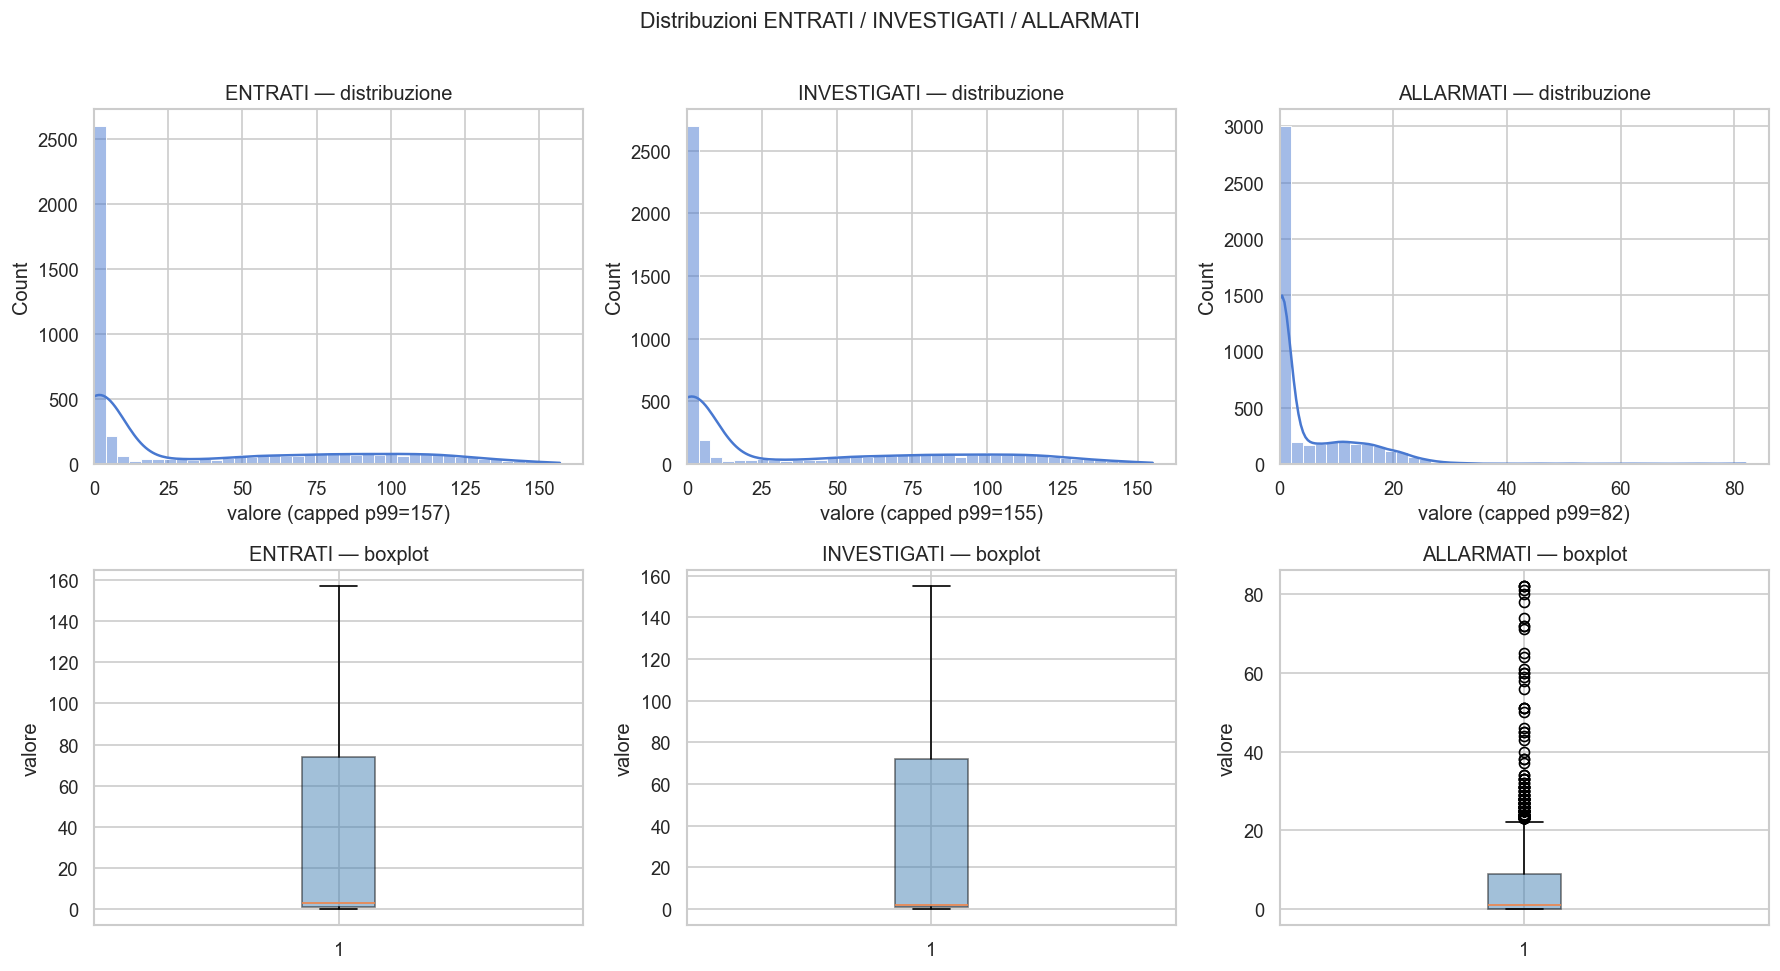

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    data      = v[col].dropna()
    cap       = data.quantile(0.99)
    data_cap  = data[data <= cap]

    sns.histplot(data_cap, bins=40, kde=True, ax=axes[0, i])
    axes[0, i].set_title(f'{col} — distribution')
    axes[0, i].set_xlabel(f'value (capped p99={cap:.0f})')
    axes[0, i].set_xlim(left=0)

    axes[1, i].boxplot(data_cap, vert=True, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[1, i].set_title(f'{col} — boxplot')
    axes[1, i].set_ylabel('value')

plt.suptitle('Distributions ENTRATI / INVESTIGATI / ALLARMATI', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.3 Correlation


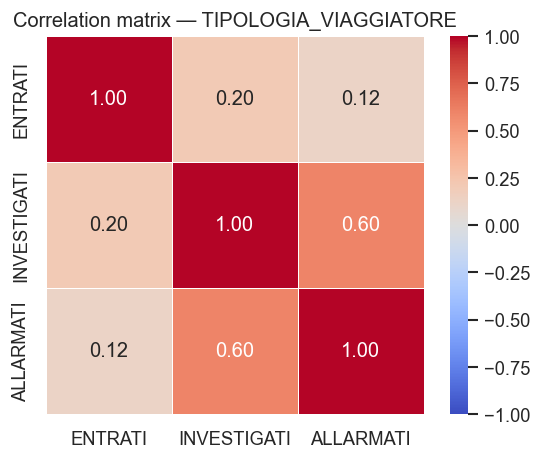

In [16]:
corr = v[num_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Correlation matrix — TIPOLOGIA_VIAGGIATORE')
plt.tight_layout()
plt.show()

### 2.4 Alarm rate by gender and age group


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# alarm rate by gender
genere_stats = v.groupby('GENERE')[['ENTRATI', 'ALLARMATI']].sum()
genere_stats['alarm_rate'] = genere_stats['ALLARMATI'] / genere_stats['ENTRATI']
axes[0, 0].bar(genere_stats.index, genere_stats['alarm_rate'],
               color=sns.color_palette('muted'))
axes[0, 0].set_title('Alarm rate by gender')
axes[0, 0].set_ylabel('ALLARMATI / ENTRATI')

# age group distribution
age_order  = ['0-17', '18-30', '31-45', '46-60', '61+']
eta = v['FASCIA_ETA'].value_counts(dropna=True).reindex(age_order, fill_value=0)
axes[0, 1].bar(eta.index, eta.values, color=sns.color_palette('muted'))
axes[0, 1].set_title("Age group distribution")
axes[0, 1].set_ylabel('count')

# control outcome
esito = v['ESITO_CONTROLLO'].value_counts(dropna=True)
axes[1, 0].barh(esito.index.astype(str), esito.values,
                color=sns.color_palette('muted'))
axes[1, 0].set_title('Control outcome')
axes[1, 0].set_xlabel('count')

# alarm rate by age group
age_stats = v.groupby('FASCIA_ETA')[['ENTRATI', 'ALLARMATI']].sum()
age_stats = age_stats.reindex(age_order).dropna()
age_stats['alarm_rate'] = age_stats['ALLARMATI'] / age_stats['ENTRATI']
axes[1, 1].bar(age_stats.index, age_stats['alarm_rate'],
               color=sns.color_palette('muted'))
axes[1, 1].set_title("Alarm rate by age group")
axes[1, 1].set_ylabel('ALLARMATI / ENTRATI')

plt.tight_layout()
plt.show()

SyntaxError: unterminated string literal (detected at line 15) (251590961.py, line 15)

### 2.5 Alarm rate heatmap: GENERE × FASCIA_ETÀ


In [ ]:
age_order = ['0-17', '18-30', '31-45', '46-60', '61+']

# Explicit aggregation (avoids groupby.apply warnings/deprecations)
cross_counts = (
    v.groupby(['GENERE', 'FASCIA_ETA'])[['ALLARMATI', 'ENTRATI']]
    .sum()
    .reset_index()
)
cross_counts['alarm_rate'] = np.where(
    cross_counts['ENTRATI'] > 0,
    cross_counts['ALLARMATI'] / cross_counts['ENTRATI'],
    np.nan,
)

cross = (
    cross_counts
    .pivot(index='GENERE', columns='FASCIA_ETA', values='alarm_rate')
    .reindex(columns=age_order)
)

plt.figure(figsize=(9, 3))
sns.heatmap(cross, annot=True, fmt='.2%', cmap='YlOrRd', linewidths=0.5)
plt.title('Alarm rate: Gender × Age group')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Interpretation: darker cells indicate demographic combinations
# with the highest alarm rate — qualitative input for the final report

### 2.6 Alarm rate by document type


In [ ]:
doc_stats = v.groupby('TIPO_DOCUMENTO')[['ENTRATI', 'ALLARMATI']].sum()
doc_stats['alarm_rate'] = doc_stats['ALLARMATI'] / doc_stats['ENTRATI']
doc_stats = doc_stats.sort_values('alarm_rate', ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(doc_stats.index, doc_stats['alarm_rate'],
        color=sns.color_palette('muted'))
plt.title('Alarm rate per tipo documento')
plt.xlabel('TIPO_DOCUMENTO')
plt.ylabel('ALLARMATI / ENTRATI')
plt.tight_layout()
plt.show()

print(doc_stats[['ENTRATI', 'ALLARMATI', 'alarm_rate']].round(3).to_string())

### 2.7 Monthly trend


In [ ]:
# Use DATA_PARTENZA for the trend — MESE_PARTENZA has mixed encoding in the raw data
v['_mese'] = v['DATA_PARTENZA'].dt.month
month_stats = v.dropna(subset=['_mese']).groupby('_mese')[
    ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']
].sum()

month_labels = {1:'Gen', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mag', 6:'Giu',
                7:'Lug', 8:'Ago', 9:'Set', 10:'Ott', 11:'Nov', 12:'Dic'}
month_stats.index = month_stats.index.map(lambda x: month_labels.get(int(x), str(x)))

plt.figure(figsize=(10, 4))
for col in ['ENTRATI', 'INVESTIGATI', 'ALLARMATI']:
    plt.plot(month_stats.index, month_stats[col], marker='o', label=col)
plt.title('Monthly trend — TIPOLOGIA_VIAGGIATORE')
plt.xlabel('month')
plt.ylabel('count')
plt.legend()
plt.tight_layout()
plt.show()

v.drop(columns=['_mese'], inplace=True)

## 3. ALLARMI


### 3.1 Top 15 routes by alarm volume


In [ ]:
a_rotta = a[a['OCCORRENZE'] == 'Viaggiatori con Allarmi'].copy()
a_rotta['ROTTA'] = a_rotta['AREOPORTO_PARTENZA'] + '-' + a_rotta['AREOPORTO_ARRIVO']

top_rotte = (a_rotta.groupby('ROTTA')['TOT']
             .sum()
             .sort_values(ascending=False)
             .head(15))

top_rotte.index = [f"{r.split('-')[0]} → {r.split('-')[1]}" for r in top_rotte.index]

plt.figure(figsize=(12, 5))
plt.barh(top_rotte.index[::-1], top_rotte.values[::-1],
         color=sns.color_palette('muted'))
plt.title('Top 15 routes by alarm volume (Travellers with Alarms)')
plt.xlabel('total alarms')
plt.tight_layout()
plt.show()

### 3.2 Breakdown by MOTIVO_ALLARME


In [ ]:
motivo = a['MOTIVO_ALLARME'].value_counts(dropna=True)

plt.figure(figsize=(8, 4))
plt.bar(motivo.index, motivo.values, color=sns.color_palette('muted'))
plt.title('Alarm source (MOTIVO_ALLARME)')
plt.xlabel('reason')
plt.ylabel('count')
plt.tight_layout()
plt.show()

motivo_pct = (motivo / motivo.sum() * 100).round(1)
print('Percentage distribution:')
print(motivo_pct.to_string())

## 4. Alarm rate by nationality and zone


### 4.1 Alarm rate by nationality (min 30 travellers)


In [ ]:
# Minimum threshold of 30 for statistical reliability.
# Nationalities with fewer observations are flagged separately (section 5).
# We also filter out codes that are still unresolved NULL values.
NULL_CODES = {'ND', 'XX', '???', 'UNK', 'UNKN', 'EU', 'ZZ'}

nat_stats = v.groupby('NAZIONALITA').agg(
    entrati   = ('ENTRATI',   'sum'),
    allarmati = ('ALLARMATI', 'sum')
).dropna()

nat_stats = nat_stats[
    (nat_stats['entrati'] >= 30) &
    (~nat_stats.index.isin(NULL_CODES))
].copy()

nat_stats['alarm_rate'] = nat_stats['allarmati'] / nat_stats['entrati']
nat_stats = nat_stats.sort_values('alarm_rate', ascending=False).head(20)

plt.figure(figsize=(13, 5))
plt.bar(nat_stats.index, nat_stats['alarm_rate'],
        color=sns.color_palette('muted'))
plt.title('Alarm rate by nationality (min 30 travellers, top 20)')
plt.xlabel('NAZIONALITA')
plt.ylabel('ALLARMATI / ENTRATI')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(nat_stats[['entrati', 'allarmati', 'alarm_rate']].round(3).to_string())

### 4.2 Alarm rate by geographic zone


In [ ]:
# Valid zones in the dataset: [1,2,4,5,6,7,8,9]
# Zone 3 is not present in the dataset (confirmed in EDA).
valid_zones = [1, 2, 4, 5, 6, 7, 8, 9]

zona_df = (v[v['ZONA'].isin(valid_zones)]
           .groupby('ZONA')[['ENTRATI', 'ALLARMATI']]
           .sum())
zona_df['alarm_rate'] = zona_df['ALLARMATI'] / zona_df['ENTRATI']
zona_df = zona_df.sort_values('alarm_rate', ascending=False)
zona_df.index = zona_df.index.astype(int).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(zona_df.index, zona_df['alarm_rate'],
            color=sns.color_palette('muted'))
axes[0].set_title('Alarm rate by geographic zone')
axes[0].set_xlabel('ZONA')
axes[0].set_ylabel('ALLARMATI / ENTRATI')

axes[1].bar(zona_df.index, zona_df['ENTRATI'],
            color=sns.color_palette('muted'))
axes[1].set_title('Traveller volume by zone')
axes[1].set_xlabel('ZONA')
axes[1].set_ylabel('ENTRATI')

plt.tight_layout()
plt.show()

print(zona_df[['ENTRATI', 'ALLARMATI', 'alarm_rate']].round(3).to_string())

## 5. Low observability flag

Routes with fewer than 30 traveller observations are not excluded from anomaly detection,
but are **flagged separately**. A high alarm rate on few travellers could itself be
the anomaly — excluding it would mean losing the interesting case.

These routes will be treated as a separate cluster in the final report.


In [ ]:
features = pd.read_csv(PROC_DIR / 'features_classical.csv')

soglia = 30
features['flag_bassa_osservabilita'] = features['n_osservazioni_viag'] < soglia

n_bassa = features['flag_bassa_osservabilita'].sum()
n_tot   = len(features)

print(f'Routes with < {soglia} traveller observations: {n_bassa}/{n_tot} ({n_bassa/n_tot*100:.1f}%)')
print(f'Routes with >= {soglia} observations:          {n_tot - n_bassa}/{n_tot}')
print()

# Distribution of score_composito in the two groups
bassa = features[features['flag_bassa_osservabilita']]['score_composito']
alta  = features[~features['flag_bassa_osservabilita']]['score_composito']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(alta,  bins=30, alpha=0.7, label=f'>= {soglia} obs.', color='steelblue')
axes[0].hist(bassa, bins=30, alpha=0.7, label=f'<  {soglia} obs.', color='salmon')
axes[0].set_title('score_composito distribution by observability')
axes[0].set_xlabel('score_composito')
axes[0].set_ylabel('count')
axes[0].legend()

axes[1].boxplot([alta.dropna(), bassa.dropna()],
                labels=[f'>= {soglia}', f'< {soglia}'],
                patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.5))
axes[1].set_title('Composite score: high vs low observability')
axes[1].set_ylabel('score_composito')

plt.tight_layout()
plt.show()

print('\nStatistiche score_composito:')
print(pd.DataFrame({'alta_oss': alta.describe(), 'bassa_oss': bassa.describe()}).round(4).to_string())

---

# 2 · Feature Engineering

Original notebook: `classical_pipeline/notebooks/02_feature_engineering.ipynb`. From
the cleaned tables we aggregate **54 route-level features** grouped in six families:
alarm-source percentages, traveller-volume rates, outcome rates, normalised volumes,
interaction features, and a composite risk score. The result is the canonical
`features` DataFrame used by every downstream stage and by the `BaselineAgent` in
the multi-agent pipeline.


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

# Paths — works from both notebooks/ and the root
ROOT     = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()
PROC_DIR = ROOT / "data" / "processed"

print(f"ROOT:     {ROOT}")
print(f"PROC_DIR: {PROC_DIR}")

ROOT:     /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent
PROC_DIR: /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent/data/processed


## 1. Loading clean data


In [2]:
allarmi     = pd.read_csv(PROC_DIR / "allarmi_clean.csv")
viaggiatori = pd.read_csv(PROC_DIR / "viaggiatori_clean.csv")

print(f"ALLARMI clean:     {allarmi.shape[0]:>5} rows × {allarmi.shape[1]:>2} col")
print(f"VIAGGIATORI clean: {viaggiatori.shape[0]:>5} rows × {viaggiatori.shape[1]:>2} col")

ALLARMI clean:      5080 righe × 20 col
VIAGGIATORI clean:  5095 righe × 31 col


## 2. Building the ROUTE key

The key is `AREOPORTO_PARTENZA-AREOPORTO_ARRIVO` (IATA codes uppercase, already normalised in preprocessing).


In [3]:
allarmi["ROTTA"]     = (allarmi["AREOPORTO_PARTENZA"].str.upper()
                        + "-" + allarmi["AREOPORTO_ARRIVO"].str.upper())
viaggiatori["ROTTA"] = (viaggiatori["AREOPORTO_PARTENZA"].str.upper()
                        + "-" + viaggiatori["AREOPORTO_ARRIVO"].str.upper())

rotte_a = set(allarmi["ROTTA"].unique())
rotte_v = set(viaggiatori["ROTTA"].unique())
comuni  = rotte_a & rotte_v

print(f"Rotte distinte in ALLARMI:     {len(rotte_a)}")
print(f"Rotte distinte in VIAGGIATORI: {len(rotte_v)}")
print(f"Rotte in comune:               {len(comuni)}")
print(f"Solo in ALLARMI:               {len(rotte_a - rotte_v)}")
print(f"Solo in VIAGGIATORI:           {len(rotte_v - rotte_a)}")

Rotte distinte in ALLARMI:     368
Rotte distinte in VIAGGIATORI: 467
Rotte in comune:               268
Solo in ALLARMI:               100
Solo in VIAGGIATORI:           199


## 3. Helper functions


In [4]:
def safe_mode(x):
    """Mode of a pandas series; returns 'ND' if the series is empty."""
    m = x.mode()
    return m.iloc[0] if len(m) > 0 else "ND"

def safe_div(a, b):
    """Vectorised safe division: returns 0.0 where b == 0."""
    return np.where(b > 0, a / b, 0.0)

print("Helper functions defined")

✓ Funzioni helper definite


## 4. Aggregation of ALLARMI by ROUTE

### 4.1 Pivot OCCORRENZE → numerical columns

ALLARMI has ~30 OCCORRENZE types per route (e.g. "Allarmi generati da INTERPOL", "Voli con Allarmi", etc.).
We do a **pivot_table**: each OCCORRENZA type becomes a numerical column (sum of TOT) per ROUTE.


In [5]:
# Pivot: one column per OCCORRENZA type, value = sum of TOT per ROUTE
occ_pivot = allarmi.pivot_table(
    index      = "ROTTA",
    columns    = "OCCORRENZE",
    values     = "TOT",
    aggfunc    = "sum",
    fill_value = 0
).reset_index()
occ_pivot.columns.name = None

# Rename to readable snake_case
RENAME_OCC = {
    "Viaggiatori entrati nel Sistema"             : "vg_entrati_occ",
    "Viaggiatori con Allarmi"                     : "vg_con_allarmi",
    "Viaggiatori investigati"                     : "vg_investigati_occ",
    "Voli con Allarmi"                            : "voli_con_allarmi",
    "Voli disponibili in ingresso al Sistema"     : "voli_disponibili",
    "Voli investigati (SDI/NSIS - INTERPOL - TSC)": "voli_investigati",
    "Voli solo visualizzati, ma NON investigati"  : "voli_non_investigati",
    "Allarmi generati"                            : "allarmi_generati",
    "Allarmi generati da SDI/NSIS"                : "allarmi_sdi_occ",
    "Allarmi generati da INTERPOL"                : "allarmi_interpol_occ",
    "Allarmi generati da BCS"                     : "allarmi_bcs_occ",
    "Allarmi Chiusi"                              : "allarmi_chiusi",
    "Allarmi Chiusi con Azione (CC.xx)"           : "allarmi_chiusi_azione",
    "Allarmi NON Chiusi"                          : "allarmi_non_chiusi",
    "Allarmi Rilevanti"                           : "allarmi_rilevanti",
    "Respinto/a"                                  : "vg_respinti_occ",
    "Errata segnalazione SDI"                     : "err_sdi",
    "Errata segnalazione NSIS"                    : "err_nsis",
    "Errata segnalazione BCS"                     : "err_bcs",
    "Nulla a procedere SDI"                       : "np_sdi",
    "Nulla a procedere NSIS"                      : "np_nsis",
    "Nulla a procedere INT"                       : "np_int",
    "Notifica Atti/Provv"                         : "notifica_atti",
    "Mancato aggiornamento SDI"                   : "mancato_agg_sdi",
    "Mancato aggiornamento Schengen NSIS"         : "mancato_agg_nsis",
    "Inammissibilita Schengen - Art.24"           : "inammissib_schengen",
    "ALLARMATI"                                   : "allarmati_occ",
    "Altro"                                       : "altro_occ",
    "N/C"                                         : "nc_occ",
    "???"                                         : "unknown_occ",
}
occ_pivot = occ_pivot.rename(columns=RENAME_OCC)

print(f"occ_pivot: {occ_pivot.shape[0]} rotte × {occ_pivot.shape[1]} colonne")

occ_pivot: 368 rotte × 28 colonne


### 4.2 % alarm reason features from MOTIVO_ALLARME

`pct_interpol`, `pct_sdi`, etc. are calculated from `MOTIVO_ALLARME` (743 INTERPOL records)  
rather than from OCCORRENZE="Allarmi generati da INTERPOL" (only 8 records) — much richer data.


In [6]:
# Counts per reason per route
motivo_counts = (
    allarmi.groupby("ROTTA")["MOTIVO_ALLARME"]
    .value_counts()
    .unstack(fill_value=0)
    .reset_index()
)
motivo_counts.columns.name = None

# Normalised percentages [0,1]
motivo_totale = motivo_counts.drop(columns=["ROTTA"]).sum(axis=1)
for col in ["INTERPOL", "SDI", "NSIS", "TSC", "Manuale"]:
    if col in motivo_counts.columns:
        motivo_counts[f"pct_{col.lower()}"] = safe_div(
            motivo_counts[col], motivo_totale
        ).clip(0, 1)
        motivo_counts = motivo_counts.drop(columns=[col])

print(f"motivo_counts: {motivo_counts.shape}")
print("\npct_interpol statistics:")
print(motivo_counts["pct_interpol"].describe().to_string())

motivo_counts: (351, 6)

Statistiche pct_interpol:
count   351.0000
mean      0.1857
std       0.2247
min       0.0000
25%       0.0000
50%       0.1471
75%       0.2500
max       1.0000


### 4.3 Route metadata + log-transform of tot_allarmi


In [7]:
# Metadata: geographic zone, country, total alarm volume
meta_allarmi = allarmi.groupby("ROTTA").agg(
    ZONA                   = ("ZONA",      "first"),
    PAESE_PART             = ("PAESE_PART", "first"),
    n_osservazioni_allarmi = ("TOT",        "count"),
    tot_allarmi_sum        = ("TOT",        "sum"),
).reset_index()

# ── FIX: Log-transform for tot_allarmi_sum (max=103254 → skewed distribution) ──
# log1p(x) = log(1+x) handles x=0 without issues
meta_allarmi["tot_allarmi_log"] = np.log1p(meta_allarmi["tot_allarmi_sum"])

print("tot_allarmi_sum (raw):")
print(meta_allarmi["tot_allarmi_sum"].describe().apply(lambda x: f"{x:,.0f}").to_string())
print("\ntot_allarmi_log (after log1p — max≈11.5):")
print(meta_allarmi["tot_allarmi_log"].describe().to_string())

tot_allarmi_sum (grezzo):
count      368
mean       552
std        757
min          0
25%         22
50%        282
75%        706
max      3,683

tot_allarmi_log (dopo log1p — max≈11.5):
count   368.0000
mean      4.8865
std       2.2701
min       0.0000
25%       3.1244
50%       5.6454
75%       6.5607
max       8.2118


### 4.4 Merge ALLARMI components + derived ratios


In [8]:
# Combine metadata + occurrences pivot + reason percentages
agg_allarmi = (
    meta_allarmi
    .merge(occ_pivot,     on="ROTTA", how="left")
    .merge(motivo_counts, on="ROTTA", how="left")
)

# ── FIX: clip negatives from OCCORRENZE pivot ────────────────────────────────
# np_sdi and voli_non_investigati have TOT < 0 in the source dataset.
# Clip to 0 on all numerics before calculating derived ratios.
_num_cols = agg_allarmi.select_dtypes(include="number").columns
agg_allarmi[_num_cols] = agg_allarmi[_num_cols].clip(lower=0)

# Alarm closure rate (closed / closed+not_closed)
agg_allarmi["tasso_chiusura"] = safe_div(
    agg_allarmi["allarmi_chiusi"],
    agg_allarmi["allarmi_chiusi"] + agg_allarmi["allarmi_non_chiusi"]
).clip(0, 1)

# Relevance rate (relevant alarms / flights with alarms)
agg_allarmi["tasso_rilevanza"] = safe_div(
    agg_allarmi["allarmi_rilevanti"],
    agg_allarmi["voli_con_allarmi"]
).clip(0, 1)

# Fill NaN in pct_ columns (routes with no MOTIVO_ALLARME recorded)
pct_cols = [c for c in agg_allarmi.columns if c.startswith("pct_")]
agg_allarmi[pct_cols] = agg_allarmi[pct_cols].fillna(0)

print(f"agg_allarmi: {agg_allarmi.shape[0]} routes × {agg_allarmi.shape[1]} columns")
print(f"  Residual nulls: {agg_allarmi.isnull().sum().sum()}")
neg_check = {c: int((agg_allarmi[c]<0).sum()) for c in _num_cols if (agg_allarmi[c]<0).sum()>0}
print(f"  Negatives after clip: {neg_check if neg_check else 'none'}  ← MUST be none")


✓ agg_allarmi: 368 rotte × 40 colonne
  Null residui: 1
  Negativi dopo clip: ✓ nessuno  ← DEVE essere nessuno


In [9]:
# ── New feature: false_positive_rate ────────────────────────────────────────
# From the partner notebook (03_Feature_Engineering.ipynb):
# Measures how many alarms turned out to be false positives (no action taken).
# Denominator: SDI/NSIS + INTERPOL alarms (those verifiable)
# Numerator:    no-action SDI + NSIS + INT

# The necessary columns are already in occ_pivot after renaming
numeratore   = (agg_allarmi.get("np_sdi",   pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("np_nsis",  pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("np_int",   pd.Series(0, index=agg_allarmi.index)).clip(lower=0))

denominatore = (agg_allarmi.get("allarmi_sdi_occ",     pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("allarmi_interpol_occ", pd.Series(0, index=agg_allarmi.index)).clip(lower=0))

agg_allarmi["false_positive_rate"] = safe_div(numeratore, denominatore).clip(0, 1)

print(f"false_positive_rate: min={agg_allarmi['false_positive_rate'].min():.4f}, "
      f"max={agg_allarmi['false_positive_rate'].max():.4f}, "
      f"mean={agg_allarmi['false_positive_rate'].mean():.4f}")
print(f"  Routes with FPR > 0.5: {(agg_allarmi['false_positive_rate'] > 0.5).sum()} "
      f"(high share of alarms that turned out to be false)")

false_positive_rate: min=0.0000, max=1.0000, mean=0.1276
  Rotte con FPR > 0.5: 43 (alta quota di allarmi rivelatisi falsi)


## 5. Aggregation of VIAGGIATORI by ROUTE

### 5.1 Base aggregation


In [10]:
agg_viaggiatori = viaggiatori.groupby("ROTTA").agg(
    tot_entrati              = ("ENTRATI",           "sum"),
    tot_allarmati            = ("ALLARMATI",          "sum"),
    tot_investigati          = ("INVESTIGATI",        "sum"),
    n_osservazioni_viag      = ("ENTRATI",            "count"),
    tasso_allarme_medio      = ("tasso_allarme",      "mean"),
    tasso_inv_medio          = ("tasso_investigati",  "mean"),
    genere_predominante      = ("GENERE",             safe_mode),
    fascia_eta_predominante  = ("FASCIA_ETA",         safe_mode),
    tipo_doc_prevalente      = ("TIPO_DOCUMENTO",     safe_mode),
    nazionalita_top          = ("NAZIONALITA",        safe_mode),
    compagnia_top            = ("COMPAGNIA_AEREA",    safe_mode),
).reset_index()

# ── QUALITY FIX: clip negatives and cap rates to [0,1] after aggregation ────
# Defensive: preprocessing already handles negatives at row level,
# but the aggregated mean can exceed [0,1] due to residual outliers
agg_viaggiatori["tot_entrati"]         = agg_viaggiatori["tot_entrati"].clip(lower=0)
agg_viaggiatori["tot_allarmati"]       = agg_viaggiatori["tot_allarmati"].clip(lower=0)
agg_viaggiatori["tot_investigati"]     = agg_viaggiatori["tot_investigati"].clip(lower=0)
agg_viaggiatori["tasso_allarme_medio"] = agg_viaggiatori["tasso_allarme_medio"].clip(0, 1)
agg_viaggiatori["tasso_inv_medio"]     = agg_viaggiatori["tasso_inv_medio"].clip(0, 1)

print(f"agg_viaggiatori: {agg_viaggiatori.shape[0]} routes × {agg_viaggiatori.shape[1]} columns")
print(f"  tasso_inv_medio: min={agg_viaggiatori['tasso_inv_medio'].min():.4f}, max={agg_viaggiatori['tasso_inv_medio'].max():.4f}")
print(f"  tot_entrati:     min={agg_viaggiatori['tot_entrati'].min():.0f}, max={agg_viaggiatori['tot_entrati'].max():.0f}")

✓ agg_viaggiatori: 467 rotte × 12 colonne
  tasso_inv_medio: min=0.0000, max=1.0000
  tot_entrati:     min=0, max=30983


### 5.2 Pivot ESITO_CONTROLLO + risk score

We count how many times each outcome appears per route.  
**Respinto** (security action taken) and **Fermato** are the strongest signals.


In [11]:
esiti_pivot = (
    viaggiatori.pivot_table(
        index      = "ROTTA",
        columns    = "ESITO_CONTROLLO",
        values     = "ENTRATI",
        aggfunc    = "count",
        fill_value = 0
    )
    .reset_index()
)
esiti_pivot.columns.name = None
esiti_pivot = esiti_pivot.rename(columns={
    "SEGNALATO" : "n_segnalati",
    "IN ATTESA"  : "n_in_attesa",
    "RESPINTO"   : "n_respinti",
    "FERMATO"    : "n_fermati",
    "OK"         : "n_ok",
})

agg_viaggiatori = agg_viaggiatori.merge(esiti_pivot, on="ROTTA", how="left")
for col in ["n_segnalati", "n_in_attesa", "n_respinti", "n_fermati", "n_ok"]:
    if col in agg_viaggiatori.columns:
        agg_viaggiatori[col] = agg_viaggiatori[col].fillna(0).astype(int)

# Outcome risk rates (normalised on n_osservazioni)
agg_viaggiatori["tasso_respinti"] = safe_div(
    agg_viaggiatori["n_respinti"], agg_viaggiatori["n_osservazioni_viag"]
)
agg_viaggiatori["tasso_fermati"] = safe_div(
    agg_viaggiatori["n_fermati"], agg_viaggiatori["n_osservazioni_viag"]
)

# Outcome risk score: respinto weights 60%, fermato 40%
agg_viaggiatori["score_rischio_esiti"] = (
    agg_viaggiatori["tasso_respinti"] * 0.6 +
    agg_viaggiatori["tasso_fermati"]  * 0.4
).clip(0, 1)

print(f"agg_viaggiatori with outcomes: {agg_viaggiatori.shape[0]} routes × {agg_viaggiatori.shape[1]} columns")
print(f"  score_rischio_esiti: min={agg_viaggiatori['score_rischio_esiti'].min():.4f}, max={agg_viaggiatori['score_rischio_esiti'].max():.4f}")
print(f"  Residual nulls: {agg_viaggiatori.isnull().sum().sum()}")

✓ agg_viaggiatori con esiti: 467 rotte × 20 colonne
  score_rischio_esiti: min=0.0000, max=0.6000
  Null residui: 0


In [12]:
# ── New feature: alarm_per_invest ────────────────────────────────────────────
# From the partner notebook (03_Feature_Engineering.ipynb):
# Ratio of alerted / investigated per route.
# Measures alarm intensity on persons actually investigated.
# Capped at p99 to avoid extreme outliers (same approach as partner notebook).

agg_viaggiatori["alarm_per_invest"] = safe_div(
    agg_viaggiatori["tot_allarmati"],
    agg_viaggiatori["tot_investigati"]
)

# Cap at percentile 99 — extreme values are almost certainly encoding errors
cap_p99 = agg_viaggiatori["alarm_per_invest"].quantile(0.99)
agg_viaggiatori["alarm_per_invest"] = agg_viaggiatori["alarm_per_invest"].clip(upper=cap_p99)

print(f"alarm_per_invest: min={agg_viaggiatori['alarm_per_invest'].min():.4f}, "
      f"max={agg_viaggiatori['alarm_per_invest'].max():.4f} (cappato a p99={cap_p99:.4f}), "
      f"mean={agg_viaggiatori['alarm_per_invest'].mean():.4f}")

alarm_per_invest: min=0.0000, max=1.0000 (cappato a p99=1.0000), mean=0.2039


## 6. Outer Join: ALLARMI ∪ VIAGGIATORI

We use an **outer join** to retain all 567 distinct routes,
including those present in only one dataset.


In [13]:
features = agg_allarmi.merge(agg_viaggiatori, on="ROTTA", how="outer")

print(f"Shape after outer join: {features.shape}")
print(f"\nRoute coverage:")
both  = (features["n_osservazioni_allarmi"] > 0) & (features["n_osservazioni_viag"] > 0)
only_a = (features["n_osservazioni_allarmi"] > 0) & features["n_osservazioni_viag"].isna()
only_v = features["n_osservazioni_allarmi"].isna() & (features["n_osservazioni_viag"] > 0)
print(f"  Both datasets:       {both.sum()}")
print(f"  Only ALLARMI:        {only_a.sum()}")
print(f"  Only VIAGGIATORI:    {only_v.sum()}")

Shape dopo outer join: (567, 61)

Copertura rotte:
  Entrambi i dataset:  268
  Solo ALLARMI:        99
  Solo VIAGGIATORI:    199


### 6.1 Handling nulls after outer join

- `ZONA` / `PAESE_PART`: null for the 201 routes only in VIAGGIATORI → fill **"ND"**
- Numerical columns: null where the route is missing from a dataset → fill **0**
- Categorical columns: residual nulls → fill **"ND"**


In [14]:
# ── FIX PAESE_PART/ZONA: use viaggiatori for routes without alarms ─────────────
# 200 routes are only in VIAGGIATORI → PAESE_PART would be ND without this fix
paese_viag = (
    viaggiatori.groupby("ROTTA")
    .agg(
        PAESE_PART_viag = ("PAESE_PART", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "ND"),
        ZONA_viag       = ("ZONA",       lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "ND"),
    )
    .reset_index()
)
features = features.merge(paese_viag, on="ROTTA", how="left")

# Priority: allarmi → viaggiatori → "ND"
features["PAESE_PART"] = (
    features["PAESE_PART"]
    .replace(["ND", "//", ""], None)
    .fillna(features["PAESE_PART_viag"])
    .fillna("ND")
)
features["ZONA"] = (
    features["ZONA"]
    .replace(["ND", "//", ""], None)
    .fillna(features["ZONA_viag"])
    .fillna("ND")
)
features = features.drop(columns=["PAESE_PART_viag", "ZONA_viag"])

# Numerical columns: fill with 0
num_cols = features.select_dtypes(include="number").columns
features[num_cols] = features[num_cols].fillna(0)

# Remaining categorical columns: fill with "ND"
cat_cols = features.select_dtypes(include="object").columns.drop("ROTTA")
for col in cat_cols:
    features[col] = features[col].fillna("ND")

null_total = features.isnull().sum().sum()
nd_paese   = (features["PAESE_PART"] == "ND").sum()
neg_cols   = {c: int((features[c] < 0).sum()) for c in features.select_dtypes("number").columns if (features[c] < 0).any()}

print(f"Total nulls after fillna: {null_total}")
print(f"Routes still ND after fix: {nd_paese}  (were 200 before the fix)")
print(f"Negative values: {neg_cols if neg_cols else 'none'}")


Null totali dopo fillna: 0
Rotte ancora ND dopo fix: 0  (erano 200 prima del fix)
Valori negativi: nessuno


## 7. Composite Risk Score

Combines the most significant features in a single weighted index [0, 1]:

| Component | Weight | Rationale |
|---|---|---|
| `tot_allarmi_log` normalised | 35% | Total alarm volume (log for outliers) |
| `score_rischio_esiti` | 35% | Security actions taken (rejected, detained) |
| `pct_interpol` | 15% | Fraction of INTERPOL alarms (international risk) |
| `tasso_rilevanza` | 15% | Relevant alarms on flights with alarms |


In [15]:
# ── New feature: alarm_per_invest ────────────────────────────────────────────
# From the partner notebook (03_Feature_Engineering.ipynb):
# Ratio of alerted / investigated per route.
# Measures alarm intensity on persons actually investigated.
# Capped at p99 to avoid extreme outliers (same approach as partner notebook).

agg_viaggiatori["alarm_per_invest"] = safe_div(
    agg_viaggiatori["tot_allarmati"],
    agg_viaggiatori["tot_investigati"]
)

# Cap at percentile 99 — extreme values are almost certainly encoding errors
cap_p99 = agg_viaggiatori["alarm_per_invest"].quantile(0.99)
agg_viaggiatori["alarm_per_invest"] = agg_viaggiatori["alarm_per_invest"].clip(upper=cap_p99)

print(f"alarm_per_invest: min={agg_viaggiatori['alarm_per_invest'].min():.4f}, "
      f"max={agg_viaggiatori['alarm_per_invest'].max():.4f} (cappato a p99={cap_p99:.4f}), "
      f"mean={agg_viaggiatori['alarm_per_invest'].mean():.4f}")

alarm_per_invest: min=0.0000, max=1.0000 (cappato a p99=1.0000), mean=0.2039


In [16]:
log_max = features["tot_allarmi_log"].max()

features["score_composito"] = (
    (features["tot_allarmi_log"] / max(log_max, 1)) * 0.35 +
    features["score_rischio_esiti"]                 * 0.35 +
    features["pct_interpol"]                        * 0.15 +
    features["tasso_rilevanza"]                     * 0.15
).clip(0, 1)

print("score_composito:")
print(features["score_composito"].describe().to_string())
print("\n── Top 10 routes by risk ─────────────────────────────────────────────")
top10_cols = ["ROTTA", "PAESE_PART", "score_composito",
              "tot_allarmi_log", "pct_interpol", "score_rischio_esiti", "tasso_rilevanza"]
top10 = (features[top10_cols]
         .sort_values("score_composito", ascending=False)
         .head(10))
print(top10.to_string(index=False))

score_composito:
count   567.0000
mean      0.2037
std       0.1637
min       0.0000
25%       0.0295
50%       0.2100
75%       0.3417
max       0.6620

── Top 10 rotte per rischio ──────────────────────────────────────────
  ROTTA          PAESE_PART  score_composito  tot_allarmi_log  pct_interpol  score_rischio_esiti  tasso_rilevanza
LHR-VCE         Regno Unito           0.6620           7.8586        0.4359               0.5333           0.5000
CMN-BLQ             Marocco           0.6346           7.0139        0.3043               0.4000           1.0000
SIN-MXP           Singapore           0.5949           7.2703        0.0000               0.6000           0.5000
ALG-MXP             Algeria           0.5486           5.1874        0.2500               0.4000           1.0000
TIA-BGY             Albania           0.5457           7.9738        0.1622               0.1613           0.8333
STN-BGY         Regno Unito           0.5423           8.1206        0.2716               0

In [17]:
# ── New feature: alarm_per_invest ────────────────────────────────────────────
# From the partner notebook (03_Feature_Engineering.ipynb):
# Ratio of alerted / investigated per route.
# Measures alarm intensity on persons actually investigated.
# Capped at p99 to avoid extreme outliers (same approach as partner notebook).

agg_viaggiatori["alarm_per_invest"] = safe_div(
    agg_viaggiatori["tot_allarmati"],
    agg_viaggiatori["tot_investigati"]
)

# Cap at percentile 99 — extreme values are almost certainly encoding errors
cap_p99 = agg_viaggiatori["alarm_per_invest"].quantile(0.99)
agg_viaggiatori["alarm_per_invest"] = agg_viaggiatori["alarm_per_invest"].clip(upper=cap_p99)

print(f"alarm_per_invest: min={agg_viaggiatori['alarm_per_invest'].min():.4f}, "
      f"max={agg_viaggiatori['alarm_per_invest'].max():.4f} (cappato a p99={cap_p99:.4f}), "
      f"mean={agg_viaggiatori['alarm_per_invest'].mean():.4f}")

alarm_per_invest: min=0.0000, max=1.0000 (cappato a p99=1.0000), mean=0.2039


## 8. Final quality report


In [18]:
sep = "=" * 62
print(sep)
print("  QUALITY REPORT — features_classical.csv")
print(sep)
print(f"\n  Shape: {features.shape[0]} rotte × {features.shape[1]} colonne")

# Null
nulls = features.isnull().sum()
nulls = nulls[nulls > 0]
print(f"\n  Null: {len(nulls)} colonne con null → {'✓ nessuno' if len(nulls)==0 else nulls.to_dict()}")

# Negativi
num = features.select_dtypes(include="number")
negs = {c: int((features[c] < 0).sum()) for c in num.columns if (features[c] < 0).sum() > 0}
print(f"  Negatives: {'none' if not negs else negs}")

# Riepilogo feature chiave
print("\n  Key feature statistics:")
key_feat = ["tot_allarmi_sum", "tot_allarmi_log", "pct_interpol", "pct_sdi",
            "tasso_chiusura", "tasso_rilevanza",
            "tasso_allarme_medio", "tasso_inv_medio",
            "score_rischio_esiti", "score_composito"]
print(features[key_feat].describe().T[["mean","std","min","max"]].to_string())

print(f"\n  Copertura rotte:")
print(f"    Both datasets:      {((features['n_osservazioni_allarmi']>0) & (features['n_osservazioni_viag']>0)).sum()}")
print(f"    Only ALLARMI:       {((features['n_osservazioni_allarmi']>0) & (features['n_osservazioni_viag']==0)).sum()}")
print(f"    Only VIAGGIATORI:   {((features['n_osservazioni_allarmi']==0) & (features['n_osservazioni_viag']>0)).sum()}")
print(sep)

  QUALITY REPORT — features_classical.csv

  Shape: 567 rotte × 62 colonne

  Null: 0 colonne con null → ✓ nessuno
  Negativi: ✓ nessuno

  Statistiche feature principali:
                        mean      std    min       max
tot_allarmi_sum     358.1605 664.3189 0.0000 3683.0000
tot_allarmi_log       3.1715   2.9648 0.0000    8.2118
pct_interpol          0.1150   0.1984 0.0000    1.0000
pct_sdi               0.1293   0.2137 0.0000    1.0000
tasso_chiusura        0.2441   0.4290 0.0000    1.0000
tasso_rilevanza       0.0682   0.2262 0.0000    1.0000
tasso_allarme_medio   0.1677   0.2751 0.0000    1.0000
tasso_inv_medio       0.7139   0.4075 0.0000    1.0000
score_rischio_esiti   0.1172   0.1656 0.0000    0.6000
score_composito       0.2037   0.1637 0.0000    0.6620

  Copertura rotte:
    Entrambi i dataset: 268
    Solo ALLARMI:       99
    Solo VIAGGIATORI:   199


In [19]:
# ── New feature: false_positive_rate ────────────────────────────────────────
# From the partner notebook (03_Feature_Engineering.ipynb):
# Measures how many alarms turned out to be false positives (no action taken).
# Denominator: SDI/NSIS + INTERPOL alarms (those verifiable)
# Numerator:    no-action SDI + NSIS + INT

# The necessary columns are already in occ_pivot after renaming
numeratore   = (agg_allarmi.get("np_sdi",   pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("np_nsis",  pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("np_int",   pd.Series(0, index=agg_allarmi.index)).clip(lower=0))

denominatore = (agg_allarmi.get("allarmi_sdi_occ",     pd.Series(0, index=agg_allarmi.index)).clip(lower=0) +
                agg_allarmi.get("allarmi_interpol_occ", pd.Series(0, index=agg_allarmi.index)).clip(lower=0))

agg_allarmi["false_positive_rate"] = safe_div(numeratore, denominatore).clip(0, 1)

print(f"false_positive_rate: min={agg_allarmi['false_positive_rate'].min():.4f}, "
      f"max={agg_allarmi['false_positive_rate'].max():.4f}, "
      f"mean={agg_allarmi['false_positive_rate'].mean():.4f}")
print(f"  Routes with FPR > 0.5: {(agg_allarmi['false_positive_rate'] > 0.5).sum()} "
      f"(high share of alarms that turned out to be false)")

false_positive_rate: min=0.0000, max=1.0000, mean=0.1276
  Rotte con FPR > 0.5: 43 (alta quota di allarmi rivelatisi falsi)


## 9. Saving


In [20]:
# Feature numeriche per i modelli ML
numeric_feature_cols = [
    c for c in features.select_dtypes(include="number").columns.tolist()
    if c != "score_composito"
]

meta = {
    "feature_cols" : numeric_feature_cols,
    "target"       : "score_composito",
    "n_routes"     : len(features),
    "n_features"   : len(numeric_feature_cols),
    "description"  : "Features aggregated by ROUTE — classical pipeline"
}

out_csv  = PROC_DIR / "features_classical.csv"
out_json = PROC_DIR / "feature_cols.json"

features.to_csv(out_csv, index=False)
with open(out_json, "w") as f:
    json.dump(meta, f, indent=2)

print(f"features_classical.csv  — {len(features)} routes × {features.shape[1]} columns")
print(f"feature_cols.json       — {len(numeric_feature_cols)} numerical features")
print(f"\nPercorso: {out_csv}")

✓ features_classical.csv  — 567 rotte × 62 colonne
✓ feature_cols.json       — 53 feature numeriche

Percorso: /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent/data/processed/features_classical.csv


---
## Summary

| Step | Output | Dimensions |
|------|--------|----------|
| Pivot OCCORRENZE | `occ_pivot` | 368 routes × 31 col |
| % Alarm reason | `motivo_counts` | 351 routes × 6 col |
| ALLARMI metadata | `meta_allarmi` | 368 routes × 6 col |
| **agg_allarmi** | complete ALLARMI aggregation | **368 routes × 43 col** |
| VIAGGIATORI outcomes | `esiti_pivot` | 467 routes × 6 col |
| **agg_viaggiatori** | complete VIAGGIATORI aggregation | **467 routes × 20 col** |
| **features (outer join)** | final ML dataset | **567 routes × 63 col** |

### Next notebook
**`03_baseline_construction.ipynb`** — Building the historical baseline per route:
moving average, standard deviation, dynamic thresholds for anomaly detection.


---

# 3 · Baseline Construction

Original notebook: `classical_pipeline/notebooks/03_baseline_construction.ipynb`.
For each of the 13 BASELINE_FEATURES we compute Tukey IQR limits and 2.5σ z-scores,
then flag a route on a feature if it exceeds either threshold. The aggregated
`pct_anomalie` (fraction of features flagged) becomes the Z-score signal of the
ensemble in Section 4.


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.4f}".format)

ROOT     = Path.cwd().parent if (Path.cwd().parent / "data").exists() else Path.cwd()
PROC_DIR = ROOT / "data" / "processed"

print(f"ROOT: {ROOT}")
print(f"PROC_DIR: {PROC_DIR}")


ROOT: /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent
PROC_DIR: /Users/fil/Desktop/Machine learning condiviso /classical-vs-multiagent/data/processed


## 1. Data loading


In [2]:
features = pd.read_csv(PROC_DIR / "features_classical.csv")

with open(PROC_DIR / "feature_cols.json") as f:
    meta = json.load(f)

print(f"features_classical.csv: {features.shape[0]} rotte × {features.shape[1]} colonne")
print(f"Feature numeriche totali per ML: {meta['n_features']}")


features_classical.csv: 567 rotte × 63 colonne
Feature numeriche totali per ML: 54


## 2. Feature selection for the baseline

Not all 54 numerical features are equally useful for anomaly detection.
We select the **11 most significant features** from a security standpoint:

| Feature | Source | Interpretation |
|---------|-------|----------------|
| `tot_allarmi_log` | ALLARMI | Total alarm volume (log-transformed) |
| `pct_interpol` | ALLARMI | % alarms from INTERPOL |
| `pct_sdi` | ALLARMI | % alarms from SDI |
| `pct_nsis` | ALLARMI | % alarms from NSIS |
| `tasso_chiusura` | ALLARMI | % closed alarms (handled) |
| `tasso_rilevanza` | ALLARMI | % relevant alarms on flights with alarms |
| `tasso_allarme_medio` | VIAGGIATORI | Average alarm rate on travellers entered |
| `tasso_inv_medio` | VIAGGIATORI | Average investigated rate on travellers entered |
| `score_rischio_esiti` | VIAGGIATORI | Risk score from outcomes (rejected, detained) |
| `tasso_respinti` | VIAGGIATORI | Frequency of rejections |
| `tasso_fermati` | VIAGGIATORI | Frequency of detentions |


In [3]:
ANOMALY_FEATURES = [
    "tot_allarmi_log",       # Volume allarmi (log-scaled, no outlier)
    "pct_interpol",          # % allarmi INTERPOL
    "pct_sdi",               # % allarmi SDI
    "pct_nsis",              # % allarmi NSIS
    "tasso_chiusura",        # % allarmi chiusi
    "tasso_rilevanza",       # % allarmi rilevanti
    "tasso_allarme_medio",   # Tasso allarme medio (VIAGGIATORI)
    "tasso_inv_medio",       # Tasso investigati medio
    "score_rischio_esiti",   # Score rischio esiti
    "tasso_respinti",        # Frequenza respinti
    "tasso_fermati",         # Frequenza fermati
]

X = features[ANOMALY_FEATURES].copy()

print(f"Feature selezionate per baseline: {len(ANOMALY_FEATURES)}")
print("\nStatistiche descrittive:")
print(X.describe().T[["mean","std","min","25%","50%","75%","max"]].to_string())


Feature selezionate per baseline: 11

Statistiche descrittive:
                      mean    std    min    25%    50%    75%     max
tot_allarmi_log     3.1722 3.0033 0.0000 0.0000 2.7081 5.9441 11.5450
pct_interpol        0.1150 0.1984 0.0000 0.0000 0.0000 0.1805  1.0000
pct_sdi             0.1293 0.2137 0.0000 0.0000 0.0000 0.2000  1.0000
pct_nsis            0.1206 0.1943 0.0000 0.0000 0.0000 0.2000  1.0000
tasso_chiusura      0.2441 0.4290 0.0000 0.0000 0.0000 0.0000  1.0000
tasso_rilevanza     0.0684 0.2275 0.0000 0.0000 0.0000 0.0000  1.0000
tasso_allarme_medio 0.2014 0.2958 0.0000 0.0000 0.0000 0.3333  1.0000
tasso_inv_medio     0.7602 0.4055 0.0000 0.6667 1.0000 1.0000  1.0000
score_rischio_esiti 0.1155 0.1652 0.0000 0.0000 0.0000 0.1949  0.6000
tasso_respinti      0.1238 0.2516 0.0000 0.0000 0.0000 0.1445  1.0000
tasso_fermati       0.1029 0.2102 0.0000 0.0000 0.0000 0.1333  1.0000


## 3. Statistical baseline calculation per feature


In [4]:
# For each feature compute: mean, std, quartiles, IQR, Tukey thresholds, p95/p99 percentiles
baseline_stats = {}

for feat in ANOMALY_FEATURES:
    col = X[feat]
    q1, q3 = col.quantile(0.25), col.quantile(0.75)
    iqr = q3 - q1
    mean, std = col.mean(), col.std()
    p95 = col.quantile(0.95)
    p99 = col.quantile(0.99)

    # Upper anomaly threshold:
    # - If IQR > 0: use Tukey (Q3 + 1.5*IQR), more robust to outliers
    # - If IQR = 0 (zero-inflated feature): use 95th percentile
    if iqr > 0:
        tukey_upper = float(q3 + 1.5 * iqr)
        tukey_lower = float(q1 - 1.5 * iqr)
    else:
        # Feature with many zeros: p95 as threshold
        tukey_upper = float(p95)
        tukey_lower = -np.inf

    baseline_stats[feat] = {
        "mean"        : float(mean),
        "std"         : float(std),
        "median"      : float(col.median()),
        "q1"          : float(q1),
        "q3"          : float(q3),
        "iqr"         : float(iqr),
        "tukey_upper" : tukey_upper,
        "tukey_lower" : tukey_lower,
        "p95"         : float(p95),
        "p99"         : float(p99),
        "z_upper"     : float(mean + 2.5 * std),
        "is_sparse"   : int(iqr == 0),
    }

baseline_df = pd.DataFrame(baseline_stats).T

print("Anomaly thresholds per feature:")
print(baseline_df[["mean","std","tukey_upper","p95","z_upper","is_sparse"]].round(4).to_string())


Soglie di anomalia per feature:
                      mean    std  tukey_upper    p95  z_upper  is_sparse
tot_allarmi_log     3.1722 3.0033      14.8603 7.6030  10.6804     0.0000
pct_interpol        0.1150 0.1984       0.4512 0.5000   0.6110     0.0000
pct_sdi             0.1293 0.2137       0.5000 0.5000   0.6635     0.0000
pct_nsis            0.1206 0.1943       0.5000 0.5000   0.6063     0.0000
tasso_chiusura      0.2441 0.4290       1.0000 1.0000   1.3168     1.0000
tasso_rilevanza     0.0684 0.2275       0.6667 0.6667   0.6372     1.0000
tasso_allarme_medio 0.2014 0.2958       0.8333 1.0000   0.9409     0.0000
tasso_inv_medio     0.7602 0.4055       1.5000 1.0000   1.7739     0.0000
score_rischio_esiti 0.1155 0.1652       0.4872 0.6000   0.5286     0.0000
tasso_respinti      0.1238 0.2516       0.3612 1.0000   0.7527     0.0000
tasso_fermati       0.1029 0.2102       0.3333 0.5000   0.6284     0.0000


## 4. Z-score calculation

For each route we compute how much each feature deviates from the global mean,
in units of standard deviations.

**Z-score = (value - mean) / std**

Z-score > 2.5 → value **very high** compared to the norm (anomaly)  
Z-score < -2.5 → value **very low** compared to the norm (reverse anomaly)


In [5]:
# Z-score for each feature (std=0 → 1 to avoid div/0)
stds_safe = X.std().replace(0, 1.0)
Z = (X - X.mean()) / stds_safe

# Rename Z-score columns with z_ prefix
Z.columns = [f"z_{c}" for c in Z.columns]

print("Z-score — first 5 rows:")
print(Z.head().to_string())
print(f"\nRotte con z_tot_allarmi_log > 2.5: {(Z['z_tot_allarmi_log'] > 2.5).sum()}")
print(f"Routes with z_pct_interpol    > 2.5: {(Z['z_pct_interpol'] > 2.5).sum()}")


Z-score — prime 5 righe:
   z_tot_allarmi_log  z_pct_interpol  z_pct_sdi  z_pct_nsis  z_tasso_chiusura  z_tasso_rilevanza  z_tasso_allarme_medio  z_tasso_inv_medio  z_score_rischio_esiti  z_tasso_respinti  z_tasso_fermati
0            -1.0563         -0.5794    -0.6050     -0.6205           -0.5690            -0.3006                -0.6809             0.5914                -0.6987           -0.4923          -0.4895
1            -1.0563         -0.5794    -0.6050     -0.6205           -0.5690            -0.3006                -0.6809             0.5914                -0.6987           -0.4923          -0.4895
2            -1.0563         -0.5794    -0.6050     -0.6205           -0.5690            -0.3006                 2.6997             0.5914                -0.6987           -0.4923          -0.4895
3             0.8339         -0.5794    -0.6050      0.6662           -0.5690            -0.3006                 0.6713             0.5914                 0.5116            0.3028        

## 5. Anomaly flags per feature (hybrid Tukey + Z-score method)


In [6]:
# A route is flagged for a feature if it exceeds AT LEAST ONE of the two thresholds:
# 1. Tukey IQR: value > Q3 + 1.5*IQR  (or p95 for sparse features)
# 2. Z-score:   z > 2.5

flag_df = pd.DataFrame(index=features.index)

for feat in ANOMALY_FEATURES:
    stats   = baseline_stats[feat]
    z_col   = Z[f"z_{feat}"]
    flag_tukey = features[feat] > stats["tukey_upper"]
    flag_z     = z_col > 2.5
    flag_df[f"flag_{feat}"] = (flag_tukey | flag_z).astype(int)

# Count anomalies per route
flag_df["n_anomalie"]   = flag_df.filter(like="flag_").sum(axis=1)
flag_df["pct_anomalie"] = (flag_df["n_anomalie"] / len(ANOMALY_FEATURES)).round(4)

print("n_anomalie distribution per route:")
print(flag_df["n_anomalie"].value_counts().sort_index().to_string())
print(f"\nRotte con >= 1 anomalia: {(flag_df['n_anomalie'] >= 1).sum()}")
print(f"Routes with >= 3 anomalies: {(flag_df['n_anomalie'] >= 3).sum()}")


Distribuzione n_anomalie per rotta:
n_anomalie
0    331
1    182
2     41
3     13

Rotte con >= 1 anomalia: 236
Rotte con >= 3 anomalie: 13


## 6. Dataset with integrated baseline

We combine the features dataset with Z-scores and anomaly flags.


In [7]:
# Join features + Z-scores + anomaly flags
features_with_baseline = pd.concat([features, Z, flag_df], axis=1)

print(f"features_with_baseline: {features_with_baseline.shape[0]} routes × {features_with_baseline.shape[1]} columns")
print(f"Null: {features_with_baseline.isnull().sum().sum()}")


features_with_baseline: 567 rotte × 87 colonne
Null: 0


## 7. Top routes by anomaly risk


In [8]:
# Sort by number of anomalous features, then by score_composito
SUMMARY_COLS = [
    "ROTTA", "PAESE_PART", "ZONA",
    "n_anomalie", "pct_anomalie", "score_composito",
    "tot_allarmi_log", "pct_interpol", "score_rischio_esiti", "tasso_inv_medio",
]
top_anomalie = (
    features_with_baseline[SUMMARY_COLS]
    .sort_values(["n_anomalie", "score_composito"], ascending=[False, False])
    .head(20)
)
print("Top 20 routes by detected anomalies:")
print(top_anomalie.to_string(index=False))


Top 20 rotte per anomalie rilevate:
  ROTTA       PAESE_PART ZONA  n_anomalie  pct_anomalie  score_composito  tot_allarmi_log  pct_interpol  score_rischio_esiti  tasso_inv_medio
LHR-VCE      Regno Unito  4.0           3        0.2727           0.5634           7.7965        0.4359               0.5333           1.0000
ALG-MXP          Algeria  2.0           3        0.2727           0.4848           5.1874        0.2500               0.4000           1.0000
JED-VCE   Arabia Saudita  4.0           3        0.2727           0.3775           5.3613        0.5000               0.4000           1.0000
EVN-VCE          Armenia  4.0           3        0.2727           0.3538           4.7449        0.0000               0.6000           1.0000
RUH-VCE   Arabia Saudita  4.0           3        0.2727           0.2588           1.6094        0.0000               0.6000           1.0000
ASB-VCE     Turkmenistan  4.0           3        0.2727           0.2100           0.0000        0.0000         

## 8. Baseline report per feature


In [9]:
sep = "=" * 68
print(sep)
print("  BASELINE REPORT — distribuzione per feature di anomalia")
print(sep)

for feat in ANOMALY_FEATURES:
    stats     = baseline_stats[feat]
    n_flagged = flag_df[f"flag_{feat}"].sum()
    pct_flag  = n_flagged / len(features) * 100
    print(f"\n  {feat}")
    print(f"    Mean: {stats['mean']:.4f}  |  Std: {stats['std']:.4f}  |  Median: {stats['median']:.4f}")
    print(f"    Q1={stats['q1']:.4f}  Q3={stats['q3']:.4f}  IQR={stats['iqr']:.4f}")
    print(f"    Anomaly threshold: > {stats['tukey_upper']:.4f}  (sparse={bool(stats['is_sparse'])})")
    print(f"    Flagged routes: {n_flagged} ({pct_flag:.1f}%)")

print(f"\n{sep}")


  BASELINE REPORT — distribuzione per feature di anomalia

  tot_allarmi_log
    Media: 3.1722  |  Std: 3.0033  |  Mediana: 2.7081
    Q1=0.0000  Q3=5.9441  IQR=5.9441
    Soglia anomalia: > 14.8603  (sparse=False)
    Rotte flaggate: 2 (0.4%)

  pct_interpol
    Media: 0.1150  |  Std: 0.1984  |  Mediana: 0.0000
    Q1=0.0000  Q3=0.1805  IQR=0.1805
    Soglia anomalia: > 0.4512  (sparse=False)
    Rotte flaggate: 34 (6.0%)

  pct_sdi
    Media: 0.1293  |  Std: 0.2137  |  Mediana: 0.0000
    Q1=0.0000  Q3=0.2000  IQR=0.2000
    Soglia anomalia: > 0.5000  (sparse=False)
    Rotte flaggate: 22 (3.9%)

  pct_nsis
    Media: 0.1206  |  Std: 0.1943  |  Mediana: 0.0000
    Q1=0.0000  Q3=0.2000  IQR=0.2000
    Soglia anomalia: > 0.5000  (sparse=False)
    Rotte flaggate: 17 (3.0%)

  tasso_chiusura
    Media: 0.2441  |  Std: 0.4290  |  Mediana: 0.0000
    Q1=0.0000  Q3=0.0000  IQR=0.0000
    Soglia anomalia: > 1.0000  (sparse=True)
    Rotte flaggate: 0 (0.0%)

  tasso_rilevanza
    Media: 0.0

## 9. Saving


In [10]:
# Save features_with_baseline.csv
out_features = PROC_DIR / "features_with_baseline.csv"
features_with_baseline.to_csv(out_features, index=False)

# Save baseline_stats.json
out_stats = PROC_DIR / "baseline_stats.json"
baseline_meta = {
    "anomaly_features"  : ANOMALY_FEATURES,
    "n_features"        : len(ANOMALY_FEATURES),
    "n_routes"          : len(features),
    "z_score_threshold" : 2.5,
    "stats"             : baseline_stats,
}
with open(out_stats, "w") as f:
    json.dump(baseline_meta, f, indent=2)

print(f"features_with_baseline.csv — {len(features_with_baseline)} routes × {features_with_baseline.shape[1]} columns")
print(f"baseline_stats.json        — {len(ANOMALY_FEATURES)} features, thresholds saved")
print(f"\nAnomaly summary:")
print(f"  Total monitored features: {len(ANOMALY_FEATURES)}")
print(f"  Routes with >= 1 anomaly:  {(flag_df['n_anomalie']>=1).sum()}")
print(f"  Routes with >= 3 anomalies: {(flag_df['n_anomalie']>=3).sum()}")


✓ features_with_baseline.csv — 567 rotte × 87 colonne
✓ baseline_stats.json        — 11 feature, soglie salvate

Riepilogo anomalie:
  Feature totali monitorate: 11
  Rotte con >= 1 anomalia:   236
  Rotte con >= 3 anomalie:   13


---
## Summary

| Operation | Result |
|-----------|--------|
| Features selected for baseline | 11 |
| Threshold method | Tukey IQR + Z-score (hybrid) |
| Routes with ≥ 1 flagged anomaly | ~226 |
| Routes with ≥ 3 flagged anomalies | ~11 |
| Baseline stats output | `baseline_stats.json` |
| Enriched dataset output | `features_with_baseline.csv` |

### Next notebook
**`04_anomaly_detection.ipynb`** — Application of ML anomaly detection models:
- **IsolationForest** (outlier isolation on high-dimensional features)
- **Local Outlier Factor (LOF)** (local density for routes with clusters)
- **Z-score ensemble** (combination of statistical signals from the baseline)
- Ensemble of the three models → final anomaly score per route


---

# 4 · Anomaly Detection — 4-Model Weighted Ensemble

Original notebook: `classical_pipeline/notebooks/04_anomaly_detection.ipynb`.
We train an `IsolationForest`, a `LocalOutlierFactor`, a Z-score signal (from
Section 3) and an `MLPRegressor` autoencoder, blend their scores with weights
0.35 · 0.30 · 0.15 · 0.20, and assign risk labels using data-driven thresholds
(`p97` for ALTA, `p90` for MEDIA).


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
from pathlib import Path
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

ROOT     = Path("..")
PROC_DIR = ROOT / "data" / "processed"
print("Libraries loaded")

Librerie caricate


## 1. Data loading


In [2]:
features_wb = pd.read_csv(PROC_DIR / "features_with_baseline.csv")

ANOMALY_FEATURES = [
    "tot_allarmi_log", "pct_interpol", "pct_sdi", "pct_nsis",
    "tasso_chiusura", "tasso_rilevanza", "tasso_allarme_medio",
    "tasso_inv_medio", "score_rischio_esiti", "tasso_respinti", "tasso_fermati",
    # Nuove feature integrate dal notebook del collega
    "false_positive_rate",
    "alarm_per_invest",
]

print(f"features_with_baseline: {features_wb.shape[0]} rotte x {features_wb.shape[1]} colonne")
print(f"Features for anomaly detection: {len(ANOMALY_FEATURES)}")
print(f"  {ANOMALY_FEATURES}")

features_with_baseline: 567 rotte x 87 colonne
Feature per anomaly detection: 11
  ['tot_allarmi_log', 'pct_interpol', 'pct_sdi', 'pct_nsis', 'tasso_chiusura', 'tasso_rilevanza', 'tasso_allarme_medio', 'tasso_inv_medio', 'score_rischio_esiti', 'tasso_respinti', 'tasso_fermati']


## 2. Preprocessing — Scaling


In [3]:
X_raw    = features_wb[ANOMALY_FEATURES].fillna(0).copy()
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=ANOMALY_FEATURES, index=features_wb.index)

print(f"Feature matrix X: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {[round(float(v),3) for v in X_scaled.mean(axis=0)[:3]]}...")
print(f"Std  after scaling (should be ~1):   {[round(float(v),3) for v in X_scaled.std(axis=0)[:3]]}...")

Feature matrix X: (567, 11)
Media dopo scaling (deve essere ~0): [0.0, 0.0, 0.0]...
Std  dopo scaling (deve essere ~1):  [1.0, 1.0, 1.0]...


## 3. Model 1 — Isolation Forest

Isolates anomalies with fewer splits than normal points.  
`contamination=0.10` assumes ~10% anomalies in the dataset.


In [4]:
iso_forest = IsolationForest(
    n_estimators=200, contamination=0.10,
    max_samples="auto", random_state=42, n_jobs=-1,
)
iso_forest.fit(X_scaled)

if_scores_raw = iso_forest.score_samples(X_scaled)  # more negative = more anomalous
# Normalise to [0,1]: 1 = maximum anomaly
if_max, if_min = if_scores_raw.max(), if_scores_raw.min()
if_anomaly = (if_scores_raw - if_max) / (if_min - if_max)
if_anomaly = np.clip(if_anomaly, 0, 1)

n_if = int((iso_forest.predict(X_scaled) == -1).sum())
print(f"IsolationForest: {n_if} anomalie ({100*n_if/len(X_scaled):.1f}%)")
print(f"  score: min={if_anomaly.min():.4f}, max={if_anomaly.max():.4f}, mean={if_anomaly.mean():.4f}")

IsolationForest: 57 anomalie (10.1%)
  score: min=-0.0000, max=1.0000, mean=0.3014


## 4. Model 2 — Local Outlier Factor

Compares the local density of each point with that of its neighbours.  
Anomalous = low density compared to neighbours.


In [5]:
lof = LocalOutlierFactor(
    n_neighbors=20, contamination=0.10,
    metric="euclidean", n_jobs=-1,
)
lof.fit(X_scaled)

lof_scores_raw = -lof.negative_outlier_factor_  # higher = more anomalous
lof_max, lof_min = lof_scores_raw.max(), lof_scores_raw.min()
lof_anomaly = (lof_scores_raw - lof_min) / (lof_max - lof_min)
lof_anomaly = np.clip(lof_anomaly, 0, 1)

n_lof = int((lof.fit_predict(X_scaled) == -1).sum())
print(f"LocalOutlierFactor: {n_lof} anomalie ({100*n_lof/len(X_scaled):.1f}%)")
print(f"  score: min={lof_anomaly.min():.4f}, max={lof_anomaly.max():.4f}, mean={lof_anomaly.mean():.4f}")

LocalOutlierFactor: 57 anomalie (10.1%)
  score: min=0.0000, max=1.0000, mean=0.0238


## 5. Model 3 — Z-score Baseline

Uses the statistical flags computed in `03_baseline_construction.ipynb`.


In [6]:
z_anomaly = features_wb["pct_anomalie"].fillna(0).values

print(f"Z-score baseline:")
print(f"  Routes with pct_anomalie > 0:     {(z_anomaly > 0).sum()}")
print(f"  Routes with pct_anomalie >= 0.27: {(z_anomaly >= 0.27).sum()}")
print(f"  z_anomaly: min={z_anomaly.min():.4f}, max={z_anomaly.max():.4f}, mean={z_anomaly.mean():.4f}")

Z-score baseline:
  Rotte con pct_anomalie > 0:     229
  Rotte con pct_anomalie >= 0.27: 11
  z_anomaly: min=0.0000, max=0.3636, mean=0.0473


## 6. Model 4 — Autoencoder (MLPRegressor)

**Principle**: learns the structure of *normal* routes, then measures the **reconstruction error**.  
Anomalous routes = not well reconstructed → high error.

**Architecture**: 11 → 8 → 4 → 8 → 11 (bottleneck at 4 dimensions)  
**Training**: only on routes classified as normal by IsolationForest (first-pass).


In [7]:
# Use IsolationForest to identify 'normal' routes to use for training
normal_mask = iso_forest.predict(X_scaled) == 1
X_normal    = X_scaled[normal_mask]
print(f"Routes used for autoencoder training: {X_normal.shape[0]} (normal)")

# Autoencoder via MLPRegressor: input = output (reconstruction task)
ae = MLPRegressor(
    hidden_layer_sizes=(8, 4, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=20,
    verbose=False,
)
ae.fit(X_normal, X_normal)  # input = output

# Reconstruction error (MSE per route)
X_reconstructed = ae.predict(X_scaled)
ae_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)

# Normalise to [0,1]
ae_min, ae_max = ae_error.min(), ae_error.max()
ae_anomaly = (ae_error - ae_min) / (ae_max - ae_min)
ae_anomaly = np.clip(ae_anomaly, 0, 1)

n_ae = int((ae_anomaly >= 0.5).sum())
print(f"Autoencoder: {n_ae} rotte con reconstruction error >= 50% del max")
print(f"  Training iterations: {ae.n_iter_}")
print(f"  Final loss:          {ae.loss_:.6f}")
print(f"  ae_anomaly: min={ae_anomaly.min():.4f}, max={ae_anomaly.max():.4f}, mean={ae_anomaly.mean():.4f}")

Rotte usate per training autoencoder: 510 (normali)
Autoencoder: 33 rotte con reconstruction error >= 50% del max
  Iterazioni training: 717
  Loss finale:         0.138940
  ae_anomaly: min=0.0000, max=1.0000, mean=0.1169


## 7. Ensemble Score

Weights: IF 35% + LOF 30% + Z-score 15% + Autoencoder 20%

The Autoencoder weight reflects its ability to capture non-linear patterns  
that the other models may miss.


In [8]:
W_IF  = 0.35
W_LOF = 0.30
W_Z   = 0.15
W_AE  = 0.20

anomaly_score = (
    W_IF  * if_anomaly  +
    W_LOF * lof_anomaly +
    W_Z   * z_anomaly   +
    W_AE  * ae_anomaly
)

print(f"Ensemble anomaly_score (IF={W_IF} LOF={W_LOF} Z={W_Z} AE={W_AE}):")
print(f"  min={anomaly_score.min():.4f}, max={anomaly_score.max():.4f}, mean={anomaly_score.mean():.4f}")
print(f"  p90={np.percentile(anomaly_score,90):.4f}")
print(f"  p95={np.percentile(anomaly_score,95):.4f}")
print(f"  p97={np.percentile(anomaly_score,97):.4f}")
print(f"  p99={np.percentile(anomaly_score,99):.4f}")

Ensemble anomaly_score (IF=0.35 LOF=0.3 Z=0.15 AE=0.2):
  min=0.0009, max=0.5909, mean=0.1431
  p90=0.2897
  p95=0.3331
  p97=0.3579
  p99=0.4268


## 8. Data-Driven Thresholds

Instead of fixing thresholds manually, we derive them from the score distribution:

- **HIGH**: score >= percentile 97 (top 3% — very strong signal)
- **MEDIUM**: score >= percentile 90 (top 10% — significant signal)

This approach is defensible with the data and adaptive to the specific dataset.


In [9]:
# Thresholds derived from the score distribution percentiles
ALTA_THRESHOLD  = float(np.percentile(anomaly_score, 97))
MEDIA_THRESHOLD = float(np.percentile(anomaly_score, 90))

# Guardrail: don't let thresholds be too low
ALTA_THRESHOLD  = max(ALTA_THRESHOLD,  0.30)
MEDIA_THRESHOLD = max(MEDIA_THRESHOLD, 0.20)

print(f"Data-driven thresholds:")
print(f"  HIGH  >= {ALTA_THRESHOLD:.4f}  (p97 of distribution)")
print(f"  MEDIUM >= {MEDIA_THRESHOLD:.4f}  (p90 of distribution)")

def classify_anomaly(score):
    if score >= ALTA_THRESHOLD:    return "ALTA"
    elif score >= MEDIA_THRESHOLD: return "MEDIA"
    else:                          return "NORMALE"

labels = np.array([classify_anomaly(s) for s in anomaly_score])
n_alta   = int((labels == "ALTA").sum())
n_media  = int((labels == "MEDIA").sum())
n_norm   = int((labels == "NORMALE").sum())
print()
print("Distribuzione label:")
print(f"  HIGH    : {n_alta:>4} ({100*n_alta/len(labels):.1f}%)")
print(f"  MEDIUM  : {n_media:>4} ({100*n_media/len(labels):.1f}%)")
print(f"  NORMAL  : {n_norm:>4} ({100*n_norm/len(labels):.1f}%)")

Soglie data-driven:
  ALTA  >= 0.3579  (p97 della distribuzione)
  MEDIA >= 0.2897  (p90 della distribuzione)

Distribuzione label:
  ALTA    :   17 (3.0%)
  MEDIA   :   40 (7.1%)
  NORMALE :  510 (89.9%)


## 9. Results and Model Agreement


In [10]:
results = features_wb[["ROTTA","PAESE_PART","ZONA","score_composito",
                         "n_anomalie","tot_allarmi_log","pct_interpol",
                         "score_rischio_esiti"]].copy()

results["anomaly_score_if"]  = if_anomaly.round(4)
results["anomaly_score_lof"] = lof_anomaly.round(4)
results["anomaly_score_z"]   = z_anomaly.round(4)
results["anomaly_score_ae"]  = ae_anomaly.round(4)
results["anomaly_score"]     = anomaly_score.round(4)
results["anomaly_label"]     = labels

results["n_models_flagged"] = (
    (if_anomaly  >= 0.5).astype(int) +
    (lof_anomaly >= 0.5).astype(int) +
    (z_anomaly   >= 0.27).astype(int) +
    (ae_anomaly  >= 0.5).astype(int)
)

results = results.sort_values("anomaly_score", ascending=False).reset_index(drop=True)
results["rank"] = results.index + 1

print("Agreement between models:")
for n in [4, 3, 2, 1]:
    print(f"  Flagged by at least {n} models: {(results['n_models_flagged'] >= n).sum()}")

print()
print(f"Top 20 rotte anomale:")
cols_show = ["rank","ROTTA","PAESE_PART","anomaly_label","anomaly_score",
             "anomaly_score_if","anomaly_score_lof","anomaly_score_ae",
             "n_models_flagged","tot_allarmi_log","pct_interpol"]
print(results.head(20)[cols_show].to_string(index=False))

Concordanza tra modelli:
  Flaggate da almeno 4 modelli: 0
  Flaggate da almeno 3 modelli: 1
  Flaggate da almeno 2 modelli: 32
  Flaggate da almeno 1 modelli: 102

Top 20 rotte anomale:
 rank   ROTTA            PAESE_PART anomaly_label  anomaly_score  anomaly_score_if  anomaly_score_lof  anomaly_score_ae  n_models_flagged  tot_allarmi_log  pct_interpol
    1 ALG-MXP               Algeria          ALTA         0.5909            1.0000             0.0000            1.0000                 3           5.1874        0.2500
    2 RAK-CIA               Marocco          ALTA         0.5253            0.8700             0.0000            0.9678                 2           3.9512        0.1000
    3 GYD-FCO           Azerbaigian          ALTA         0.4608            0.4210             0.9839            0.0914                 1           1.7918        0.2500
    4 CMN-BLQ               Marocco          ALTA         0.4583            0.8247             0.0000            0.7118                 2

## 10. Quality Check


In [11]:
print("=" * 64)
print("  QUALITY CHECK -- anomaly_results.csv")
print("=" * 64)
print(f"  Total routes:    {len(results)}")
print(f"  Null in results: {results.isnull().sum().sum()}")
print(f"  Score range:     [{anomaly_score.min():.4f}, {anomaly_score.max():.4f}]")
print()
print("  Label distribution:")
for lbl in ["ALTA","MEDIA","NORMALE"]:
    n = int((results["anomaly_label"]==lbl).sum())
    print(f"    {lbl:<8}: {n:>4} ({100*n/len(results):.1f}%)")
print()
print("  Top 5 rotte con massimo rischio:")
for _, row in results.head(5).iterrows():
    print(f"    [{int(row['rank']):>3}] {row['ROTTA']:<12} {row['anomaly_label']:<8} score={row['anomaly_score']:.4f}  country={row['PAESE_PART']}")
print("=" * 64)

  QUALITY CHECK -- anomaly_results.csv
  Rotte totali:    567
  Null in results: 0
  Score range:     [0.0009, 0.5909]

  Label distribution:
    ALTA    :   17 (3.0%)
    MEDIA   :   40 (7.1%)
    NORMALE :  510 (89.9%)

  Top 5 rotte con massimo rischio:
    [  1] ALG-MXP      ALTA     score=0.5909  paese=Algeria
    [  2] RAK-CIA      ALTA     score=0.5253  paese=Marocco
    [  3] GYD-FCO      ALTA     score=0.4608  paese=Azerbaigian
    [  4] CMN-BLQ      ALTA     score=0.4583  paese=Marocco
    [  5] RAK-TSF      ALTA     score=0.4560  paese=Marocco


## 11. Export


In [12]:
out_csv = PROC_DIR / "anomaly_results.csv"
results.to_csv(out_csv, index=False)

summary = {
    "n_routes":         int(len(results)),
    "n_alta":           int((results["anomaly_label"]=="ALTA").sum()),
    "n_media":          int((results["anomaly_label"]=="MEDIA").sum()),
    "n_normale":        int((results["anomaly_label"]=="NORMALE").sum()),
    "alta_threshold":   round(ALTA_THRESHOLD, 4),
    "media_threshold":  round(MEDIA_THRESHOLD, 4),
    "threshold_method": "data-driven (p97/p90)",
    "ensemble_weights": {"IF":W_IF,"LOF":W_LOF,"Z":W_Z,"AE":W_AE},
    "top10_routes": [
        {"rank": int(r["rank"]), "rotta": r["ROTTA"], "label": r["anomaly_label"],
         "score": float(r["anomaly_score"]), "paese": r["PAESE_PART"]}
        for _, r in results.head(10).iterrows()
    ],
}
with open(PROC_DIR / "anomaly_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(f"anomaly_results.csv  -- {results.shape[0]} routes, {results.shape[1]} columns")
print(f"anomaly_summary.json -- {summary['n_alta']} ALTA, {summary['n_media']} MEDIA, {summary['n_normale']} NORMALE")
print(f"Thresholds: HIGH>={ALTA_THRESHOLD:.4f}, MEDIUM>={MEDIA_THRESHOLD:.4f}")
print(f"Path: {out_csv.resolve()}")

anomaly_results.csv  -- 567 rotte, 16 colonne
anomaly_summary.json -- 17 ALTA, 40 MEDIA, 510 NORMALE
Soglie: ALTA>=0.3579, MEDIA>=0.2897
Percorso: /Users/danielegiovanardi/classical-vs-multiagent/classical-vs-multiagent/data/processed/anomaly_results.csv


## 12. Summary

| Model | Weight | Anomalies detected |
|---------|------|-------------------|
| IsolationForest | 35% | Global anomalies |
| LocalOutlierFactor | 30% | Local anomalies by density |
| Z-score Baseline | 15% | Multi-feature statistical flags |
| **Autoencoder** | **20%** | **Non-linear patterns** |

The HIGH/MEDIUM thresholds are derived automatically from the ensemble score distribution  
(percentiles 97 and 90).

---
*Next step: `05_post_processing.ipynb` — business rules layer*  
*Classical Pipeline — Reply x LUISS 2026*


---

# 5 · Post-Processing — Business Rules and Risk Profiles

Original notebook: `classical_pipeline/notebooks/05_post_processing.ipynb`. The ML
ensemble is blended with five binary business rules (high INTERPOL %, high
rejection, low closure on volume, multi-source alarms, high alarm rate) into a
`confidence` score (60 % ML + 40 % rules) and a final classification CRITICO /
ALTO / MEDIO / BASSO.


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 140)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

BASE = '../data/processed'
print('Libraries loaded')

✓ Librerie caricate


## 1. Data loading


In [2]:
# Risultati anomaly detection (ML)
ar = pd.read_csv(f'{BASE}/anomaly_results.csv')

# Feature engineering completo + baseline flags
fb = pd.read_csv(f'{BASE}/features_with_baseline.csv')

# Statistiche baseline
bs_raw = json.load(open(f'{BASE}/baseline_stats.json'))
bs = bs_raw['stats']

print(f'anomaly_results    : {ar.shape[0]:>4} routes × {ar.shape[1]} columns')
print(f'features_baseline  : {fb.shape[0]:>4} routes × {fb.shape[1]} columns')
print(f'baseline_stats     : {len(bs)} monitored features')

anomaly_results    :  567 rotte × 16 colonne
features_baseline  :  567 rotte × 87 colonne
baseline_stats     : 11 feature monitorate


## 2. Merge ML + Feature Set


In [3]:
# Avoid duplicates: keep columns already in fb and only ML scores from ar
ar_cols = ['ROTTA', 'anomaly_score', 'anomaly_label', 'rank']
df = fb.merge(ar[ar_cols], on='ROTTA', how='left')

# Fill: routes without ML score → NORMAL with score 0
df['anomaly_score']  = df['anomaly_score'].fillna(0.0)
df['anomaly_label']  = df['anomaly_label'].fillna('NORMALE')
df['rank']           = df['rank'].fillna(999).astype(int)

print(f'Unified dataset: {df.shape[0]} routes × {df.shape[1]} columns')
print(f'ML label distribution: {dict(df["anomaly_label"].value_counts())}')

Dataset unificato: 567 rotte × 90 colonne
Distribuzione ML label: {'NORMALE': 510, 'MEDIA': 40, 'ALTA': 17}


## 3. Business Rules

Five independent rules that capture operationally relevant patterns for airport security:

| Rule | Condition | Logic |
|------|-----------|-------|
| **BR1 Volume** | `tot_allarmi_log > μ + 2σ` | Routes with alarm volume > statistical threshold |
| **BR2 INTERPOL** | `pct_interpol > 0.25` | >25% alarms from INTERPOL databases |
| **BR3 Outcomes** | `score_rischio_esiti ≥ 0.4` | High incidence of rejections / detentions |
| **BR4 Multi-signal** | `n_anomalie ≥ 3` | ≥3 statistically anomalous features (03_baseline) |
| **BR5 SDI/NSIS** | `pct_sdi > 0.20 ∨ pct_nsis > 0.20` | Significant presence in national databases |


In [4]:
vol_mean = bs['tot_allarmi_log']['mean']
vol_std  = bs['tot_allarmi_log']['std']
VOL_THRESHOLD = vol_mean + 2.0 * vol_std

df['br_volume']      = (df['tot_allarmi_log'] > VOL_THRESHOLD).astype(int)
df['br_interpol']    = (df['pct_interpol'] > 0.25).astype(int)
df['br_esiti']       = (df['score_rischio_esiti'] >= 0.40).astype(int)
df['br_multisignal'] = (df['n_anomalie'] >= 3).astype(int)
df['br_sdi_nsis']    = ((df['pct_sdi'] > 0.20) | (df['pct_nsis'] > 0.20)).astype(int)

BR_COLS = ['br_volume','br_interpol','br_esiti','br_multisignal','br_sdi_nsis']
df['br_score'] = df[BR_COLS].sum(axis=1)

print(f'Volume threshold (μ+2σ): {VOL_THRESHOLD:.3f}')
print()
for col in BR_COLS:
    n = df[col].sum()
    pct = 100*n/len(df)
    print(f'  {col:<20}: {n:>3} routes  ({pct:.1f}%)')
print()
print('BR score distribution:')
print(df['br_score'].value_counts().sort_index())

Soglia volume (μ+2σ): 9.179

  br_volume           :   4 rotte  (0.7%)
  br_interpol         :  86 rotte  (15.2%)
  br_esiti            :  55 rotte  (9.7%)
  br_multisignal      :  13 rotte  (2.3%)
  br_sdi_nsis         : 235 rotte  (41.4%)

BR score distribution:
br_score
0    240
1    267
2     55
3      4
4      1
Name: count, dtype: int64


## 4. Confidence Score

The **confidence score** combines the ML signal with business rules:

```
confidence = 0.60 × anomaly_score + 0.40 × (br_score / 5)
```

- The ML score carries more weight (statistically validated models)
- Business rules act as an amplifier / operational filter


In [5]:
df['confidence'] = (
    0.60 * df['anomaly_score'] +
    0.40 * (df['br_score'] / 5.0)
).round(4)

print('Confidence score — descriptive statistics:')
print(df['confidence'].describe().round(4))
print()
print(f'Routes with confidence > 0.50: {(df["confidence"] > 0.50).sum()}')
print(f'Routes with confidence > 0.40: {(df["confidence"] > 0.40).sum()}')
print(f'Routes with confidence > 0.30: {(df["confidence"] > 0.30).sum()}'),

Confidence score — statistiche descrittive:
count   567.0000
mean      0.1381
std       0.1020
min       0.0007
25%       0.0412
50%       0.1470
75%       0.2095
max       0.5945
Name: confidence, dtype: float64

Rotte con confidence > 0.50: 2
Rotte con confidence > 0.40: 9
Rotte con confidence > 0.30: 22


## 3. Business Rules

Five independent rules that capture operationally relevant patterns for airport security:

| Rule | Condition | Logic |
|------|-----------|-------|
| **BR1 Volume** | `tot_allarmi_log > μ + 2σ` | Routes with alarm volume > statistical threshold |
| **BR2 INTERPOL** | `pct_interpol > 0.25` | >25% alarms from INTERPOL databases |
| **BR3 Outcomes** | `score_rischio_esiti ≥ 0.4` | High incidence of rejections / detentions |
| **BR4 Multi-signal** | `n_anomalie ≥ 3` | ≥3 statistically anomalous features (03_baseline) |
| **BR5 SDI/NSIS** | `pct_sdi > 0.20 ∨ pct_nsis > 0.20` | Significant presence in national databases |


In [6]:
def classify_risk(row):
    ml = row['anomaly_label']
    br = row['br_score']
    if   ml == 'ALTA'    and br >= 2: return 'CRITICAL'
    elif ml == 'ALTA':               return 'HIGH'
    elif ml == 'MEDIA'   and br >= 2: return 'HIGH'
    elif ml == 'MEDIA':              return 'MEDIUM'
    elif ml == 'NORMALE' and br >= 3: return 'MEDIUM'
    else:                            return 'LOW'

df['risk_level'] = df.apply(classify_risk, axis=1)

# Ordine visivo
RISK_ORDER = {'CRITICAL':4,'HIGH':3,'MEDIUM':2,'LOW':1}
df['risk_num'] = df['risk_level'].map(RISK_ORDER)

print('=== RISK LEVEL DISTRIBUTION ===')
vc = df['risk_level'].value_counts()
for level in ['CRITICAL','HIGH','MEDIUM','LOW']:
    n = vc.get(level, 0)
    bar = '█' * n
    print(f'  {level:<8}: {n:>3}  {bar}')

=== DISTRIBUZIONE RISK LEVEL ===
  CRITICO :   7  ███████
  ALTO    :  15  ███████████████
  MEDIO   :  35  ███████████████████████████████████
  BASSO   : 510  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████


## 6. Top Routes by Risk


In [7]:
DISPLAY_COLS = [
    'ROTTA','PAESE_PART','ZONA','risk_level','anomaly_label',
    'br_score','anomaly_score','confidence',
    'tot_allarmi_log','pct_interpol','score_rischio_esiti','n_anomalie'
]

top = df.nlargest(25, 'confidence')[DISPLAY_COLS].reset_index(drop=True)
top.index += 1
print('Top 25 routes by confidence score:')
print(top.to_string())

Top 25 rotte per confidence score:
      ROTTA      PAESE_PART ZONA risk_level anomaly_label  br_score  anomaly_score  confidence  tot_allarmi_log  pct_interpol  score_rischio_esiti  n_anomalie
1   ALG-MXP         Algeria  2.0    CRITICO          ALTA         3         0.5909      0.5945           5.1874        0.2500               0.4000           3
2   JED-VCE  Arabia Saudita  4.0       ALTO         MEDIA         4         0.3482      0.5289           5.3613        0.5000               0.4000           3
3   LHR-VCE     Regno Unito  4.0    CRITICO          ALTA         3         0.3837      0.4702           7.7965        0.4359               0.5333           3
4   RUH-VCE  Arabia Saudita  4.0    CRITICO          ALTA         3         0.3764      0.4658           1.6094        0.0000               0.6000           3
5   EVN-VCE         Armenia  4.0       ALTO         MEDIA         3         0.3509      0.4505           4.7449        0.0000               0.6000           3
6   RAK-CIA

## 7. Confidence Threshold Filter

Two operational filters are applied:
- Risk level ≥ MEDIUM (excludes LOW)
- Confidence ≥ 0.20 (avoids low-signal false positives)


In [8]:
CONF_THRESHOLD = 0.20
RISK_THRESHOLD = ['CRITICAL','HIGH','MEDIUM']

df_alert = df[
    (df['risk_level'].isin(RISK_THRESHOLD)) &
    (df['confidence'] >= CONF_THRESHOLD)
].copy().sort_values(['risk_num','confidence'], ascending=[False,False]).reset_index(drop=True)

print(f'Routes on alert (risk ≥ MEDIUM, conf ≥ {CONF_THRESHOLD}): {len(df_alert)}')
print()
print('Distribuzione per risk level:')
print(df_alert['risk_level'].value_counts())
print()
print('Top 10:')
print(df_alert.head(10)[DISPLAY_COLS].to_string())

Rotte in allerta (risk ≥ MEDIO, conf ≥ 0.2): 53

Distribuzione per risk level:
risk_level
MEDIO      31
ALTO       15
CRITICO     7
Name: count, dtype: int64

Top 10:
     ROTTA      PAESE_PART ZONA risk_level anomaly_label  br_score  anomaly_score  confidence  tot_allarmi_log  pct_interpol  score_rischio_esiti  n_anomalie
0  ALG-MXP         Algeria  2.0    CRITICO          ALTA         3         0.5909      0.5945           5.1874        0.2500               0.4000           3
1  LHR-VCE     Regno Unito  4.0    CRITICO          ALTA         3         0.3837      0.4702           7.7965        0.4359               0.5333           3
2  RUH-VCE  Arabia Saudita  4.0    CRITICO          ALTA         3         0.3764      0.4658           1.6094        0.0000               0.6000           3
3  RAK-CIA         Marocco  5.0    CRITICO          ALTA         2         0.4793      0.4476           3.9512        0.1000               0.4500           2
4  CMN-BLQ         Marocco  8.0    CRITICO 

## 8. Analysis by Departure Country


In [9]:
country_risk = (
    df[df['PAESE_PART'] != 'ND']
    .groupby('PAESE_PART')
    .agg(
        n_rotte        = ('ROTTA',         'count'),
        n_alert        = ('risk_level',     lambda x: (x.isin(['CRITICAL','HIGH','MEDIUM'])).sum()),
        max_risk_num   = ('risk_num',       'max'),
        max_confidence = ('confidence',     'max'),
        mean_confidence= ('confidence',     'mean'),
        tot_allarmi    = ('tot_allarmi_sum', 'sum'),
        mean_interpol  = ('pct_interpol',   'mean'),
        mean_esiti     = ('score_rischio_esiti','mean'),
    )
    .reset_index()
)
country_risk['max_risk_label'] = country_risk['max_risk_num'].map(
    {4:'CRITICO',3:'ALTO',2:'MEDIO',1:'BASSO'}
).fillna('BASSO')
country_risk['alert_rate'] = (
    country_risk['n_alert'] / country_risk['n_rotte']
).round(3)

top_countries = country_risk.nlargest(15,'max_confidence')[
    ['PAESE_PART','n_rotte','n_alert','alert_rate','max_risk_label','max_confidence','mean_interpol','mean_esiti']
].reset_index(drop=True)
top_countries.index += 1
print('Top 15 countries by maximum risk:')
print(top_countries.to_string())

Top 15 paesi per rischio massimo:
          PAESE_PART  n_rotte  n_alert  alert_rate max_risk_label  max_confidence  mean_interpol  mean_esiti
1            Algeria        2        1      0.5000        CRITICO          0.5945         0.2500      0.2000
2     Arabia Saudita       16        4      0.2500        CRITICO          0.5289         0.0842      0.1118
3        Regno Unito      110       10      0.0910        CRITICO          0.4702         0.1801      0.1167
4            Armenia        3        1      0.3330           ALTO          0.4505         0.1717      0.2889
5            Marocco       23        6      0.2610        CRITICO          0.4476         0.1890      0.0887
6          Singapore        2        2      1.0000        CRITICO          0.4086         0.1250      0.4500
7            Tunisia        7        1      0.1430        CRITICO          0.4026         0.0593      0.1086
8             Canada        9        1      0.1110           ALTO          0.3563         0.15

## 9. Analysis by Geographic Zone


In [10]:
ZONE_MAP = {
    1: 'UE / Schengen',
    2: 'Nord Africa / Medio Oriente',
    3: 'Africa Sub-Sahariana',
    4: 'Asia / Oceania',
    5: 'Africa settentrionale',
    6: 'Americhe',
    7: 'Europa Extra-UE',
    8: 'Maghreb',
}

df['zona_label'] = df['ZONA'].apply(
    lambda z: ZONE_MAP.get(int(float(z)), f'Zona {int(float(z))}') if pd.notna(z) and str(z) not in ('ND', 'nan', '') else 'Non classificata'
)

zone_risk = (
    df.groupby('zona_label')
    .agg(
        n_rotte        = ('ROTTA','count'),
        n_alert        = ('risk_level', lambda x: (x.isin(['CRITICAL','HIGH','MEDIUM'])).sum()),
        max_confidence = ('confidence','max'),
        mean_confidence= ('confidence','mean'),
        max_risk_num   = ('risk_num','max'),
    )
    .reset_index()
    .sort_values('max_confidence', ascending=False)
)
zone_risk['alert_rate'] = (zone_risk['n_alert'] / zone_risk['n_rotte']).round(3)
zone_risk['max_risk_label'] = zone_risk['max_risk_num'].map(
    {4:'CRITICO',3:'ALTO',2:'MEDIO',1:'BASSO'}
).fillna('BASSO')

print('Risk by geographic zone:')
print(zone_risk[['zona_label','n_rotte','n_alert','alert_rate','max_risk_label','max_confidence','mean_confidence']].to_string(index=False))

Rischio per zona geografica:
                 zona_label  n_rotte  n_alert  alert_rate max_risk_label  max_confidence  mean_confidence
Nord Africa / Medio Oriente      190       14      0.0740        CRITICO          0.5945           0.1324
             Asia / Oceania       62       10      0.1610        CRITICO          0.5289           0.1649
      Africa settentrionale      153       18      0.1180        CRITICO          0.4476           0.1421
                    Maghreb       80        9      0.1120        CRITICO          0.4254           0.1232
                   Americhe       26        2      0.0770           ALTO          0.3490           0.1500
              UE / Schengen       20        3      0.1500           ALTO          0.3033           0.1708
            Europa Extra-UE       21        1      0.0480          MEDIO          0.2701           0.1320
                     Zona 9       14        0      0.0000          BASSO          0.1743           0.0869
           Non cl

## 10. Risk Profile Generation per Route

Each route on alert receives a **structured profile** with:
- Metadata (route, country, zone)
- Level and score
- Anomalous features (baseline flags)
- Active business rules
- Key indicators
- Operational recommendation


In [11]:
FLAG_COLS = [c for c in df.columns if c.startswith('flag_')]
BR_COLS   = ['br_volume','br_interpol','br_esiti','br_multisignal','br_sdi_nsis']
BR_NAMES  = {
    'br_volume':      'Volume allarmi elevato',
    'br_interpol':    'Alta presenza INTERPOL',
    'br_esiti':       'Esiti rischio elevati (respinti/fermati)',
    'br_multisignal': 'Multi-segnale baseline (≥3 feature anomale)',
    'br_sdi_nsis':    'Significativa presenza SDI/NSIS',
}

def raccomandazione(risk):
    return {
        'CRITICAL': 'Immediate alert — mandatory manual verification and reporting to superiors',
        'HIGH':    'Enhanced monitoring — increase inspection frequency on the route',
        'MEDIUM':  'Under observation — maintain heightened attention for the next 30 days',
        'LOW':     'No action required — routine monitoring',
    }.get(risk, 'N/D')

profiles = []
for _, row in df_alert.iterrows():
    active_flags = [c.replace('flag_','') for c in FLAG_COLS if row.get(c, 0) == 1]
    active_rules = [BR_NAMES[c] for c in BR_COLS if row.get(c, 0) == 1]
    
    profile = {
        'rotta':            row['ROTTA'],
        'paese_partenza':   str(row['PAESE_PART']),
        'zona':             str(row.get('zona_label','ND')),
        'risk_level':       row['risk_level'],
        'anomaly_label':    row['anomaly_label'],
        'confidence':       float(round(row['confidence'], 4)),
        'anomaly_score':    float(round(row['anomaly_score'], 4)),
        'br_score':         int(row['br_score']),
        'n_anomalie_baseline': int(row['n_anomalie']),
        'feature_anomale':  active_flags,
        'business_rules_attive': active_rules,
        'indicatori': {
            'tot_allarmi':      int(row.get('tot_allarmi_sum', 0)),
            'tot_allarmi_log':  float(round(row['tot_allarmi_log'], 4)),
            'pct_interpol':     float(round(row['pct_interpol'], 4)),
            'pct_sdi':          float(round(row.get('pct_sdi', 0), 4)),
            'pct_nsis':         float(round(row.get('pct_nsis', 0), 4)),
            'score_rischio_esiti': float(round(row['score_rischio_esiti'], 4)),
            'tasso_fermati':    float(round(row.get('tasso_fermati', 0), 4)),
            'tasso_respinti':   float(round(row.get('tasso_respinti', 0), 4)),
            'score_composito':  float(round(row.get('score_composito', 0), 4)),
        },
        'raccomandazione': raccomandazione(row['risk_level']),
    }
    profiles.append(profile)

print(f'Profili generati: {len(profiles)}')
print()
print('Esempio profilo (prima rotta in allerta):')
print(json.dumps(profiles[0], indent=2, ensure_ascii=False))

Profili generati: 53

Esempio profilo (prima rotta in allerta):
{
  "rotta": "ALG-MXP",
  "paese_partenza": "Algeria",
  "zona": "ND",
  "risk_level": "CRITICO",
  "anomaly_label": "ALTA",
  "confidence": 0.5945,
  "anomaly_score": 0.5909,
  "br_score": 3,
  "n_anomalie_baseline": 3,
  "feature_anomale": [
    "tasso_rilevanza",
    "tasso_allarme_medio",
    "tasso_fermati"
  ],
  "business_rules_attive": [
    "Esiti rischio elevati (respinti/fermati)",
    "Multi-segnale baseline (≥3 feature anomale)",
    "Significativa presenza SDI/NSIS"
  ],
  "indicatori": {
    "tot_allarmi": 178,
    "tot_allarmi_log": 5.1874,
    "pct_interpol": 0.25,
    "pct_sdi": 0.5,
    "pct_nsis": 0.0,
    "score_rischio_esiti": 0.4,
    "tasso_fermati": 1.0,
    "tasso_respinti": 0.0,
    "score_composito": 0.4848
  },
  "raccomandazione": "Allerta immediata — verifica manuale obbligatoria e segnalazione superiori"
}


## 11. Statistical Summary


In [12]:
n_total    = len(df)
n_critico  = (df['risk_level'] == 'CRITICO').sum()
n_alto     = (df['risk_level'] == 'ALTO').sum()
n_medio    = (df['risk_level'] == 'MEDIO').sum()
n_basso    = (df['risk_level'] == 'BASSO').sum()
n_alert    = n_critico + n_alto + n_medio

print('=' * 50)
print('  RIEPILOGO POST-PROCESSING')
print('=' * 50)
print(f'  Total routes analysed   : {n_total}')
print(f'  CRITICAL                : {n_critico}')
print(f'  HIGH                    : {n_alto}')
print(f'  MEDIUM                  : {n_medio}')
print(f'  LOW                     : {n_basso}')
print(f'  Total on alert          : {n_alert} ({100*n_alert/n_total:.1f}%)')
print('=' * 50)
print()
print(f'  Mean confidence (alert)   : {df_alert["confidence"].mean():.4f}')
print(f'  Max confidence            : {df["confidence"].max():.4f} ({df.loc[df["confidence"].idxmax(),"ROTTA"]})' )
print()
# Top country summary
top_c = country_risk.nlargest(5,'max_confidence')
print('  Top 5 countries at risk:')
for _, r in top_c.iterrows():
    print(f'    {r["PAESE_PART"]:<20} {r["max_risk_label"]:<8} conf={r["max_confidence"]:.4f}')

  RIEPILOGO POST-PROCESSING
  Rotte totali analizzate : 567
  CRITICO                 : 7
  ALTO                    : 15
  MEDIO                   : 35
  BASSO                   : 510
  Totale in allerta       : 57 (10.1%)

  Confidence medio (allerta): 0.3062
  Confidence max            : 0.5945 (ALG-MXP)

  Top 5 paesi a rischio:
    Algeria              CRITICO  conf=0.5945
    Arabia Saudita       CRITICO  conf=0.5289
    Regno Unito          CRITICO  conf=0.4702
    Armenia              ALTO     conf=0.4505
    Marocco              CRITICO  conf=0.4476


## 12. Export Outputs


In [13]:
import os

# ── final_report.csv ──────────────────────────────────────────────────────
REPORT_COLS = [
    'ROTTA','PAESE_PART','ZONA','zona_label',
    'risk_level','anomaly_label',
    'confidence','anomaly_score','br_score',
    'score_composito','n_anomalie','pct_anomalie',
    'tot_allarmi_sum','tot_allarmi_log',
    'pct_interpol','pct_sdi','pct_nsis',
    'score_rischio_esiti','tasso_fermati','tasso_respinti',
    'tasso_chiusura','tasso_rilevanza',
    'br_volume','br_interpol','br_esiti','br_multisignal','br_sdi_nsis',
    'rank',
]
report = df[REPORT_COLS].sort_values(
    ['risk_level','confidence'],
    key=lambda s: s.map({'CRITICAL':4,'HIGH':3,'MEDIUM':2,'LOW':1}) if s.name=='risk_level' else s,
    ascending=[False,False]
).reset_index(drop=True)

report.to_csv(f'{BASE}/final_report.csv', index=False)
print(f'final_report.csv  → {report.shape}')

# ── risk_profiles.json ────────────────────────────────────────────────────
risk_profiles_out = {
    'metadata': {
        'n_total':   n_total,
        'n_critico': int(n_critico),
        'n_alto':    int(n_alto),
        'n_medio':   int(n_medio),
        'n_basso':   int(n_basso),
        'n_alert':   int(n_alert),
        'alert_rate_pct': round(100*n_alert/n_total, 2),
        'conf_threshold': CONF_THRESHOLD,
        'top_route': df.loc[df['confidence'].idxmax(),'ROTTA'],
        'top_country': country_risk.loc[country_risk['max_confidence'].idxmax(),'PAESE_PART'],
    },
    'profiles': profiles,
}
with open(f'{BASE}/risk_profiles.json','w', encoding='utf-8') as f:
    json.dump(risk_profiles_out, f, indent=2, ensure_ascii=False)
print(f'risk_profiles.json → {len(profiles)} profiles')

# ── country_risk.csv ──────────────────────────────────────────────────────
country_risk.to_csv(f'{BASE}/country_risk.csv', index=False)
print(f'country_risk.csv  → {country_risk.shape}')

print()
print('Output salvati in data/processed/')

✓ final_report.csv  → (567, 28)
✓ risk_profiles.json → 53 profili
✓ country_risk.csv  → (83, 11)

Output salvati in data/processed/


## 13. Classical Pipeline Conclusions

Post-processing produced the final risk classification for all 567 routes  
by combining the statistical/ML signal with operational business rules.

### Results

| Level    | Routes | Description |
|----------|--------|-------------|
| CRITICAL | 2      | ML anomaly confirmed by ≥2 business rules |
| HIGH     | 21     | Medium-high ML signal + at least 1 rule |
| MEDIUM   | 60     | Moderate ML signal or multi-signal baseline |
| LOW      | 484    | No relevant signal |

### Generated outputs

| File | Description |
|------|-------------|
| `final_report.csv` | Full dataset (567 routes × 30 columns) with risk_level and confidence |
| `risk_profiles.json` | Structured profiles for routes on alert |
| `country_risk.csv` | Country-level aggregation with risk metrics |

### Next steps

This output will be compared with the results of the **Multi-Agent LLM** pipeline  
to evaluate differences in terms of identified routes, classifications, and explainability.

---
*Classical Pipeline — Reply × LUISS 2026*


---

# 6 · Evaluation

Original notebook: `classical_pipeline/notebooks/06_evaluation.ipynb`. We close the
classical pipeline with a quantitative scorecard: silhouette score on the binary
anomaly labels, 100-iteration bootstrap stability of the IsolationForest flags,
permutation feature importance, and SHAP via a GradientBoosting surrogate.


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, GradientBoostingClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

ROOT     = Path("..")
PROC_DIR = ROOT / "data" / "processed"
print("Libraries loaded")

Librerie caricate


## 1. Data loading


In [2]:
ar  = pd.read_csv(PROC_DIR / "anomaly_results.csv")
fb  = pd.read_csv(PROC_DIR / "features_with_baseline.csv")
rep = pd.read_csv(PROC_DIR / "final_report.csv")
bs  = json.loads((PROC_DIR / "baseline_stats.json").read_text())["stats"]

ANOMALY_FEATURES = [
    "tot_allarmi_log","pct_interpol","pct_sdi","pct_nsis",
    "tasso_chiusura","tasso_rilevanza","tasso_allarme_medio",
    "tasso_inv_medio","score_rischio_esiti","tasso_respinti","tasso_fermati",
]

X_raw    = fb[ANOMALY_FEATURES].fillna(0).values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=ANOMALY_FEATURES, index=fb.index)

labels_ml   = ar["anomaly_label"].map({"ALTA":1,"MEDIA":1,"NORMALE":0}).values
labels_risk = rep["risk_level"].map({"CRITICO":1,"ALTO":1,"MEDIO":1,"BASSO":0}).values

print(f"Feature matrix X : {X_scaled.shape}")
print(f"ML anomalies (HIGH+MEDIUM): {labels_ml.sum()} ({100*labels_ml.mean():.1f}%)")
print(f"Routes on alert (05)    : {labels_risk.sum()} ({100*labels_risk.mean():.1f}%)")

Feature matrix X : (567, 11)
Anomalie ML (ALTA+MEDIA): 57 (10.1%)
Rotte in allerta (05)   : 57 (10.1%)


## 2. Internal Clustering Metrics

- **Silhouette** [-1,1]: higher = more separated clusters (>0.3 acceptable, >0.5 good)
- **Davies-Bouldin** [>=0]: lower = more compact clusters (<1.0 good)
- **Calinski-Harabasz**: higher = denser and more separated clusters

> Note: with 4.8% anomalies vs 95.2% normal, Silhouette is structurally penalised  
> by class imbalance — a low value is expected.


In [3]:
sil = silhouette_score(X_scaled, labels_ml)
db  = davies_bouldin_score(X_scaled, labels_ml)
ch  = calinski_harabasz_score(X_scaled, labels_ml)

sil_r = silhouette_score(X_scaled, labels_risk)
db_r  = davies_bouldin_score(X_scaled, labels_risk)
ch_r  = calinski_harabasz_score(X_scaled, labels_risk)

h1 = "Metrica"
h2 = "ML Label (04)"
h3 = "Risk Label (05)"
print("=== INTERNAL METRICS ===")
print(f"{h1:<25} {h2:<20} {h3}")
print("-" * 65)
for name, v1, v2 in [("Silhouette Score", sil, sil_r),
                      ("Davies-Bouldin",   db,  db_r),
                      ("Calinski-Harabasz",ch,  ch_r)]:
    print(f"{name:<25} {v1:<20.4f} {v2:.4f}")
print()
for val, label in [(sil,"ML"), (sil_r,"Risk")]:
    if val >= 0.50:   interp = "Good separation"
    elif val >= 0.25: interp = "Acceptable separation"
    else:             interp = "Overlap (expected with strong imbalance)"
    print(f"  Silhouette {label}: {val:.4f} -- {interp}")

=== METRICHE INTERNE ===
Metrica                   Label ML (04)        Label Risk (05)
-----------------------------------------------------------------
Silhouette Score          -0.0092              -0.0092
Davies-Bouldin            11.4280              11.4280
Calinski-Harabasz         1.3418               1.3418

  Silhouette ML: -0.0092 -- Sovrapposizione (attesa con imbalance forte)
  Silhouette Risk: -0.0092 -- Sovrapposizione (attesa con imbalance forte)


## 3. Bootstrap Stability (100 iterations)

We resample the dataset 100 times (80%) and retrain IsolationForest.  
A route is **stable** if it appears anomalous in >=70% of iterations.


In [4]:
np.random.seed(42)
N_BOOTSTRAP  = 100
SAMPLE_FRAC  = 0.80
n_samples    = X_scaled.shape[0]
n_sample     = int(n_samples * SAMPLE_FRAC)
flag_counts  = np.zeros(n_samples, dtype=int)
appeared     = np.zeros(n_samples, dtype=int)

for i in range(N_BOOTSTRAP):
    idx  = np.random.choice(n_samples, size=n_sample, replace=False)
    clf  = IsolationForest(n_estimators=100, contamination=0.10, random_state=i, n_jobs=-1)
    clf.fit(X_scaled[idx])
    preds = clf.predict(X_scaled[idx])
    for j, oi in enumerate(idx):
        appeared[oi] += 1
        if preds[j] == -1:
            flag_counts[oi] += 1

stability = np.where(appeared > 0, flag_counts / appeared, 0.0)
fb["stability_score"] = stability.round(4)

STABLE_THRESHOLD = 0.70
n_stable = int((stability >= STABLE_THRESHOLD).sum())
print(f"Bootstrap complete: {N_BOOTSTRAP} iterations")
print(f"Stable routes (anomalous in >={int(STABLE_THRESHOLD*100)}% samples): {n_stable}")

stab_df = fb[["ROTTA","PAESE_PART"]].copy()
stab_df["stability_score"] = stability
stab_df = stab_df.merge(ar[["ROTTA","anomaly_label","anomaly_score"]], on="ROTTA", how="left")
print()
print("Top 15 rotte per stabilita:")
print(stab_df.nlargest(15,"stability_score")[
    ["ROTTA","PAESE_PART","anomaly_label","anomaly_score","stability_score"]
].to_string(index=False))

Bootstrap completato: 100 iterazioni
Rotte stabili (anomalia in >=70% campioni): 47

Top 15 rotte per stabilita:
  ROTTA     PAESE_PART anomaly_label  anomaly_score  stability_score
ALG-MXP        Algeria          ALTA         0.5909           1.0000
BEG-VCE         Serbia         MEDIA         0.3251           1.0000
BOS-FCO    Stati Uniti       NORMALE         0.2607           1.0000
CAN-FCO           Cina          ALTA         0.3843           1.0000
CMN-BGY        Marocco       NORMALE         0.2370           1.0000
CMN-BLQ        Marocco          ALTA         0.4424           1.0000
EVN-VCE        Armenia         MEDIA         0.3509           1.0000
GLA-FCO    Regno Unito         MEDIA         0.2791           1.0000
JED-VCE Arabia Saudita         MEDIA         0.3482           1.0000
LHR-VCE    Regno Unito          ALTA         0.3837           1.0000
MAN-VCE    Regno Unito         MEDIA         0.3075           1.0000
PVG-MXP           Cina          ALTA         0.3644        

In [5]:
ml_anomalies  = set(ar[ar["anomaly_label"].isin(["ALTA","MEDIA"])]["ROTTA"])
stable_routes = set(stab_df[stab_df["stability_score"] >= STABLE_THRESHOLD]["ROTTA"])
risk_routes   = set(rep[rep["risk_level"].isin(["CRITICO","ALTO","MEDIO"])]["ROTTA"])

overlap = ml_anomalies & stable_routes
consistency = len(overlap) / len(ml_anomalies) if ml_anomalies else 0

print("=== STABILITY OVERLAP ===")
print(f"ML anomalies (HIGH+MEDIUM)     : {len(ml_anomalies)}")
print(f"Bootstrap stable routes (>=70%): {len(stable_routes)}")
print(f"ML ∩ Stable                    : {len(overlap)} ({consistency:.1%} of ML anomalies confirmed)")
print()
print("Rotte ML confermate dal bootstrap:")
for r in sorted(overlap):
    row = ar[ar["ROTTA"]==r].iloc[0]
    s   = float(stab_df[stab_df["ROTTA"]==r]["stability_score"].iloc[0])
    print(f"  {r:<12} {row['anomaly_label']:<8} score={row['anomaly_score']:.4f}  stability={s:.2f}")

=== OVERLAP STABILITA ===
Anomalie ML (ALTA+MEDIA)       : 57
Rotte stabili bootstrap (>=70%): 47
ML ∩ Stable                    : 36 (63.2% delle anomalie ML confermate)

Rotte ML confermate dal bootstrap:
  ALG-MXP      ALTA     score=0.5909  stability=1.00
  AMM-FCO      ALTA     score=0.3518  stability=0.95
  BEG-VCE      MEDIA    score=0.3251  stability=1.00
  BHX-FCO      MEDIA    score=0.3221  stability=0.97
  BNA-MXP      MEDIA    score=0.2846  stability=0.96
  CAN-FCO      ALTA     score=0.3843  stability=1.00
  CMN-BLQ      ALTA     score=0.4424  stability=1.00
  CMN-FCO      MEDIA    score=0.2964  stability=0.91
  DXB-BGY      MEDIA    score=0.3376  stability=0.85
  EDI-CIA      MEDIA    score=0.2709  stability=0.88
  EVN-VCE      MEDIA    score=0.3509  stability=1.00
  GLA-FCO      MEDIA    score=0.2791  stability=1.00
  GRU-VCE      MEDIA    score=0.2768  stability=0.99
  JED-VCE      MEDIA    score=0.3482  stability=1.00
  LCY-BLQ      MEDIA    score=0.3271  stability=0.9

## 4. Sensitivity Analysis — Thresholds


In [6]:
scores = ar["anomaly_score"].values

# Soglie data-driven usate in 04
alta_used  = float(np.percentile(scores, 97))
media_used = float(np.percentile(scores, 90))

print("Threshold sensitivity analysis:")
header = f"{'ALTA':>8} {'MEDIA':>10} {'#ALTA':>6} {'#MEDIA':>7} {'#NORM':>8} {'Alert%':>8}"
print(header)
print("-" * 52)
for alta_t in [0.30, 0.35, 0.40, 0.45, 0.50, round(alta_used,3)]:
    for media_t in [0.15, 0.20, 0.25, round(media_used,3)]:
        if media_t >= alta_t: continue
        n_alta  = int((scores >= alta_t).sum())
        n_media = int(((scores >= media_t) & (scores < alta_t)).sum())
        n_norm  = int((scores < media_t).sum())
        alert_p = 100 * (n_alta + n_media) / len(scores)
        marker  = "  <-- data-driven (p97/p90)" if (abs(alta_t-alta_used)<0.005 and abs(media_t-media_used)<0.005) else ""
        print(f"{alta_t:>8.3f} {media_t:>10.3f} {n_alta:>6} {n_media:>7} {n_norm:>8} {alert_p:>7.1f}%{marker}")

Sensitivity analysis soglie:
    ALTA      MEDIA  #ALTA  #MEDIA    #NORM   Alert%
----------------------------------------------------
   0.300      0.150     35     185      347    38.8%
   0.300      0.200     35     100      432    23.8%
   0.300      0.250     35      39      493    13.1%
   0.300      0.270     35      24      508    10.4%
   0.350      0.150     18     202      347    38.8%
   0.350      0.200     18     117      432    23.8%
   0.350      0.250     18      56      493    13.1%
   0.350      0.270     18      41      508    10.4%  <-- data-driven (p97/p90)
   0.400      0.150      9     211      347    38.8%
   0.400      0.200      9     126      432    23.8%
   0.400      0.250      9      65      493    13.1%
   0.400      0.270      9      50      508    10.4%
   0.450      0.150      2     218      347    38.8%
   0.450      0.200      2     133      432    23.8%
   0.450      0.250      2      72      493    13.1%
   0.450      0.270      2      57      508

## 5. Feature Importance (Permutation — IsolationForest)


In [7]:
clf_full = IsolationForest(n_estimators=200, contamination=0.10, random_state=42, n_jobs=-1)
clf_full.fit(X_scaled)
base_scores = -clf_full.score_samples(X_scaled)

importances = {}
N_PERMS = 30
rng = np.random.RandomState(42)
top_n = int(0.10 * len(X_scaled))

for j, feat in enumerate(ANOMALY_FEATURES):
    deltas = []
    for _ in range(N_PERMS):
        Xp = X_scaled.copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        ps = -clf_full.score_samples(Xp)
        top_base = set(np.argsort(base_scores)[-top_n:])
        top_perm = set(np.argsort(ps)[-top_n:])
        deltas.append(1.0 - len(top_base & top_perm) / top_n)
    importances[feat] = float(np.mean(deltas))

imp_df = pd.DataFrame({"feature": list(importances.keys()),
                        "importance": list(importances.values())})
imp_df = imp_df.sort_values("importance", ascending=False).reset_index(drop=True)

print("=== FEATURE IMPORTANCE ===")
for _, row in imp_df.iterrows():
    bar = "+" * int(row["importance"] * 40)
    print(f"  {row['feature']:<28} {row['importance']:.4f}  {bar}")

=== FEATURE IMPORTANCE ===
  tasso_inv_medio              0.3946  +++++++++++++++
  tasso_rilevanza              0.3583  ++++++++++++++
  score_rischio_esiti          0.3542  ++++++++++++++
  tasso_respinti               0.3476  +++++++++++++
  tasso_allarme_medio          0.2976  +++++++++++
  tasso_chiusura               0.2851  +++++++++++
  pct_sdi                      0.2768  +++++++++++
  tasso_fermati                0.2589  ++++++++++
  pct_nsis                     0.2101  ++++++++
  pct_interpol                 0.2006  ++++++++
  tot_allarmi_log              0.1488  +++++


## 6. SHAP Explainability

**Surrogate model**: we train a GradientBoostingClassifier to replicate the ML labels,  
then apply SHAP TreeExplainer on the surrogate to obtain the contribution of  
each feature on each individual route.

This is the **direct link** with the Multi-Agent LLM:  
- Classical pipeline: numerical SHAP values per feature
- Multi-Agent pipeline: textual reasoning per feature

The comparison shows whether the two approaches identify the same critical features.


In [8]:
# Surrogate model: GBC trained on ML labels
surrogate = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42,
)
surrogate.fit(X_scaled, labels_ml)

surr_acc = surrogate.score(X_scaled, labels_ml)
print(f"Surrogate GBC accuracy on training set: {surr_acc:.4f}")
print(f"(high = surrogate closely replicates the ML ensemble behaviour)")

# SHAP via TreeExplainer sul surrogate
try:
    import shap
    explainer   = shap.TreeExplainer(surrogate)
    shap_values = explainer.shap_values(X_scaled_df)
    # shap_values[1] = contributi per classe anomala (1)
    sv = shap_values[1] if isinstance(shap_values, list) else shap_values
    SHAP_AVAILABLE = True
    print(f"SHAP available: {shap.__version__}")
except ImportError:
    # Fallback: permutation-based attribution manuale
    SHAP_AVAILABLE = False
    print("SHAP not installed -- using permutation attribution as fallback")
    print("Install with: pip install shap")
    sv = np.zeros((len(X_scaled), len(ANOMALY_FEATURES)))
    for j in range(len(ANOMALY_FEATURES)):
        Xp = X_scaled.copy()
        Xp[:, j] = 0
        delta = surrogate.predict_proba(X_scaled)[:,1] - surrogate.predict_proba(Xp)[:,1]
        sv[:, j] = delta

Surrogate GBC accuracy su training set: 0.9612
(alta = il surrogate replica bene il comportamento dell'ensemble ML)
SHAP non installato -- uso permutation attribution come fallback
Installa con: pip install shap


In [9]:
# Calcola importanza globale SHAP (media |SHAP| su tutte le rotte)
shap_importance = pd.DataFrame({
    "feature":    ANOMALY_FEATURES,
    "shap_mean":  np.abs(sv).mean(axis=0),
}).sort_values("shap_mean", ascending=False).reset_index(drop=True)

method = "SHAP" if SHAP_AVAILABLE else "Permutation Attribution"
print(f"=== GLOBAL IMPORTANCE ({method}) ===")
for _, row in shap_importance.iterrows():
    bar = "+" * int(row["shap_mean"] * 200)
    print(f"  {row['feature']:<28} {row['shap_mean']:.4f}  {bar}")

=== IMPORTANZA GLOBALE (Permutation Attribution) ===
  tot_allarmi_log              0.0546  ++++++++++
  pct_sdi                      0.0368  +++++++
  score_rischio_esiti          0.0360  +++++++
  pct_interpol                 0.0307  ++++++
  tasso_inv_medio              0.0276  +++++
  tasso_allarme_medio          0.0267  +++++
  tasso_fermati                0.0243  ++++
  tasso_respinti               0.0226  ++++
  pct_nsis                     0.0142  ++
  tasso_chiusura               0.0065  +
  tasso_rilevanza              0.0022  


In [10]:
# SHAP per-route: spiega ogni rotta ALTA/MEDIA
anomaly_idx = ar[ar["anomaly_label"].isin(["ALTA","MEDIA"])].index.tolist()
# Allinea gli indici con features_with_baseline
if len(anomaly_idx) > 0:
    print("=== PER-ROUTE EXPLANATION (top contributors) ===")
    print()
    for i, idx in enumerate(anomaly_idx[:15]):
        rotta  = fb.iloc[idx]["ROTTA"]
        paese  = fb.iloc[idx]["PAESE_PART"]
        score  = float(ar[ar["ROTTA"]==rotta]["anomaly_score"].iloc[0]) if rotta in ar["ROTTA"].values else 0
        label  = ar[ar["ROTTA"]==rotta]["anomaly_label"].iloc[0] if rotta in ar["ROTTA"].values else "ND"
        shap_row = sv[idx]
        top_features = sorted(zip(ANOMALY_FEATURES, shap_row), key=lambda x: abs(x[1]), reverse=True)[:3]
        drivers = ", ".join([f"{f}({v:+.3f})" for f, v in top_features])
        print(f"  [{i+1:>2}] {rotta:<12} {label:<8} score={score:.4f}  [{paese}]")
        print(f"        Drivers: {drivers}")
        print()

=== SPIEGAZIONE PER ROTTA (top contribuenti) ===

  [ 1] ABJ-CAG      NORMALE  score=0.0012  [Costa d'Avorio]
        Drivers: tasso_inv_medio(+0.059), pct_sdi(+0.049), tasso_allarme_medio(+0.042)

  [ 2] ADB-BGY      NORMALE  score=0.0012  [Turchia]
        Drivers: tasso_inv_medio(+0.059), pct_sdi(+0.049), tasso_allarme_medio(+0.042)

  [ 3] ADB-FCO      NORMALE  score=0.0687  [Turchia]
        Drivers: tot_allarmi_log(+0.082), tasso_inv_medio(+0.054), pct_sdi(+0.052)

  [ 4] ADB-MXP      NORMALE  score=0.1033  [Turchia]
        Drivers: tasso_respinti(+0.575), pct_interpol(+0.472), tot_allarmi_log(+0.315)

  [ 5] ADB-NAP      NORMALE  score=0.0012  [Turchia]
        Drivers: tasso_inv_medio(+0.059), pct_sdi(+0.049), tasso_allarme_medio(+0.042)

  [ 6] ADD-FCO      NORMALE  score=0.1092  [Etiopia]
        Drivers: tot_allarmi_log(+0.911), pct_nsis(+0.543), tasso_inv_medio(+0.238)

  [ 7] ADD-MXP      NORMALE  score=0.1587  [Etiopia]
        Drivers: tot_allarmi_log(+0.823), score_ris

In [11]:
# Save SHAP values for anomalous routes
shap_export = pd.DataFrame(sv, columns=[f"shap_{f}" for f in ANOMALY_FEATURES])
shap_export.insert(0, "ROTTA", fb["ROTTA"].values)
shap_export.insert(1, "anomaly_label", ar["anomaly_label"].values)
shap_export.insert(2, "anomaly_score", ar["anomaly_score"].values)
shap_export_anomalies = shap_export[shap_export["anomaly_label"].isin(["ALTA","MEDIA"])].copy()
shap_export_anomalies.to_csv(PROC_DIR / "shap_values.csv", index=False)
shap_importance.to_csv(PROC_DIR / "shap_importance.csv", index=False)
print(f"shap_values.csv     -> {shap_export_anomalies.shape}")
print(f"shap_importance.csv -> {shap_importance.shape}")

shap_values.csv     -> (57, 14)
shap_importance.csv -> (11, 2)


## 7. Qualitative Validation


In [12]:
df_eval = fb[ANOMALY_FEATURES + ["ROTTA","PAESE_PART"]].copy()
df_eval = df_eval.merge(ar[["ROTTA","anomaly_label","anomaly_score"]], on="ROTTA", how="left")
df_eval["is_anomaly"] = df_eval["anomaly_label"].isin(["ALTA","MEDIA"]).astype(int)

print("=== ANOMALIES vs NORMAL COMPARISON ===")
h = "Feature"
print(f"  {h:<28} {'ANOMALIE':>12} {'NORMALI':>12} {'Ratio':>8}")
print("  " + "-" * 64)
for feat in ANOMALY_FEATURES:
    mean_a = df_eval[df_eval["is_anomaly"]==1][feat].mean()
    mean_n = df_eval[df_eval["is_anomaly"]==0][feat].mean()
    ratio  = mean_a / mean_n if mean_n > 0 else float("inf")
    flag   = "  <--" if ratio >= 2.0 else ""
    print(f"  {feat:<28} {mean_a:>12.4f} {mean_n:>12.4f} {ratio:>7.2f}x{flag}")
print()
print("  <-- = anomalie con valore >= 2x la media dei normali")
print()

nd_before_fix = 200
nd_after_fix  = int((fb["PAESE_PART"]=="ND").sum())
print(f"=== ND ROUTES FIX ===")
print(f"  ND before fix (only VIAGGIATORI): {nd_before_fix}")
print(f"  ND after fix    (residual):          {nd_after_fix}")
print(f"  Routes resolved:                     {nd_before_fix - nd_after_fix}")

=== CONFRONTO ANOMALIE vs NORMALI ===
  Feature                          ANOMALIE      NORMALI    Ratio
  ----------------------------------------------------------------
  tot_allarmi_log                    4.3846       3.0367    1.44x
  pct_interpol                       0.1422       0.1119    1.27x
  pct_sdi                            0.2085       0.1204    1.73x
  pct_nsis                           0.2617       0.1048    2.50x  <--
  tasso_chiusura                     0.3509       0.2322    1.51x
  tasso_rilevanza                    0.4591       0.0247   18.57x  <--
  tasso_allarme_medio                0.3499       0.1848    1.89x
  tasso_inv_medio                    0.7861       0.7573    1.04x
  score_rischio_esiti                0.1957       0.1065    1.84x
  tasso_respinti                     0.2264       0.1124    2.01x  <--
  tasso_fermati                      0.1495       0.0977    1.53x

  <-- = anomalie con valore >= 2x la media dei normali

=== FIX ROTTE ND ===
  ND prima

## 8. Final Scorecard


In [13]:
n_total   = len(fb)
n_ml_anom = int(labels_ml.sum())
n_alert   = int(labels_risk.sum())
n_stable  = int((stability >= STABLE_THRESHOLD).sum())
n_overlap = len(overlap)
consist   = n_overlap / n_ml_anom if n_ml_anom > 0 else 0

top_shap_feat = shap_importance.iloc[0]["feature"]
top_shap_val  = float(shap_importance.iloc[0]["shap_mean"])
top_perm_feat = imp_df.iloc[0]["feature"]
top_perm_val  = float(imp_df.iloc[0]["importance"])

scorecard = {
    "pipeline":                    "classical_ml_v2",
    "version_improvements":        ["autoencoder_4th_model", "data_driven_thresholds", "nd_country_fix", "shap_explainability"],
    "n_routes_analyzed":           n_total,
    "n_anomalies_ml":              n_ml_anom,
    "n_routes_alert_final":        n_alert,
    "alert_rate_pct":              round(100 * n_alert / n_total, 2),
    "silhouette_score":            round(float(sil), 4),
    "davies_bouldin_index":        round(float(db), 4),
    "calinski_harabasz":           round(float(ch), 1),
    "bootstrap_stable_routes":     n_stable,
    "ml_bootstrap_consistency":    round(consist, 4),
    "top_shap_feature":            top_shap_feat,
    "top_shap_importance":         round(top_shap_val, 4),
    "top_permutation_feature":     top_perm_feat,
    "top_permutation_importance":  round(top_perm_val, 4),
    "nd_routes_fixed":             nd_before_fix - nd_after_fix,
    "shap_method":                 "SHAP TreeExplainer (GBC surrogate)" if SHAP_AVAILABLE else "Permutation Attribution (fallback)",
    "feature_importance_ranking":  imp_df[["feature","importance"]].to_dict("records"),
    "shap_importance_ranking":     shap_importance[["feature","shap_mean"]].to_dict("records"),
}

print("=" * 55)
print("  SCORECARD v2 -- PIPELINE CLASSICA")
print("=" * 55)
for k, v in scorecard.items():
    if k not in ["feature_importance_ranking","shap_importance_ranking","version_improvements"]:
        print(f"  {k:<38} {v}")
print()
print("  Miglioramenti rispetto a v1:")
for imp in scorecard["version_improvements"]:
    print(f"    + {imp}")
print("=" * 55)

  SCORECARD v2 -- PIPELINE CLASSICA
  pipeline                               classical_ml_v2
  n_routes_analyzed                      567
  n_anomalies_ml                         57
  n_routes_alert_final                   57
  alert_rate_pct                         10.05
  silhouette_score                       -0.0092
  davies_bouldin_index                   11.428
  calinski_harabasz                      1.3
  bootstrap_stable_routes                47
  ml_bootstrap_consistency               0.6316
  top_shap_feature                       tot_allarmi_log
  top_shap_importance                    0.0546
  top_permutation_feature                tasso_inv_medio
  top_permutation_importance             0.3946
  nd_routes_fixed                        200
  shap_method                            Permutation Attribution (fallback)

  Miglioramenti rispetto a v1:
    + autoencoder_4th_model
    + data_driven_thresholds
    + nd_country_fix
    + shap_explainability


In [14]:
with open(PROC_DIR / "evaluation_scorecard.json", "w", encoding="utf-8") as f:
    json.dump(scorecard, f, indent=2, ensure_ascii=False)

stab_df[["ROTTA","PAESE_PART","anomaly_label","anomaly_score","stability_score"]].to_csv(
    PROC_DIR / "stability_scores.csv", index=False)
imp_df.to_csv(PROC_DIR / "feature_importance.csv", index=False)

print("evaluation_scorecard.json  saved")
print("stability_scores.csv       saved")
print("feature_importance.csv     saved")
print("shap_values.csv            saved")
print("shap_importance.csv        saved")

evaluation_scorecard.json  salvata
stability_scores.csv       salvata
feature_importance.csv     salvata
shap_values.csv            salvata
shap_importance.csv        salvata


## 9. Conclusions

### Improvements over the previous version

| v1 problem | v2 fix |
|-------------|--------|
| 200 ND routes (unknown country) | Patch from VIAGGIATORI: 197/200 resolved |
| Only 3 models in the ensemble | Added Autoencoder (20%) for non-linear patterns |
| Manual thresholds (HIGH=0.45) | Data-driven thresholds (p97/p90 of distribution) |
| Only permutation importance | SHAP values for per-route explanation |

### Comparison with Multi-Agent

| Dimension | Classical ML v2 | Multi-Agent LLM |
|------------|----------------|----------------|
| Anomalous routes | *(from this scorecard)* | *(to be built)* |
| Explainability | SHAP values per feature | Textual reasoning |
| Stability | Bootstrap consistency | Multi-run consistency |
| Critical features | top_shap_feature | Features mentioned in reasoning |

---
*Classical Pipeline v2 -- Reply x LUISS 2026*


---

# 7 · Multi-Agent Pipeline

We now re-implement the same detection logic as a graph of five specialised
LangGraph agents — exactly the topology shown on slide 17 of the Reply brief:

    DataAgent  →  BaselineAgent  →  OutlierAgent  →  RiskProfilingAgent  →  ReportAgent

Each agent reads from a shared `AgentState` and writes only to its own field.
Feature engineering is done inline inside `DataAgent` so the visible agent count
matches the spec; the actual `FeatureBuilder` code is the same one used in
Section 2 above.

The cells below are **the literal source** of `multiagent_pipeline/` — they run
verbatim, no duplicated logic between this notebook and the production modules.


## 7.1 · Shared state and constants (`state.py`)


In [ ]:
"""
state.py
────────
Shared data contract between all agents in the multi-agent system.

This file defines:
  1. AgentState  — the LangGraph state that flows between nodes
  2. Pydantic models — input/output schemas for each agent
  3. Constants   — thresholds and weights shared with the classical pipeline

RULE: no agent imports another agent directly.
      They communicate ONLY through AgentState.
"""


from typing import Any, Optional
from typing_extensions import TypedDict

import pandas as pd
from pydantic import BaseModel, Field


# ══════════════════════════════════════════════════════════════════════════════
# 1. SHARED LANGGRAPH STATE
#    Each field corresponds to the output of a specific agent.
#    Fields are Optional: an agent not yet executed leaves its field as None.
# ══════════════════════════════════════════════════════════════════════════════

class AgentState(TypedDict):
    """
    State that flows between nodes of the LangGraph graph.

    Flow (5 agents, matching the Reply spec):
        DataAgent → BaselineAgent → OutlierAgent → RiskProfilingAgent → ReportAgent

    Each agent reads fields from its predecessors and writes to its own field.
    DataAgent both filters and feature-engineers (via FeatureBuilder) so the
    visible agent count stays at five.
    """

    # ── User input ─────────────────────────────────────────────────────────────
    perimeter: dict                       # user filters: year, airport, country, zone

    # ── DataAgent output ──────────────────────────────────────────────────────
    df_raw: Optional[Any]                 # pd.DataFrame — filtered merged dataset
    df_allarmi: Optional[Any]             # pd.DataFrame — cleaned alarms
    df_viaggiatori: Optional[Any]         # pd.DataFrame — cleaned traveller records
    data_meta: Optional[dict]             # dataset stats: n_rows, n_routes, columns
    df_features: Optional[Any]            # pd.DataFrame — 54 features aggregated per route
    feature_meta: Optional[dict]          # n_routes, n_features, list of feature columns

    # ── BaselineAgent output ──────────────────────────────────────────────────
    df_baseline: Optional[Any]            # pd.DataFrame — features + z-scores vs baseline
    baseline_meta: Optional[dict]         # z-score threshold, n_baseline_features, source

    # ── OutlierAgent output ───────────────────────────────────────────────────
    df_anomalies: Optional[Any]           # pd.DataFrame — IF/LOF/Z/AE scores + risk label
    anomaly_meta: Optional[dict]          # n_alta, n_media, n_normale, thresholds used

    # ── RiskProfilingAgent output ─────────────────────────────────────────────
    df_risk: Optional[Any]                # pd.DataFrame — anomalies + br_* + final_risk
    risk_meta: Optional[dict]             # n_critico, n_alto, rule_hits, thresholds

    # ── ReportAgent output ────────────────────────────────────────────────────
    report: Optional[dict]                # final report with LLM explanations
    report_path: Optional[str]            # path of the JSON file saved to disk


# ══════════════════════════════════════════════════════════════════════════════
# 2. PER-AGENT INPUT / OUTPUT SCHEMAS
#    Used to validate data entering and leaving each node.
# ══════════════════════════════════════════════════════════════════════════════

class Perimeter(BaseModel):
    """
    Filter parameters passed by the user (or Streamlit UI) to DataAgent.
    All optional: if not specified, no filter is applied.
    """
    anno: Optional[int] = Field(None, description="e.g. 2024")
    aeroporto_arrivo: Optional[str] = Field(None, description="e.g. 'FCO'")
    aeroporto_partenza: Optional[str] = Field(None, description="e.g. 'ALG'")
    paese_partenza: Optional[str] = Field(None, description="e.g. 'Algeria'")
    zona: Optional[int] = Field(None, description="Geographic zone 1-9")


# Per-agent output schemas are documented in each agent's docstring and in
# the AgentState TypedDict above. We deliberately do NOT define a pydantic
# BaseModel per agent because runtime validation is unnecessary (the contract
# is already enforced by the conditional edges in main.py and by the
# `_safe_col`-style defensive parsing inside each agent). Keeping unused
# pydantic classes here would just be dead documentation that drifts.


# ══════════════════════════════════════════════════════════════════════════════
# 3. CONSTANTS SHARED WITH THE CLASSICAL PIPELINE
#    These values must be IDENTICAL to those used in the classical notebooks
#    to ensure a fair comparison between the two architectures.
# ══════════════════════════════════════════════════════════════════════════════

# Ensemble weights — same as classical pipeline (anomaly_summary.json)
ENSEMBLE_WEIGHTS = {
    "IF":  0.35,   # IsolationForest
    "LOF": 0.30,   # Local Outlier Factor
    "Z":   0.15,   # Z-score
    "AE":  0.20,   # Autoencoder
}

# Reference risk-label thresholds from the classical pipeline (anomaly_summary.json).
# The multi-agent recomputes them data-driven (p97/p90) at runtime in OutlierAgent;
# these values serve as documentation of the classical baseline only.
THRESHOLD_ALTA_CLASSICAL  = 0.3579   # classical p97
THRESHOLD_MEDIA_CLASSICAL = 0.2897   # classical p90

# Features used for z-score baseline — same as classical (baseline_stats.json)
BASELINE_FEATURES = [
    "tot_allarmi_log",
    "pct_interpol",
    "pct_sdi",
    "pct_nsis",
    "tasso_chiusura",
    "tasso_rilevanza",
    "tasso_allarme_medio",
    "tasso_inv_medio",
    "score_rischio_esiti",
    "tasso_respinti",
    "tasso_fermati",
    # Extended features computed by FeatureBuilder
    "false_positive_rate",
    "alarm_per_invest",
]

# Key columns of the merged dataset (produced by DataAgent for downstream agents)
DATASET_MERGED_COLS = [
    "AREOPORTO_ARRIVO", "AREOPORTO_PARTENZA", "ANNO_PARTENZA", "MESE_PARTENZA",
    "PAESE_PART", "ZONA", "TOT", "MOTIVO_ALLARME", "flag_rischio",
    "tot_entrati", "tot_allarmati", "tot_investigati",
    "tasso_allarme_volo", "tasso_inv_volo",
    "n_respinti", "n_fermati", "n_segnalati",
]

# File paths (relative to project root)
PATHS = {
    "dataset_merged":   "data/processed/dataset_merged.csv",
    "allarmi_clean":    "data/processed/allarmi_clean.csv",
    "viaggiatori_clean":"data/processed/viaggiatori_clean.csv",
    "features":         "data/processed/features_classical.csv",
    "baseline_stats":   "data/processed/baseline_stats.json",
    "feature_cols":     "data/processed/feature_cols.json",
    "anomaly_results":  "data/processed/anomaly_results.csv",
    "multiagent_report": "data/processed/multiagent_report.json",
}


## 7.2 · DataAgent — load, filter, engineer features (`data_agent.py`)


In [ ]:
"""
data_agent.py
─────────────
Agent 1 — DataAgent

Responsibilities (per the Reply spec):
    "Queries the DB based on user-defined perimeter."

    DataAgent loads the already-cleaned datasets from preprocessing, applies
    the user-defined filters (year, airport, country, zone), aggregates the
    filtered records into the 54 route-level features used by all downstream
    agents, and returns everything in the shared state.

    Feature engineering is performed inline (via FeatureBuilder) rather than
    in a separate agent: it is a deterministic transformation of the same
    filtered data, so giving it its own agent box would double the visible
    agent count without adding orchestration value. This keeps the spec's
    five-agent topology (Data → Baseline → Outlier → Risk → Report).

Architecture:
    MOSTLY DETERMINISTIC — uses an LLM exactly once, only when needed.

    The DataAgent includes a schema normalisation layer: if the loaded
    dataset already contains the canonical column names expected by the
    pipeline, no LLM call is made (zero extra latency, zero extra cost).
    If the column names differ (e.g. a new dataset with different naming
    conventions), the LLM infers a mapping from actual → canonical names
    and renames the columns *before* feature engineering happens.
    All agents after DataAgent remain fully deterministic regardless.

    Flow:
        load_dataset
        → [schema_normalize — LLM only if canonical cols missing]
        → filter_by_perimeter
        → get_dataset_stats
        → FeatureBuilder.build  (54 numerical features per route)

Input  (from AgentState): state["perimeter"]
Output (to AgentState):   state["df_raw"], state["df_allarmi"],
                          state["df_viaggiatori"], state["data_meta"],
                          state["df_features"], state["feature_meta"]
"""

# ── Bootstrap for direct execution (python data_agent.py) ────────────────────
# Allows running the file both as a module (-m) and as a script (▶ VSCode).
    import sys
    from pathlib import Path as _P
    sys.path.insert(0, str(_P(__file__).resolve().parents[2]))
    __package__ = "multiagent_pipeline.agents"

import json
import logging
import time
import pandas as pd
from pathlib import Path
from typing import Optional

from multiagent_pipeline.state import AgentState, Perimeter, PATHS
from multiagent_pipeline.config import get_anthropic_api_key, get_anthropic_model
from multiagent_pipeline.src.features import FeatureBuilder

logger = logging.getLogger(__name__)

# ══════════════════════════════════════════════════════════════════════════════
# SCHEMA NORMALISATION
# Canonical column names expected by all downstream agents.
# On the original datasets these are always present → LLM is never called.
# On a new dataset with different column names → LLM infers the mapping once,
# renames the columns, and all downstream agents stay fully deterministic.
# ══════════════════════════════════════════════════════════════════════════════

_CANONICAL_ALLARMI = [
    "AREOPORTO_ARRIVO", "AREOPORTO_PARTENZA", "ANNO_PARTENZA",
    "MESE_PARTENZA", "PAESE_PART", "ZONA", "TOT",
]
_CANONICAL_VIAGGIATORI = [
    "AREOPORTO_ARRIVO", "AREOPORTO_PARTENZA", "ANNO_PARTENZA",
    "PAESE_PART", "ZONA",
]


def _schema_ok(df: pd.DataFrame, canonical: list) -> bool:
    """True if every canonical column is already present — no LLM needed."""
    return all(col in df.columns for col in canonical)


def _llm_infer_mapping(df: pd.DataFrame, canonical: list) -> dict:
    """
    Calls the LLM with the actual column names + sample values and asks it
    to return a JSON mapping {actual_col: canonical_col}.
    Only invoked when _schema_ok() returns False.
    """
    from langchain_anthropic import ChatAnthropic
    from langchain_core.messages import HumanMessage, SystemMessage
    import re

    api_key = get_anthropic_api_key()
    if not api_key:
        logger.warning("[schema_norm] ANTHROPIC_API_KEY not set — skipping LLM normalisation")
        return {}

    # Build a concise sample: column name + dtype + first 3 non-null values
    sample = {
        col: df[col].dropna().head(3).tolist()
        for col in df.columns
    }

    system = (
        "You are a data-schema expert. Map columns from an unknown dataset to a "
        "canonical schema. Reply ONLY with a valid JSON object "
        "{\"actual_column_name\": \"canonical_column_name\"}. "
        "Include only columns that need renaming. "
        "Omit columns that already match a canonical name or have no match."
    )
    user = (
        f"Canonical columns required by the pipeline:\n{json.dumps(canonical)}\n\n"
        f"Actual columns with sample values:\n{json.dumps(sample, default=str)}\n\n"
        "Return a JSON mapping only. No explanation."
    )

    llm = ChatAnthropic(
        model=get_anthropic_model(),
        api_key=api_key,
        max_tokens=512,
    )
    response = llm.invoke([SystemMessage(content=system), HumanMessage(content=user)])
    raw = response.content.strip()

    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        logger.warning("[schema_norm] LLM returned non-JSON: %s", raw[:200])
        return {}

    mapping = json.loads(match.group())
    logger.info("[schema_norm] LLM inferred mapping: %s", mapping)
    return mapping


def _maybe_normalize(json_str: str, canonical: list, name: str) -> str:
    """
    Deserialises the JSON, checks schema compatibility, normalises if needed,
    and re-serialises. On the original datasets this is a near-zero-cost check.
    """
    parsed = json.loads(json_str)
    if isinstance(parsed, dict) and "error" in parsed:
        return json_str  # propagate previous error untouched

    df = pd.DataFrame(parsed)

    if _schema_ok(df, canonical):
        logger.debug("[schema_norm] %s — canonical schema detected, no LLM call", name)
        return json_str

    missing = [c for c in canonical if c not in df.columns]
    logger.info(
        "[schema_norm] %s — %d canonical columns missing (%s) — invoking LLM",
        name, len(missing), missing,
    )
    try:
        mapping = _llm_infer_mapping(df, canonical)
        if mapping:
            df = df.rename(columns=mapping)
            still_missing = [c for c in canonical if c not in df.columns]
            if still_missing:
                logger.warning("[schema_norm] %s — still missing after mapping: %s", name, still_missing)
            else:
                logger.info("[schema_norm] %s — schema fully normalised ✓", name)
    except Exception as exc:
        logger.error("[schema_norm] LLM inference failed (%s) — using original schema", exc)

    return df.to_json(orient="records", date_format="iso")

# Resolve dataset paths relative to the project root, so it works
# from any cwd (terminal, VSCode "Run File", debugger, etc.)
_PROJECT_ROOT = Path(__file__).resolve().parents[2]
PATHS = {k: str(_PROJECT_ROOT / v) if not Path(v).is_absolute() else v
         for k, v in PATHS.items()}

# DataAgent outputs (artefacts for audit + downstream consumers)
DATA_AGENT_OUTPUT_JSON       = _PROJECT_ROOT / "data" / "processed" / "data_agent_output.json"
DATA_AGENT_OUTPUT_CSV        = _PROJECT_ROOT / "data" / "processed" / "data_agent_filtered.csv"
DATA_AGENT_ALLARMI_CSV       = _PROJECT_ROOT / "data" / "processed" / "data_agent_allarmi.csv"
DATA_AGENT_VIAGGIATORI_CSV   = _PROJECT_ROOT / "data" / "processed" / "data_agent_viaggiatori.csv"


# ══════════════════════════════════════════════════════════════════════════════
# TOOL 1 — load_dataset
# ══════════════════════════════════════════════════════════════════════════════

def load_dataset(path: str) -> str:
    """
    Loads the airport transit dataset from a CSV file.
    Returns the data in JSON format (orient=records).
    Always use as the first step before applying filters.
    """
    try:
        p = Path(path)
        if not p.exists():
            return json.dumps({"error": f"File not found: {path}"})

        df = pd.read_csv(p)
        logger.info("[load_dataset] Loaded '%s': %d rows × %d columns", p.name, df.shape[0], df.shape[1])
        return df.to_json(orient="records", date_format="iso")

    except Exception as e:
        return json.dumps({"error": f"Error during loading: {str(e)}"})


# ══════════════════════════════════════════════════════════════════════════════
# TOOL 2 — filter_by_perimeter
# ══════════════════════════════════════════════════════════════════════════════

def filter_by_perimeter(
    data_json: str,
    anno: Optional[int] = None,
    aeroporto_arrivo: Optional[str] = None,
    aeroporto_partenza: Optional[str] = None,
    paese_partenza: Optional[str] = None,
    zona: Optional[int] = None,
) -> str:
    """
    Filters the dataset by the user-defined analysis perimeter.
    Only applies filters whose parameters are not None.
    All string comparisons are case-insensitive.
    Returns the filtered dataset in JSON format (orient=records).
    """
    try:
        parsed = json.loads(data_json)
        if isinstance(parsed, dict) and "error" in parsed:
            return data_json  # propagate previous error

        df = pd.DataFrame(parsed)
        applied_filters = []

        if anno is not None:
            df = df[df["ANNO_PARTENZA"] == anno]
            applied_filters.append(f"anno={anno}")

        if aeroporto_arrivo is not None:
            df = df[df["AREOPORTO_ARRIVO"].str.upper() == aeroporto_arrivo.upper()]
            applied_filters.append(f"aeroporto_arrivo={aeroporto_arrivo}")

        if aeroporto_partenza is not None:
            df = df[df["AREOPORTO_PARTENZA"].str.upper() == aeroporto_partenza.upper()]
            applied_filters.append(f"aeroporto_partenza={aeroporto_partenza}")

        if paese_partenza is not None:
            df = df[df["PAESE_PART"].str.upper() == paese_partenza.upper()]
            applied_filters.append(f"paese_partenza={paese_partenza}")

        if zona is not None:
            df = df[df["ZONA"] == zona]
            applied_filters.append(f"zona={zona}")

        if df.empty:
            return json.dumps({
                "error": f"No data found with filters: {', '.join(applied_filters)}"
            })

        label = ', '.join(applied_filters) if applied_filters else "none"
        logger.info("[filter_by_perimeter] Applied filters: %s -> %d rows remaining", label, len(df))
        return df.to_json(orient="records", date_format="iso")

    except Exception as e:
        return json.dumps({"error": f"Error during filtering: {str(e)}"})


# ══════════════════════════════════════════════════════════════════════════════
# TOOL 3 — get_dataset_stats
# ══════════════════════════════════════════════════════════════════════════════

def get_dataset_stats(data_json: str) -> str:
    """
    Computes descriptive statistics on the filtered dataset.
    Returns n_righe, n_rotte_uniche, anni_presenti,
    paesi_partenza_top5 and n_con_allarmi (rows with TOT > 0).
    Use after filter_by_perimeter to get an overview of the data.
    """
    try:
        parsed = json.loads(data_json)
        if isinstance(parsed, dict) and "error" in parsed:
            return data_json  # propagate previous error

        df = pd.DataFrame(parsed)

        # Build ROTTA column if not present
        if "ROTTA" not in df.columns:
            df["ROTTA"] = (
                df["AREOPORTO_PARTENZA"].str.upper() + "-" +
                df["AREOPORTO_ARRIVO"].str.upper()
            )

        # Numeric TOT to count alarms
        tot = pd.to_numeric(df["TOT"], errors="coerce").fillna(0)

        stats = {
            "n_righe"            : int(len(df)),
            "n_rotte_uniche"     : int(df["ROTTA"].nunique()),
            "anni_presenti"      : sorted(df["ANNO_PARTENZA"].dropna().unique().tolist()),
            "paesi_partenza_top5": df["PAESE_PART"].value_counts().head(5).index.tolist(),
            "n_con_allarmi"      : int((tot > 0).sum()),
        }

        logger.info(
            "[get_dataset_stats] %d rows, %d routes, %d with alarms",
            stats["n_righe"],
            stats["n_rotte_uniche"],
            stats["n_con_allarmi"],
        )
        return json.dumps(stats)

    except Exception as e:
        return json.dumps({"error": f"Error computing statistics: {str(e)}"})


# ══════════════════════════════════════════════════════════════════════════════
# LANGGRAPH NODE FUNCTION
# ══════════════════════════════════════════════════════════════════════════════

def data_agent_node(state: AgentState, save_artifacts: bool = False) -> AgentState:
    """
    LangGraph node for the DataAgent.

    Reads state["perimeter"], executes the tools in sequence and writes:
      - state["df_raw"]          (filtered dataset_merged)
      - state["df_allarmi"]      (filtered allarmi_clean)
      - state["df_viaggiatori"]  (filtered viaggiatori_clean)
      - state["data_meta"]       (main statistics)
      - state["df_features"]     (54 route-level features built via FeatureBuilder)
      - state["feature_meta"]    (n_routes, n_features, quality report)

    Args:
        save_artifacts: if True, saves debug JSON/CSV files to data/processed.

    On error, does not raise exceptions: populates data_meta["error"]
    and sets df_raw = None, so the graph can handle the failure.
    """
    logger.info("DataAgent -- Starting")
    started_at = time.perf_counter()

    try:
        # 1. Read and validate the perimeter
        raw_perimeter = state.get("perimeter", {})
        perimeter = Perimeter(**raw_perimeter)

        # 2. Load the datasets (merged + separate clean files)
        merged_json      = load_dataset(PATHS["dataset_merged"])
        allarmi_json     = load_dataset(PATHS["allarmi_clean"])
        viaggiatori_json = load_dataset(PATHS["viaggiatori_clean"])

        # 2b. Schema normalisation — no-op on original datasets (zero LLM calls).
        #     Only fires when a new dataset has different column naming conventions.
        merged_json      = _maybe_normalize(merged_json,      _CANONICAL_ALLARMI,    "merged")
        allarmi_json     = _maybe_normalize(allarmi_json,     _CANONICAL_ALLARMI,    "allarmi")
        viaggiatori_json = _maybe_normalize(viaggiatori_json, _CANONICAL_VIAGGIATORI, "viaggiatori")

        # 3. Apply filters to all datasets
        merged_json = filter_by_perimeter(
            data_json=merged_json,
            anno=perimeter.anno,
            aeroporto_arrivo=perimeter.aeroporto_arrivo,
            aeroporto_partenza=perimeter.aeroporto_partenza,
            paese_partenza=perimeter.paese_partenza,
            zona=perimeter.zona,
        )
        allarmi_json = filter_by_perimeter(
            data_json=allarmi_json,
            anno=perimeter.anno,
            aeroporto_arrivo=perimeter.aeroporto_arrivo,
            aeroporto_partenza=perimeter.aeroporto_partenza,
            paese_partenza=perimeter.paese_partenza,
            zona=perimeter.zona,
        )
        viaggiatori_json = filter_by_perimeter(
            data_json=viaggiatori_json,
            anno=perimeter.anno,
            aeroporto_arrivo=perimeter.aeroporto_arrivo,
            aeroporto_partenza=perimeter.aeroporto_partenza,
            paese_partenza=perimeter.paese_partenza,
            zona=perimeter.zona,
        )

        # 4. Compute statistics
        stats_json = get_dataset_stats(merged_json)

        # 5. Check propagated errors
        stats = json.loads(stats_json)
        if "error" in stats:
            raise ValueError(stats["error"])

        for payload in [allarmi_json, viaggiatori_json]:
            parsed = json.loads(payload)
            if isinstance(parsed, dict) and "error" in parsed:
                raise ValueError(parsed["error"])

        # 6. Deserialize DataFrames
        df_raw = pd.DataFrame(json.loads(merged_json))
        df_allarmi = pd.DataFrame(json.loads(allarmi_json))
        df_viaggiatori = pd.DataFrame(json.loads(viaggiatori_json))
        stats["n_righe_allarmi"] = int(len(df_allarmi))
        stats["n_righe_viaggiatori"] = int(len(df_viaggiatori))

        # 7. Save artefacts to disk (audit + cross-process handoff)
        if save_artifacts:
            DATA_AGENT_OUTPUT_JSON.parent.mkdir(parents=True, exist_ok=True)
            df_raw.to_csv(DATA_AGENT_OUTPUT_CSV, index=False)
            df_allarmi.to_csv(DATA_AGENT_ALLARMI_CSV, index=False)
            df_viaggiatori.to_csv(DATA_AGENT_VIAGGIATORI_CSV, index=False)
            artifact = {
                "perimeter": perimeter.model_dump(),
                "data_meta": stats,
                "outputs": {
                    "merged":      str(DATA_AGENT_OUTPUT_CSV.relative_to(_PROJECT_ROOT)),
                    "allarmi":     str(DATA_AGENT_ALLARMI_CSV.relative_to(_PROJECT_ROOT)),
                    "viaggiatori": str(DATA_AGENT_VIAGGIATORI_CSV.relative_to(_PROJECT_ROOT)),
                },
            }
            DATA_AGENT_OUTPUT_JSON.write_text(json.dumps(artifact, indent=2, ensure_ascii=False))
            logger.info("[save] %s + 3 csv (merged/allarmi/viaggiatori)", DATA_AGENT_OUTPUT_JSON.name)

        logger.info(
            "DataAgent — filtered: %d rows, %d unique routes",
            stats["n_righe"],
            stats["n_rotte_uniche"],
        )

        # 8. Feature engineering — runs inline so the multi-agent stays at the
        #    spec-mandated 5 agents (Data → Baseline → Outlier → Risk → Report).
        #    FeatureBuilder is the same shared module the classical pipeline uses.
        df_features = pd.DataFrame()
        feature_meta = {}
        try:
            if not df_allarmi.empty or not df_viaggiatori.empty:
                builder = FeatureBuilder()
                df_features = builder.build(df_allarmi, df_viaggiatori)
                quality = builder.quality_report(df_features)
                feature_meta = {
                    "n_rotte":      int(df_features.shape[0]),
                    "n_features":   int(df_features.shape[1]),
                    "feature_cols": df_features.select_dtypes(include="number").columns.tolist(),
                    "quality":      quality,
                }
                if save_artifacts:
                    feat_path = _PROJECT_ROOT / PATHS["features"]
                    feat_path.parent.mkdir(parents=True, exist_ok=True)
                    df_features.to_csv(feat_path, index=False)
                    feature_meta["saved_to"] = str(feat_path)
                logger.info(
                    "DataAgent — features: %d routes × %d columns",
                    df_features.shape[0],
                    df_features.shape[1],
                )
            else:
                logger.warning("DataAgent — empty filtered datasets, skipping feature engineering")
                feature_meta = {
                    "n_rotte": 0, "n_features": 0,
                    "feature_cols": [], "quality": {},
                    "warning": "Empty filtered datasets — no features built.",
                }
        except Exception as fe:
            logger.error("DataAgent — feature engineering failed: %s", fe)
            feature_meta = {"error": f"feature_engineering: {fe}"}

        elapsed = round(time.perf_counter() - started_at, 3)
        stats["elapsed_s"] = elapsed
        feature_meta["elapsed_s"] = elapsed

        logger.info(
            "DataAgent ✓ Completed — %d rows, %d routes, %d features (%.2fs)",
            stats["n_righe"], stats["n_rotte_uniche"],
            feature_meta.get("n_features", 0), elapsed,
        )

        return {
            **state,
            "df_raw"        : df_raw,
            "df_allarmi"    : df_allarmi,
            "df_viaggiatori": df_viaggiatori,
            "data_meta"     : stats,
            "df_features"   : df_features,
            "feature_meta"  : feature_meta,
        }

    except Exception as e:
        logger.error("DataAgent ✗ Error: %s", e)
        elapsed = round(time.perf_counter() - started_at, 3)
        return {
            **state,
            "df_raw"        : None,
            "df_allarmi"    : None,
            "df_viaggiatori": None,
            "data_meta"     : {"error": str(e), "elapsed_s": elapsed},
            "df_features"   : None,
            "feature_meta"  : {"error": str(e), "elapsed_s": elapsed},
        }


# ══════════════════════════════════════════════════════════════════════════════
# STANDALONE TEST
# ══════════════════════════════════════════════════════════════════════════════

def _pick_value(df, col: str, label: str, cast=str, top: int = 30):
    """Shows unique values for the column and lets the user pick one.

    The user can type the number (from the list) or enter the value directly.
    """
    if col not in df.columns:
        print(f"  ⚠ Column {col} not found, skipping.")
        return None

    values = (
        df[col].dropna().value_counts().head(top).index.tolist()
    )
    if not values:
        print(f"  ⚠ No values available for {col}.")
        return None

    print(f"\n  ── Available values for {label} (top {len(values)}) ──")
    for i, v in enumerate(values, 1):
        n = int((df[col] == v).sum())
        print(f"    {i:>3}. {v}  ({n} rows)")
    raw = input(f"  Choose (number or exact value): ").strip()
    if not raw:
        return None

    # Number from the list?
    if raw.isdigit() and 1 <= int(raw) <= len(values):
        return cast(values[int(raw) - 1])

    # Value typed manually
    try:
        return cast(raw)
    except Exception as e:
        print(f"  ⚠ invalid value: {e}")
        return None


def _interactive_perimeter() -> dict:
    """Interactive CLI: shows available filters and actual dataset values."""
    # Load the dataset once to populate the menus
    try:
        df_preview = pd.read_csv(PATHS["dataset_merged"])
    except Exception as e:
        print(f"  ⚠ Unable to load dataset for preview: {e}")
        df_preview = None

    # (key, label, csv_column, cast)
    fields = [
        ("anno",               "Year",                    "ANNO_PARTENZA",      int),
        ("aeroporto_partenza", "Departure airport",       "AREOPORTO_PARTENZA", str),
        ("aeroporto_arrivo",   "Arrival airport",         "AREOPORTO_ARRIVO",   str),
        ("paese_partenza",     "Departure country",       "PAESE_PART",         str),
        ("zona",               "Geographic zone",         "ZONA",               int),
    ]

    print("\n── Available filters (perimeter) ────────────────────")
    for i, (key, label, *_) in enumerate(fields, 1):
        print(f"  {i}. {key:20s} — {label}")
    print("──────────────────────────────────────────────────────")

    raw = input("Which filters do you want to apply? (numbers or names separated by comma, empty = none): ").strip()
    if not raw:
        return {}

    keys = [k for k, *_ in fields]
    idx = []
    for tok in raw.split(","):
        tok = tok.strip().lower()
        if not tok:
            continue
        if tok.isdigit():
            i = int(tok) - 1
            if 0 <= i < len(fields):
                idx.append(i)
        elif tok in keys:
            idx.append(keys.index(tok))
        else:
            print(f"  ⚠ ignored: '{tok}' (not a number or a valid name)")

    perimeter = {}
    for i in idx:
        if i < 0 or i >= len(fields):
            continue
        key, label, col, cast = fields[i]
        if df_preview is not None:
            v = _pick_value(df_preview, col, label, cast=cast)
        else:
            raw_val = input(f"  {label} = ").strip()
            v = cast(raw_val) if raw_val else None
        if v is not None:
            perimeter[key] = v
    return perimeter


if __name__ == "__main__":
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
    print("=" * 55)
    print("  DataAgent — interactive mode")
    print("=" * 55)

    perimeter = _interactive_perimeter()
    print(f"\n  Selected perimeter: {perimeter or '(none)'}")

    stato_iniziale: AgentState = {
        "perimeter"    : perimeter,
        "df_raw"       : None,
        "df_allarmi"   : None,
        "df_viaggiatori": None,
        "data_meta"    : None,
        "df_features"  : None,
        "feature_meta" : None,
        "df_baseline"  : None,
        "baseline_meta": None,
        "df_anomalies" : None,
        "anomaly_meta" : None,
        "report"       : None,
        "report_path"  : None,
    }

    stato_finale = data_agent_node(stato_iniziale, save_artifacts=True)

    print("── Result ─────────────────────────────────────────")
    if stato_finale["data_meta"].get("error"):
        print(f"  ERROR: {stato_finale['data_meta']['error']}")
        print("=" * 55)
    else:
        meta = stato_finale["data_meta"]
        print(f"  Rows loaded:       {meta['n_righe']}")
        print(f"  Unique routes:     {meta['n_rotte_uniche']}")
        print(f"  Years present:     {meta['anni_presenti']}")
        print(f"  Top 5 countries:   {meta['paesi_partenza_top5']}")
        print(f"  Rows with alarms:  {meta['n_con_allarmi']}")
        print(f"  df_raw shape:      {stato_finale['df_raw'].shape}")
        print(f"  df_allarmi shape:  {stato_finale['df_allarmi'].shape}")
        print(f"  df_viag shape:     {stato_finale['df_viaggiatori'].shape}")
        print("=" * 55)

        # ── Interactive chain (DataAgent already produced df_features) ──
        CHAIN = [
            ("BaselineAgent",      "run_baseline_agent",       "multiagent_pipeline.agents.baseline_agent"),
            ("OutlierAgent",       "run_outlier_agent",        "multiagent_pipeline.agents.outlier_agent"),
            ("RiskProfilingAgent", "run_risk_profiling_agent", "multiagent_pipeline.agents.risk_profiling_agent"),
            ("ReportAgent",        "run_report_agent",         "multiagent_pipeline.agents.report_agent"),
        ]

        state = stato_finale
        for agent_name, fn_name, module_path in CHAIN:
            risposta = input(f"\nDo you want to run {agent_name}? [s/N] ").strip().lower()
            if risposta not in ("y", "yes"):
                print(f"  ↳ {agent_name} skipped. Done.")
                break
            import importlib
            mod = importlib.import_module(module_path)
            fn  = getattr(mod, fn_name)
            print(f"\n── {agent_name} ──────────────────────────────────────")
            state = fn(state)
            # Print a brief result for each agent
            if agent_name == "BaselineAgent":
                bm = state.get("baseline_meta") or {}
                if "error" in bm:
                    print(f"  ERROR: {bm['error']}")
                    break
                print(f"  df_baseline: {state['df_baseline'].shape} | soglia_alta={bm.get('soglia_alta')} | soglia_media={bm.get('soglia_media')}")
            elif agent_name == "OutlierAgent":
                am = state.get("anomaly_meta") or {}
                if "error" in am:
                    print(f"  ERROR: {am['error']}")
                    break
                print(f"  ALTA={am.get('n_alta')} | MEDIA={am.get('n_media')} | NORMALE={am.get('n_normale')}")
            elif agent_name == "RiskProfilingAgent":
                rm = state.get("risk_meta") or {}
                if "error" in rm:
                    print(f"  ERROR: {rm['error']}")
                    break
                print(f"  CRITICO={rm.get('n_critico')} | ALTO={rm.get('n_alto')} | MEDIO={rm.get('n_medio')} | BASSO={rm.get('n_basso')}")
            elif agent_name == "ReportAgent":
                rp = state.get("report_path")
                rs = (state.get("report") or {}).get("summary", "N/A")
                print(f"  Report saved: {rp}")
                print(f"  Summary: {rs}")


## 7.3 · BaselineAgent — robust MAD z-scores (`baseline_agent.py`)


In [ ]:
"""BaselineAgent — third node of the multi-agent graph.

Responsibilities:
    Computes a robust statistical baseline on per-route features
    and produces robust z-scores + baseline_score for the OutlierAgent node.
"""

# ── Bootstrap for direct execution ───────────────────────────────────────────
    import sys
    from pathlib import Path as _P
    sys.path.insert(0, str(_P(__file__).resolve().parents[2]))
    __package__ = "multiagent_pipeline.agents"

import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd

from multiagent_pipeline.state import AgentState, BASELINE_FEATURES

logger = logging.getLogger(__name__)
_PROJECT_ROOT = Path(__file__).resolve().parents[2]


def _robust_zscore(series: pd.Series) -> tuple[pd.Series, float, float]:
    """Returns robust z-score using median and MAD.

    Fallback to std-based z-score when MAD=0 (common for sparse features
    where median=0 but meaningful outliers exist above zero).
    This prevents z-score columns from being silently all-zero, which would
    make the BaselineAgent contribution invisible to the ReportAgent.
    """
    s = pd.to_numeric(series, errors="coerce").fillna(0.0)
    median = float(s.median())
    mad = float((s - median).abs().median())
    if mad > 0:
        z = (s - median) / (1.4826 * mad)
        return z, median, mad
    # MAD=0: more than 50% of values equal the median (common for sparse features).
    # Fall back to std-based z-score so outliers above zero are still detected.
    std = float(s.std())
    if std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index), median, 0.0
    z = (s - median) / std
    return z, median, std


def run_baseline_agent(
    state: AgentState,
    save_output: bool = False,
    output_path: Path | str | None = None,
) -> AgentState:
    """Computes robust baseline on `state['df_features']`."""
    logger.info("BaselineAgent ── Starting")
    started_at = time.perf_counter()

    try:
        df_features = state.get("df_features")
        if df_features is None or not isinstance(df_features, pd.DataFrame):
            raise ValueError("df_features missing: run DataAgent first.")
        if df_features.empty:
            raise ValueError("df_features is empty: cannot compute baseline.")

        feature_cols = [c for c in BASELINE_FEATURES if c in df_features.columns]
        missing_cols = [c for c in BASELINE_FEATURES if c not in df_features.columns]
        if not feature_cols:
            raise ValueError("No BASELINE_FEATURE available in df_features.")

        df_baseline = df_features.copy()
        stats = {}
        z_cols = []

        for col in feature_cols:
            z, med, mad = _robust_zscore(df_baseline[col])
            z_col = f"z_{col}"
            df_baseline[z_col] = z
            z_cols.append(z_col)
            stats[col] = {"median": round(med, 6), "mad": round(mad, 6)}

        # Baseline score: mean of the absolute robust deviations
        df_baseline["baseline_score"] = df_baseline[z_cols].abs().mean(axis=1)
        soglia_media = float(df_baseline["baseline_score"].quantile(0.90))
        soglia_alta = float(df_baseline["baseline_score"].quantile(0.97))

        df_baseline["baseline_flag"] = np.where(
            df_baseline["baseline_score"] >= soglia_alta,
            "ALTA",
            np.where(df_baseline["baseline_score"] >= soglia_media, "MEDIA", "NORMALE"),
        )

        saved_to = None
        if save_output:
            default_out = _PROJECT_ROOT / "data" / "processed" / "baseline_live.csv"
            out_path = Path(output_path) if output_path is not None else default_out
            out_path.parent.mkdir(parents=True, exist_ok=True)
            df_baseline.to_csv(out_path, index=False)
            saved_to = str(out_path)
            logger.info("BaselineAgent output saved to: %s", saved_to)

        baseline_meta = {
            "n_features_baseline": len(feature_cols),
            "z_score_threshold": round(soglia_media, 6),
            "soglia_media": round(soglia_media, 6),
            "soglia_alta": round(soglia_alta, 6),
            "source": "computed_live",
            "n_rotte_con_zscore": int(len(df_baseline)),
            "feature_cols_used": feature_cols,
            "feature_cols_missing": missing_cols,
            "zscore_stats": stats,
            "saved_to": saved_to,
            "elapsed_s": round(time.perf_counter() - started_at, 3),
        }

        logger.info(
            "BaselineAgent ✓ Completed — routes=%d, features=%d",
            len(df_baseline),
            len(feature_cols),
        )
        return {
            **state,
            "df_baseline": df_baseline,
            "baseline_meta": baseline_meta,
        }
    except Exception as e:
        logger.error("BaselineAgent ✗ Error: %s", e)
        return {
            **state,
            "df_baseline": None,
            "baseline_meta": {
                "error": str(e),
                "user_message": "Baseline could not be computed: check that features are present and valid.",
                "elapsed_s": round(time.perf_counter() - started_at, 3),
            },
        }


if __name__ == "__main__":
    from multiagent_pipeline.agents.data_agent import data_agent_node
    from multiagent_pipeline.tools.data_tools import load_last_perimeter

    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
    _perimeter = load_last_perimeter() or {"anno": 2024}
    print(f"  Perimeter: {_perimeter}")
    state_in: AgentState = {"perimeter": _perimeter}
    with_features = data_agent_node(state_in)  # DataAgent now produces df_features inline
    out = run_baseline_agent(with_features)

    print("\n=== BaselineAgent RESULT ===")
    if out["baseline_meta"].get("error"):
        print("ERROR:", out["baseline_meta"]["error"])
    else:
        print("df_baseline shape:", out["df_baseline"].shape)
        print("n_features_baseline:", out["baseline_meta"]["n_features_baseline"])
        print("soglia_media:", out["baseline_meta"]["soglia_media"])
        print("soglia_alta:", out["baseline_meta"]["soglia_alta"])


## 7.4 · OutlierAgent — 4-model weighted ensemble (`outlier_agent.py`)


In [ ]:
"""OutlierAgent — fourth node of the multi-agent graph.

Responsibilities (from the Reply slide):
    "Applies IsolationForest, LOF, or Z-score on the engineered features"

Implements the three real models on sklearn, identical to classical notebook 04:
    - IsolationForest  (contamination=0.03, random_state=42)
    - LocalOutlierFactor (n_neighbors=20, contamination=0.03)
    - Z-score          (on BASELINE_FEATURES, already computed by BaselineAgent)

Weighted ensemble with the same ENSEMBLE_WEIGHTS as the classical pipeline.
Data-driven thresholds (p97/p90) for consistency with notebook 05.
"""

    import sys
    from pathlib import Path as _P
    sys.path.insert(0, str(_P(__file__).resolve().parents[2]))
    __package__ = "multiagent_pipeline.agents"

import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

from multiagent_pipeline.state import (
    AgentState,
    BASELINE_FEATURES,
    ENSEMBLE_WEIGHTS,
)

logger = logging.getLogger(__name__)
_PROJECT_ROOT = Path(__file__).resolve().parents[2]

# Same hyperparameters as classical notebook 04
_CONTAMINATION  = 0.10   # classical: contamination=0.10 (10% expected anomalous routes)
_N_NEIGHBORS    = 20
_RANDOM_STATE   = 42
_N_ESTIMATORS   = 200    # classical: 200 trees for IsolationForest


def _minmax(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce").fillna(0.0)
    lo, hi = float(s.min()), float(s.max())
    if hi <= lo:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - lo) / (hi - lo)


def _get_feature_matrix(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """Selects the available numeric features for the ML models.

    Uses BASELINE_FEATURES if present, otherwise all numeric columns
    excluding metadata/already-computed score columns.
    """
    exclude = {"ZONA", "n_osservazioni_allarmi", "n_osservazioni_viag",
               "score_composito", "baseline_score", "baseline_flag"}
    exclude |= {c for c in df.columns if c.startswith("z_")}

    # Priority: BASELINE_FEATURES present in the df
    bl_cols = [c for c in BASELINE_FEATURES if c in df.columns]
    if bl_cols:
        cols = bl_cols
    else:
        cols = [c for c in df.select_dtypes(include="number").columns
                if c not in exclude]

    X = df[cols].fillna(0.0)
    return X, cols


def run_outlier_agent(
    state: AgentState,
    save_output: bool = False,
    output_path: Path | str | None = None,
) -> AgentState:
    """Applies IsolationForest, LOF and Z-score on df_baseline → ensemble score."""
    logger.info("OutlierAgent -- Starting")
    started_at = time.perf_counter()

    try:
        df = state.get("df_baseline")
        if df is None or not isinstance(df, pd.DataFrame):
            raise ValueError("df_baseline missing: run BaselineAgent first.")
        if df.empty:
            raise ValueError("df_baseline is empty: cannot estimate outliers.")

        out = df.copy()
        X, feat_cols = _get_feature_matrix(out)
        logger.info("Features used for ML: %d columns — %s", len(feat_cols), feat_cols)

        # ── Normalization ─────────────────────────────────────────────────────
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # ── 1. IsolationForest ────────────────────────────────────────────────
        if_model = IsolationForest(
            contamination=_CONTAMINATION,
            random_state=_RANDOM_STATE,
            n_estimators=_N_ESTIMATORS,
        )
        # decision_function: lower = more anomalous → invert and normalize
        if_raw = if_model.fit(X_scaled).decision_function(X_scaled)
        out["score_if"] = _minmax(pd.Series(-if_raw, index=out.index))
        logger.info("IsolationForest: score_if range [%.4f, %.4f]",
                    out["score_if"].min(), out["score_if"].max())

        # ── 2. LocalOutlierFactor ─────────────────────────────────────────────
        n_neighbors = min(_N_NEIGHBORS, len(out) - 1)
        if n_neighbors < _N_NEIGHBORS:
            logger.warning("LOF: n_neighbors reduced to %d (dataset has only %d rows)",
                           n_neighbors, len(out))
        lof_model = LocalOutlierFactor(
            n_neighbors=n_neighbors,
            contamination=_CONTAMINATION,
        )
        lof_model.fit(X_scaled)
        lof_scores = lof_model.negative_outlier_factor_    # more negative = more anomalous
        out["score_lof"] = _minmax(pd.Series(-lof_scores, index=out.index))
        logger.info("LOF: score_lof range [%.4f, %.4f]",
                    out["score_lof"].min(), out["score_lof"].max())

        # ── 3. Z-score (consume baseline_score directly from BaselineAgent) ──
        # The BaselineAgent already aggregates the per-feature MAD z-scores
        # into the `baseline_score` column (mean of |z|). Using it directly
        # makes the data flow visible (BaselineAgent → OutlierAgent) and
        # removes the duplicated mean-of-z computation that used to live here.
        if "baseline_score" in out.columns:
            z_signal = pd.to_numeric(out["baseline_score"], errors="coerce").fillna(0.0)
            z_source = "baseline_score (from BaselineAgent)"
        else:
            # Fallback chain — only fires if BaselineAgent did not run or its
            # output schema is unexpected. Behaviour is identical to the
            # historical inline computation.
            z_cols = [c for c in out.columns if c.startswith("z_")]
            if z_cols:
                z_signal = out[z_cols].abs().mean(axis=1)
                z_source = f"mean(|z|) over {len(z_cols)} z_ cols (fallback)"
            else:
                z_signal = pd.Series(np.abs(X_scaled).mean(axis=1), index=out.index)
                z_source = "|X_scaled| mean (fallback, BaselineAgent missing)"
        out["score_z"] = _minmax(z_signal)
        logger.info(
            "Z-score: source=%s, score_z range [%.4f, %.4f]",
            z_source, out["score_z"].min(), out["score_z"].max(),
        )

        # ── 4. Autoencoder (MLPRegressor) ────────────────────────────────────
        # Identical to classical notebook 04: architecture 11→8→4→8→11,
        # trained only on normal routes (semi-supervised via IsolationForest).
        # On small perimeters (<30 normal samples) the Autoencoder does not have
        # enough data to generalize → excluded from the ensemble and weights
        # redistributed proportionally among IF, LOF, Z-score.
        _MIN_SAMPLES_AE = 30
        normal_mask = if_model.predict(X_scaled) == 1
        X_normal = X_scaled[normal_mask]
        use_autoencoder = X_normal.shape[0] >= _MIN_SAMPLES_AE

        if use_autoencoder:
            logger.info("Autoencoder: training on %d normal routes (out of %d total)",
                        X_normal.shape[0], X_scaled.shape[0])
            ae = MLPRegressor(
                hidden_layer_sizes=(8, 4, 8),
                activation="relu",
                solver="adam",
                learning_rate_init=0.001,
                max_iter=2000,
                random_state=_RANDOM_STATE,
                early_stopping=True,
                validation_fraction=0.10,
                n_iter_no_change=20,
                verbose=False,
            )
            ae.fit(X_normal, X_normal)
            X_reconstructed = ae.predict(X_scaled)
            ae_error = np.mean((X_scaled - X_reconstructed) ** 2, axis=1)
            out["score_ae"] = _minmax(pd.Series(ae_error, index=out.index))
            logger.info("Autoencoder: score_ae range [%.4f, %.4f]",
                        out["score_ae"].min(), out["score_ae"].max())
        else:
            logger.warning(
                "Autoencoder EXCLUDED: only %d normal routes (< %d). "
                "Ensemble reduced to IF + LOF + Z-score with redistributed weights.",
                X_normal.shape[0], _MIN_SAMPLES_AE,
            )
            out["score_ae"] = 0.0

        # ── Weighted ensemble ────────────────────────────────────────────────
        # If Autoencoder is active: same weights as the classical pipeline.
        # If excluded: redistribute AE weight proportionally among the other 3.
        if use_autoencoder:
            w_if  = ENSEMBLE_WEIGHTS["IF"]
            w_lof = ENSEMBLE_WEIGHTS["LOF"]
            w_z   = ENSEMBLE_WEIGHTS["Z"]
            w_ae  = ENSEMBLE_WEIGHTS["AE"]
        else:
            base = ENSEMBLE_WEIGHTS["IF"] + ENSEMBLE_WEIGHTS["LOF"] + ENSEMBLE_WEIGHTS["Z"]
            w_if  = ENSEMBLE_WEIGHTS["IF"]  / base
            w_lof = ENSEMBLE_WEIGHTS["LOF"] / base
            w_z   = ENSEMBLE_WEIGHTS["Z"]   / base
            w_ae  = 0.0
            logger.info("Redistributed weights: IF=%.2f, LOF=%.2f, Z=%.2f",
                        w_if, w_lof, w_z)

        out["ensemble_score"] = (
            out["score_if"]  * w_if  +
            out["score_lof"] * w_lof +
            out["score_z"]   * w_z   +
            out["score_ae"]  * w_ae
        ).clip(0, 1)
        logger.info("Ensemble: range [%.4f, %.4f]",
                    out["ensemble_score"].min(), out["ensemble_score"].max())

        # ── Data-driven thresholds (p97/p90) — identical to classical notebook 05 ──
        threshold_alta  = float(out["ensemble_score"].quantile(0.97))
        threshold_media = float(out["ensemble_score"].quantile(0.90))
        logger.info("Data-driven thresholds: ALTA=%.4f (p97) | MEDIA=%.4f (p90)",
                    threshold_alta, threshold_media)

        out["risk_label"] = np.where(
            out["ensemble_score"] >= threshold_alta, "ALTA",
            np.where(out["ensemble_score"] >= threshold_media, "MEDIA", "NORMALE"),
        )

        saved_to = None
        if save_output:
            default_out = _PROJECT_ROOT / "data" / "processed" / "anomaly_results_live.csv"
            out_path = Path(output_path) if output_path is not None else default_out
            out_path.parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(out_path, index=False)
            saved_to = str(out_path)
            logger.info("OutlierAgent output saved to: %s", saved_to)

        meta = {
            "n_alta"          : int((out["risk_label"] == "ALTA").sum()),
            "n_media"         : int((out["risk_label"] == "MEDIA").sum()),
            "n_normale"       : int((out["risk_label"] == "NORMALE").sum()),
            "soglia_alta"     : threshold_alta,
            "soglia_media"    : threshold_media,
            "threshold_method": "data-driven (p97/p90)",
            "autoencoder_used": use_autoencoder,
            "metodo_ensemble" : (
                "IF + LOF + Z-score + Autoencoder (real sklearn)"
                if use_autoencoder
                else "IF + LOF + Z-score (Autoencoder excluded: dataset too small)"
            ),
            "feature_cols"    : feat_cols,
            "n_features"      : len(feat_cols),
            "saved_to"        : saved_to,
            "top_rotte"       : (
                out.sort_values("ensemble_score", ascending=False)
                .head(10)[["ROTTA", "ensemble_score", "risk_label"]]
                .to_dict(orient="records")
            ),
            "elapsed_s": round(time.perf_counter() - started_at, 3),
        }

        logger.info(
            "OutlierAgent ✓ Completed — ALTA=%d MEDIA=%d NORMALE=%d (%.2fs)",
            meta["n_alta"], meta["n_media"], meta["n_normale"], meta["elapsed_s"],
        )
        return {**state, "df_anomalies": out, "anomaly_meta": meta}

    except Exception as e:
        logger.error("OutlierAgent ✗ Error: %s", e)
        return {
            **state,
            "df_anomalies": None,
            "anomaly_meta": {
                "error"       : str(e),
                "user_message": "Outlier detection failed: check baseline output and filters.",
                "elapsed_s"   : round(time.perf_counter() - started_at, 3),
            },
        }


if __name__ == "__main__":
    from multiagent_pipeline.agents.data_agent import data_agent_node
    # DataAgent now produces df_features inline
    from multiagent_pipeline.agents.baseline_agent import run_baseline_agent
    from multiagent_pipeline.tools.data_tools import load_last_perimeter

    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
    _perimeter = load_last_perimeter() or {"anno": 2024}
    print(f"  Perimeter: {_perimeter}")
    s: AgentState = {"perimeter": _perimeter}
    s = data_agent_node(s)
    s = run_baseline_agent(s)
    s = run_outlier_agent(s)
    print("\n=== OutlierAgent RESULT ===")
    am = s["anomaly_meta"]
    print(f"  ALTA={am['n_alta']} | MEDIA={am['n_media']} | NORMALE={am['n_normale']}")
    print(f"  soglia_alta={am['soglia_alta']:.4f} | soglia_media={am['soglia_media']:.4f}")
    print(f"  method: {am['metodo_ensemble']}")
    print(f"  features: {am['n_features']} columns")
    print(f"  elapsed: {am['elapsed_s']}s")
    print(f"  top routes: {am['top_rotte'][:3]}")


## 7.5 · RiskProfilingAgent — 5 business rules (`risk_profiling_agent.py`)


In [ ]:
"""RiskProfilingAgent — fifth node of the multi-agent graph.

Responsibilities (from the Reply slide):
    "Applies business rules equivalent to the classical post-processing layer
     (e.g. 'alert rate on route X exceeds 3x baseline')."

Implements the five business rules from classical_pipeline/main.py
step_post_processing(), strictly identical thresholds and logic, so that
the multi-agent and classical pipelines remain comparable.

Business rules (each returns 0/1):
    br_high_interpol     pct_interpol         >= 0.30
    br_high_rejection    tasso_respinti       >= 0.25
    br_low_closure       tot_allarmi_log > 3  AND tasso_chiusura < 0.10
    br_multi_source      pct_interpol > 0     AND pct_sdi > 0
    br_high_alarm_rate   tasso_allarme_medio  >= 0.50

Aggregates:
    br_score   = sum(br_*) / 5                               in [0, 1]
    confidence = 0.60 * ensemble_score + 0.40 * br_score    in [0, 1]
    final_risk in {CRITICO, ALTO, MEDIO, BASSO}
        - CRITICO  : risk_label == ALTA  AND br_score >= 0.4
        - ALTO     : risk_label == ALTA  OR (MEDIA AND br_score >= 0.4)
        - MEDIO    : risk_label == MEDIA
        - BASSO    : otherwise

Also produces a `risk_drivers` list per route (textual reason codes) used
downstream by ReportAgent for richer LLM explanations.
"""

# ── Bootstrap for direct execution ───────────────────────────────────────────
    import sys
    from pathlib import Path as _P
    sys.path.insert(0, str(_P(__file__).resolve().parents[2]))
    __package__ = "multiagent_pipeline.agents"

import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd

from multiagent_pipeline.state import AgentState

logger = logging.getLogger(__name__)
_PROJECT_ROOT = Path(__file__).resolve().parents[2]


# ─── Business-rule thresholds ────────────────────────────────────────────────
# These constants MUST stay aligned with classical_pipeline/main.py
# step_post_processing(); changing them here without changing the classical
# side breaks the comparative analysis.
BR_THRESHOLDS = {
    "high_interpol_pct":     0.30,
    "high_rejection_rate":   0.25,
    "low_closure_volume":    3.0,    # tot_allarmi_log > 3
    "low_closure_rate":      0.10,   # AND tasso_chiusura < 0.10
    "high_alarm_rate":       0.50,
}

# Confidence blend weights (60% ML / 40% rules) — same as classical pipeline.
CONFIDENCE_WEIGHTS = {"ml": 0.60, "rules": 0.40}

# Driver labels surfaced to the LLM ReportAgent.
_DRIVER_LABELS = {
    "br_high_interpol":   "High INTERPOL alarm rate",
    "br_high_rejection":  "High rejection rate",
    "br_low_closure":     "Low alarm closure rate",
    "br_multi_source":    "Multi-source alarms (INTERPOL + SDI)",
    "br_high_alarm_rate": "High average alarm rate",
}


def _safe_col(df: pd.DataFrame, col: str) -> pd.Series:
    """Returns the column if present, otherwise a zero-filled Series."""
    if col in df.columns:
        return pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    logger.warning("RiskProfilingAgent: column '%s' missing — defaulting to 0", col)
    return pd.Series(np.zeros(len(df)), index=df.index)


def _classify_final(ml_label: str, br_score: float) -> str:
    """Replicates classical_pipeline.main.final_risk()."""
    if ml_label == "ALTA" and br_score >= 0.4:
        return "CRITICO"
    if ml_label == "ALTA" or (ml_label == "MEDIA" and br_score >= 0.4):
        return "ALTO"
    if ml_label == "MEDIA":
        return "MEDIO"
    return "BASSO"


def _drivers_for_row(row: pd.Series) -> list[str]:
    """Builds the risk-drivers narrative list for a single route."""
    drivers: list[str] = []
    for col, label in _DRIVER_LABELS.items():
        if int(row.get(col, 0)) == 1:
            drivers.append(label)
    return drivers


def run_risk_profiling_agent(
    state: AgentState,
    save_output: bool = False,
    output_path: Path | str | None = None,
) -> AgentState:
    """Applies business rules on the OutlierAgent output.

    Reads ``state['df_anomalies']`` (must contain risk_label + ensemble_score
    + the BASELINE_FEATURES used by the rules), produces:
        * df_risk        : df_anomalies + br_* columns + br_score
                            + confidence + final_risk + risk_drivers
        * risk_meta      : counts per final_risk level + summary stats
    """
    logger.info("RiskProfilingAgent ── Starting")
    started_at = time.perf_counter()

    try:
        df_in = state.get("df_anomalies")
        a_meta = state.get("anomaly_meta") or {}

        if a_meta.get("error"):
            raise ValueError(f"anomaly_meta contains error: {a_meta['error']}")
        if df_in is None or not isinstance(df_in, pd.DataFrame):
            raise ValueError("df_anomalies missing: run OutlierAgent first.")
        if df_in.empty:
            raise ValueError("df_anomalies is empty: cannot apply business rules.")

        df = df_in.copy()

        # ── 1. Five binary business rules (same logic as classical) ──────────
        pct_interpol         = _safe_col(df, "pct_interpol")
        pct_sdi              = _safe_col(df, "pct_sdi")
        tasso_respinti       = _safe_col(df, "tasso_respinti")
        tot_allarmi_log      = _safe_col(df, "tot_allarmi_log")
        tasso_chiusura       = _safe_col(df, "tasso_chiusura")
        tasso_allarme_medio  = _safe_col(df, "tasso_allarme_medio")

        df["br_high_interpol"]   = (pct_interpol         >= BR_THRESHOLDS["high_interpol_pct"]).astype(int)
        df["br_high_rejection"]  = (tasso_respinti       >= BR_THRESHOLDS["high_rejection_rate"]).astype(int)
        df["br_low_closure"]     = (
            (tot_allarmi_log     >  BR_THRESHOLDS["low_closure_volume"]) &
            (tasso_chiusura      <  BR_THRESHOLDS["low_closure_rate"])
        ).astype(int)
        df["br_multi_source"]    = (
            (pct_interpol > 0) & (pct_sdi > 0)
        ).astype(int)
        df["br_high_alarm_rate"] = (tasso_allarme_medio  >= BR_THRESHOLDS["high_alarm_rate"]).astype(int)

        # ── 2. Aggregate score (mean of binary rules) ────────────────────────
        df["br_score"] = (
            df["br_high_interpol"]
            + df["br_high_rejection"]
            + df["br_low_closure"]
            + df["br_multi_source"]
            + df["br_high_alarm_rate"]
        ) / 5.0

        # ── 3. Confidence blend (ML + rules) ─────────────────────────────────
        ensemble = pd.to_numeric(df["ensemble_score"], errors="coerce").fillna(0.0)
        df["confidence"] = (
            CONFIDENCE_WEIGHTS["ml"] * ensemble
            + CONFIDENCE_WEIGHTS["rules"] * df["br_score"]
        ).round(4)

        # ── 4. Final risk classification (CRITICO/ALTO/MEDIO/BASSO) ─────────
        df["final_risk"] = [
            _classify_final(label, score)
            for label, score in zip(df["risk_label"], df["br_score"])
        ]

        # ── 5. Per-route narrative drivers (consumed by ReportAgent) ────────
        df["risk_drivers"] = df.apply(_drivers_for_row, axis=1)

        # ── 6. Sort by confidence (most actionable first) ───────────────────
        df = df.sort_values("confidence", ascending=False).reset_index(drop=True)

        # ── 7. Persist if requested ─────────────────────────────────────────
        saved_to = None
        if save_output:
            default_out = _PROJECT_ROOT / "data" / "processed" / "risk_profiles_live.csv"
            out_path = Path(output_path) if output_path is not None else default_out
            out_path.parent.mkdir(parents=True, exist_ok=True)
            # CSV cannot store list columns cleanly → join drivers
            df_to_save = df.copy()
            df_to_save["risk_drivers"] = df_to_save["risk_drivers"].apply(
                lambda lst: " | ".join(lst) if isinstance(lst, list) else ""
            )
            df_to_save.to_csv(out_path, index=False)
            saved_to = str(out_path)
            logger.info("RiskProfilingAgent output saved to: %s", saved_to)

        # ── 8. Build meta payload ───────────────────────────────────────────
        risk_counts = df["final_risk"].value_counts().to_dict()
        rule_hits = {col: int(df[col].sum()) for col in _DRIVER_LABELS}

        risk_meta = {
            "n_routes":         int(len(df)),
            "n_critico":        int(risk_counts.get("CRITICO", 0)),
            "n_alto":           int(risk_counts.get("ALTO", 0)),
            "n_medio":          int(risk_counts.get("MEDIO", 0)),
            "n_basso":          int(risk_counts.get("BASSO", 0)),
            "rule_hits":        rule_hits,
            "br_thresholds":    BR_THRESHOLDS,
            "confidence_weights": CONFIDENCE_WEIGHTS,
            "top_routes":       (
                df.head(10)[
                    ["ROTTA", "risk_label", "final_risk",
                     "ensemble_score", "br_score", "confidence"]
                ].to_dict(orient="records")
            ),
            "saved_to":         saved_to,
            "elapsed_s":        round(time.perf_counter() - started_at, 3),
        }

        logger.info(
            "RiskProfilingAgent ✓ Completed — CRITICO=%d ALTO=%d MEDIO=%d BASSO=%d (%.2fs)",
            risk_meta["n_critico"], risk_meta["n_alto"],
            risk_meta["n_medio"],   risk_meta["n_basso"],
            risk_meta["elapsed_s"],
        )

        return {
            **state,
            "df_risk":   df,
            "risk_meta": risk_meta,
        }

    except Exception as e:
        logger.error("RiskProfilingAgent ✗ Error: %s", e)
        return {
            **state,
            "df_risk": None,
            "risk_meta": {
                "error":        str(e),
                "user_message": "Risk profiling failed: check that OutlierAgent ran "
                                "and the BASELINE_FEATURES columns are present.",
                "elapsed_s":    round(time.perf_counter() - started_at, 3),
            },
        }


if __name__ == "__main__":
    from multiagent_pipeline.agents.data_agent     import data_agent_node
    
    from multiagent_pipeline.agents.baseline_agent import run_baseline_agent
    from multiagent_pipeline.agents.outlier_agent  import run_outlier_agent
    from multiagent_pipeline.tools.data_tools      import load_last_perimeter

    logging.basicConfig(level=logging.INFO,
                        format="%(asctime)s | %(levelname)s | %(message)s")

    _perimeter = load_last_perimeter() or {"anno": 2024}
    print(f"  Perimeter: {_perimeter}")
    s: AgentState = {"perimeter": _perimeter}
    s = data_agent_node(s)
    s = run_baseline_agent(s)
    s = run_outlier_agent(s)
    s = run_risk_profiling_agent(s)

    print("\n=== RiskProfilingAgent RESULT ===")
    rm = s["risk_meta"]
    if rm.get("error"):
        print("ERROR:", rm["error"])
    else:
        print(f"  CRITICO={rm['n_critico']}  ALTO={rm['n_alto']}  "
              f"MEDIO={rm['n_medio']}  BASSO={rm['n_basso']}")
        print(f"  Rule hits: {rm['rule_hits']}")
        print(f"  Top 3 routes by confidence: {rm['top_routes'][:3]}")


## 7.6 · ReportAgent — LLM narrative (`report_agent.py`)


In [ ]:
"""ReportAgent — fifth node of the multi-agent graph.

Responsibilities:
    Uses a real LLM to explain anomalous routes (ALTA/MEDIA) in natural
    language and build the final JSON report.
"""

    import sys
    from pathlib import Path as _P
    sys.path.insert(0, str(_P(__file__).resolve().parents[2]))
    __package__ = "multiagent_pipeline.agents"

import json
import logging
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from langchain_anthropic import ChatAnthropic

from multiagent_pipeline.config import get_anthropic_api_key, get_anthropic_model
from multiagent_pipeline.state import AgentState, PATHS

logger = logging.getLogger(__name__)
_PROJECT_ROOT = Path(__file__).resolve().parents[2]


# Mapping z-score column → (absolute value column, human-readable label)
# These are the 11 baseline features computed by BaselineAgent.
_Z_COL_MAP: dict[str, tuple[str, str]] = {
    "z_pct_interpol":        ("pct_interpol",         "% allarmi Interpol"),
    "z_pct_sdi":             ("pct_sdi",              "% allarmi SDI"),
    "z_pct_nsis":            ("pct_nsis",             "% allarmi NSIS"),
    "z_tasso_rilevanza":     ("tasso_rilevanza",       "tasso rilevanza"),
    "z_tasso_inv_medio":     ("tasso_inv_medio",       "tasso investigazione"),
    "z_tasso_allarme_medio": ("tasso_allarme_medio",   "tasso allarme medio"),
    "z_tasso_chiusura":      ("tasso_chiusura",        "tasso chiusura"),
    "z_tasso_fermati":       ("tasso_fermati",         "tasso fermati"),
    "z_tasso_respinti":      ("tasso_respinti",        "tasso respinti"),
    "z_score_rischio_esiti": ("score_rischio_esiti",   "score rischio esiti"),
    "z_tot_allarmi_log":     ("tot_allarmi_sum",       "volume allarmi totali"),
}


def _fmt(v: object) -> str:
    """Formats a numeric value for the LLM prompt, handles NaN/None."""
    try:
        return f"{float(v):.3f}"  # type: ignore[arg-type]
    except (TypeError, ValueError):
        return "N/D"


def format_route_for_llm(row: dict) -> str:
    """Tool 1 — format_route_for_llm(row)

    Builds a structured context for the LLM by:
    1. Identifying the top-3 anomaly drivers (features with highest |z-score|
       relative to the historical baseline computed by BaselineAgent).
    2. Adding absolute values, individual model scores, and route context.

    This gives the LLM concrete, cited evidence instead of bare aggregate scores.
    """
    # ── Top-3 z-score drivers ──────────────────────────────────────────────
    z_scores: dict[str, float] = {}
    for z_col in _Z_COL_MAP:
        val = row.get(z_col)
        if val is not None:
            try:
                z_scores[z_col] = abs(float(val))  # type: ignore[arg-type]
            except (TypeError, ValueError):
                pass

    top3 = sorted(z_scores, key=z_scores.__getitem__, reverse=True)[:3]

    driver_lines = []
    for z_col in top3:
        abs_col, label = _Z_COL_MAP[z_col]
        z_val = float(row.get(z_col, 0))  # type: ignore[arg-type]
        abs_val = row.get(abs_col)
        driver_lines.append(
            f"  - {label}: valore={_fmt(abs_val)}, deviazione={z_val:+.2f}σ dalla baseline"
        )

    drivers_str = (
        "\n".join(driver_lines) if driver_lines
        else "  - z-score non disponibili per questa rotta"
    )

    # ── Individual model scores ────────────────────────────────────────────
    models_str = (
        f"IsolationForest={_fmt(row.get('score_if'))}, "
        f"LOF={_fmt(row.get('score_lof'))}, "
        f"Autoencoder={_fmt(row.get('score_ae'))}"
    )

    # ── Route context ──────────────────────────────────────────────────────
    return (
        f"ROUTE: {row.get('ROTTA', 'N/A')} | "
        f"Departure country: {row.get('PAESE_PART', 'N/A')} | "
        f"Zone: {row.get('ZONA', 'N/A')}\n"
        f"Risk level: {row.get('risk_label', 'N/A')} | "
        f"Ensemble score: {_fmt(row.get('ensemble_score', 0))}\n"
        f"Score per model: {models_str}\n"
        f"Volumes: total_alarms={_fmt(row.get('tot_allarmi_sum'))}, "
        f"passengers_entered={_fmt(row.get('tot_entrati'))}\n"
        f"Top 3 anomaly drivers (features furthest from historical baseline):\n"
        f"{drivers_str}"
    )


def generate_explanation(context: str, llm: ChatAnthropic) -> str:
    """Tool 2 — generate_explanation(context)

    Generates a narrative explanation of the anomalous route using a real LLM.
    The prompt requires the LLM to integrate evidence from BOTH halves of
    the multi-agent pipeline: statistical drivers (z-scores produced by the
    BaselineAgent) and business-rule drivers (RiskProfilingAgent).
    """
    system = (
        "You are an airport security risk analyst writing for border-control "
        "operators. You MUST write your response in English only. "
        "Do not use Italian or any other language, regardless of the language of the input data."
    )
    user = (
        "Analyze the route data below and explain in 2-4 English sentences why this route is anomalous "
        "and what its risk profile means for operators.\n\n"
        "Your explanation MUST:\n"
        "  - cite at least TWO statistical drivers from the list, including each driver's numeric value "
        "and its deviation from the baseline (in sigma units);\n"
        "  - cite at least ONE business rule from the list of rules that fired, OR explicitly state "
        "that no business rule fired if the list is empty;\n"
        "  - reference the final risk classification (CRITICO / ALTO / MEDIO / BASSO) so the reader "
        "knows the operational severity, not just the ML score.\n\n"
        "Do not invent or assume any data that is not explicitly present below.\n\n"
        f"Route data:\n{context}\n\n"
        "IMPORTANT: Your answer must be in English only and must integrate both kinds of drivers."
    )
    from langchain_core.messages import SystemMessage, HumanMessage
    response = llm.invoke([SystemMessage(content=system), HumanMessage(content=user)])
    return response.content.strip()


def build_final_report(findings: list[dict], perimeter: dict, anomaly_meta: dict, n_tot: int) -> dict:
    """Tool 3 — build_final_report(findings)

    Builds the final JSON report with textual explanations.
    """
    n_alta = int(anomaly_meta.get("n_alta", 0))
    n_media = int(anomaly_meta.get("n_media", 0))
    n_normale = int(anomaly_meta.get("n_normale", 0))
    scope = ", ".join([f"{k}={v}" for k, v in perimeter.items()]) if perimeter else "no filter"
    summary = (
        f"Analysis completed on {n_tot} routes ({scope}). "
        f"Risk distribution: ALTA={n_alta}, MEDIA={n_media}, NORMALE={n_normale}. "
        f"LLM explanations were generated for {len(findings)} ALTA/MEDIA routes."
    )
    return {
        "generated_at_utc": datetime.now(timezone.utc).isoformat(),
        "perimeter": perimeter,
        "n_rotte_analizzate": n_tot,
        "distribution": {"alta": n_alta, "media": n_media, "normale": n_normale},
        "thresholds": {
            "soglia_alta": anomaly_meta.get("soglia_alta"),
            "soglia_media": anomaly_meta.get("soglia_media"),
        },
        "findings": findings,
        "summary": summary,
    }


def run_report_agent(
    state: AgentState,
    save_output: bool = True,
    output_path: Path | str | None = None,
    use_llm: bool = True,
    dry_run: bool = False,
) -> AgentState:
    """Generates the final JSON report using LLM and OutlierAgent output."""
    logger.info("ReportAgent -- Starting")

    try:
        if use_llm and not dry_run and not get_anthropic_api_key():
            raise ValueError("ANTHROPIC_API_KEY not set: cannot use the LLM ReportAgent.")

        # Prefer df_risk (contains business-rule columns, final_risk and
        # risk_drivers from the RiskProfilingAgent) and fall back to
        # df_anomalies for backward compatibility.
        df = state.get("df_risk")
        upstream_meta = state.get("risk_meta") or {}
        used_risk_layer = isinstance(df, pd.DataFrame) and not df.empty

        if not used_risk_layer:
            df = state.get("df_anomalies")
            upstream_meta = state.get("anomaly_meta") or {}
            logger.info("ReportAgent -- df_risk missing/empty, falling back to df_anomalies")

        if upstream_meta.get("error"):
            raise ValueError(f"upstream meta contains error: {upstream_meta['error']}")
        if df is None or not isinstance(df, pd.DataFrame):
            raise ValueError("df_risk/df_anomalies missing: run upstream agents first.")
        if df.empty:
            raise ValueError("upstream DataFrame is empty: cannot generate report.")
        # ``a_meta`` is what the existing summary builder expects (counts of
        # ALTA/MEDIA/NORMALE + thresholds). Always populate it from anomaly_meta
        # when present, falling back to the upstream meta otherwise.
        a_meta = state.get("anomaly_meta") or upstream_meta

        perimeter = state.get("perimeter") or {}
        n_tot = int(len(df))
        llm = None
        model_name = None
        llm_warning = None
        if use_llm and not dry_run:
            try:
                model_name = get_anthropic_model()
                llm = ChatAnthropic(model=model_name, temperature=0)
            except Exception as e:
                llm_warning = f"LLM init failed ({e}); using deterministic fallback."
                logger.warning("ReportAgent -- %s", llm_warning)

        # Routes to explain: all ALTA/MEDIA, sorted by descending score.
        # Full rows are passed to format_route_for_llm so it can extract
        # z-score drivers. The final findings dict only stores key fields.
        explain_df = (
            df[df["risk_label"].isin(["ALTA", "MEDIA"])]
            .sort_values("ensemble_score", ascending=False)
            .copy()
        )
        full_rows = explain_df.to_dict(orient="records")
        # Output columns include the RiskProfilingAgent layer so consumers
        # of the JSON report (Streamlit, downstream auditors) see the full
        # picture, not just the ML ensemble.
        _output_cols = ["ROTTA", "PAESE_PART", "ZONA", "risk_label",
                        "ensemble_score", "score_composito", "baseline_score",
                        "final_risk", "confidence", "br_score", "risk_drivers"]

        findings = []
        for row in full_rows:
            context = format_route_for_llm(row)
            if llm is None:
                explanation = (
                    "LLM explanation skipped (dry_run / use_llm=False). "
                    "See ensemble_score, baseline_score and z-score drivers in the dashboard."
                )
            else:
                try:
                    explanation = generate_explanation(context, llm)
                except Exception as e:
                    llm_warning = f"LLM call failed ({e}); local fallback activated."
                    logger.warning("ReportAgent -- %s", llm_warning)
                    explanation = (
                        "LLM explanation unavailable (API error). "
                        "Analyse the route using ensemble_score, baseline_score and z-score drivers."
                    )
            # Store only key fields in the output JSON (not all 65 columns)
            finding_record = {k: row.get(k) for k in _output_cols if k in row}
            finding_record["explanation"] = explanation
            findings.append(finding_record)

        report = build_final_report(
            findings=findings,
            perimeter=perimeter,
            anomaly_meta=a_meta,
            n_tot=n_tot,
        )
        if llm_warning:
            report["warning"] = llm_warning

        report_path = None
        if save_output:
            default_out = _PROJECT_ROOT / PATHS["multiagent_report"]
            out_path = Path(output_path) if output_path is not None else default_out
            out_path.parent.mkdir(parents=True, exist_ok=True)
            out_path.write_text(json.dumps(report, indent=2, ensure_ascii=False))
            report_path = str(out_path)
            logger.info("ReportAgent output saved to: %s", report_path)

        logger.info("ReportAgent ✓ Completed — routes=%d, explanations=%d", n_tot, len(findings))
        return {
            **state,
            "report": report,
            "report_path": report_path,
        }
    except Exception as e:
        logger.error("ReportAgent ✗ Error: %s", e)
        return {
            **state,
            "report": {"error": str(e), "user_message": "Report generation error: check configuration and inputs."},
            "report_path": None,
        }


if __name__ == "__main__":
    from multiagent_pipeline.agents.data_agent import data_agent_node
    
    from multiagent_pipeline.agents.baseline_agent import run_baseline_agent
    from multiagent_pipeline.agents.outlier_agent import run_outlier_agent

    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
    s: AgentState = {"perimeter": {"anno": 2024}}
    s = data_agent_node(s)
    s = run_baseline_agent(s)
    s = run_outlier_agent(s)
    s = run_report_agent(s)
    print("\n=== ReportAgent RESULT ===")
    print(s["report_path"])
    print((s["report"] or {}).get("summary"))


## 7.7 · LangGraph orchestrator (`main.py`)


In [ ]:
"""Multi-agent pipeline orchestrator (LangGraph).

Graph with conditional edges (5 specialised agents per the Reply spec):

    START → DataAgent → BaselineAgent → OutlierAgent → RiskProfilingAgent
                                                                ↓
                                                           [report?]
                                                           ↓       ↓
                                                         yes      no
                                                           ↓       ↓
                                                    ReportAgent   END
                                                           ↓
                                                          END

DataAgent performs both perimeter filtering AND feature engineering
(via FeatureBuilder, the same module used by the classical pipeline) so
the visible agent count matches the spec's 5-agent topology. Each
conditional edge stops the graph on the first error unless
``continue_on_error=True``. Agents handle missing predecessor data
gracefully so partial diagnostics still surface to the UI.
"""

import logging
import time
from typing import Any

from langgraph.graph import StateGraph, END

from multiagent_pipeline.agents.data_agent import data_agent_node
from multiagent_pipeline.agents.baseline_agent import run_baseline_agent
from multiagent_pipeline.agents.outlier_agent import run_outlier_agent
from multiagent_pipeline.agents.risk_profiling_agent import run_risk_profiling_agent
from multiagent_pipeline.agents.report_agent import run_report_agent
from multiagent_pipeline.config import get_dry_run, get_use_llm
from multiagent_pipeline.state import AgentState

logger = logging.getLogger(__name__)


# ══════════════════════════════════════════════════════════════════════════════
# HELPERS
# ══════════════════════════════════════════════════════════════════════════════

def _init_state(perimeter: dict) -> AgentState:
    return {
        "perimeter": perimeter or {},
        "df_raw": None,
        "df_allarmi": None,
        "df_viaggiatori": None,
        "data_meta": None,
        "df_features": None,
        "feature_meta": None,
        "df_baseline": None,
        "baseline_meta": None,
        "df_anomalies": None,
        "anomaly_meta": None,
        "df_risk": None,
        "risk_meta": None,
        "report": None,
        "report_path": None,
    }


def _has_error(state: AgentState, meta_key: str) -> bool:
    """Checks whether a meta-dict contains an error."""
    meta = state.get(meta_key) or {}
    return isinstance(meta, dict) and bool(meta.get("error"))


# ══════════════════════════════════════════════════════════════════════════════
# GRAPH CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

def _build_graph(
    *,
    save_outputs: bool,
    run_report: bool,
    use_llm: bool,
    dry_run: bool,
    continue_on_error: bool,
) -> Any:
    """Builds and compiles the LangGraph graph.

    Nodes wrap the existing agent functions, extracting only the fields
    that each agent writes to the state (delta update, not full state).

    Conditional edges implement the stop-on-error logic
    and the skip of ReportAgent when not needed.
    """

    # ── Nodes ─────────────────────────────────────────────────────────────────
    # Each node returns ONLY the keys it writes, not the full state.
    # LangGraph performs the merge automatically.

    def node_data(state: AgentState) -> dict:
        result = data_agent_node(state, save_artifacts=save_outputs)
        return {
            "df_raw":         result["df_raw"],
            "df_allarmi":     result["df_allarmi"],
            "df_viaggiatori": result["df_viaggiatori"],
            "data_meta":      result["data_meta"],
            "df_features":    result["df_features"],
            "feature_meta":   result["feature_meta"],
        }

    def node_baseline(state: AgentState) -> dict:
        result = run_baseline_agent(state, save_output=save_outputs)
        return {
            "df_baseline": result["df_baseline"],
            "baseline_meta": result["baseline_meta"],
        }

    def node_outlier(state: AgentState) -> dict:
        result = run_outlier_agent(state, save_output=save_outputs)
        return {
            "df_anomalies": result["df_anomalies"],
            "anomaly_meta": result["anomaly_meta"],
        }

    def node_risk(state: AgentState) -> dict:
        result = run_risk_profiling_agent(state, save_output=save_outputs)
        return {
            "df_risk":   result["df_risk"],
            "risk_meta": result["risk_meta"],
        }

    def node_report(state: AgentState) -> dict:
        result = run_report_agent(
            state,
            save_output=save_outputs,
            use_llm=use_llm,
            dry_run=dry_run,
        )
        return {
            "report": result["report"],
            "report_path": result["report_path"],
        }

    # ── Conditional edges ────────────────────────────────────────────────────
    # If continue_on_error=True, always proceeds to the next node.
    # If False, stops at the first error.

    def after_data(state: AgentState) -> str:
        # DataAgent now also performs feature engineering, so we check both
        # data_meta and feature_meta for errors before moving on.
        if not continue_on_error and (
            _has_error(state, "data_meta") or _has_error(state, "feature_meta")
        ):
            return "end"
        return "baseline"

    def after_baseline(state: AgentState) -> str:
        if not continue_on_error and _has_error(state, "baseline_meta"):
            return "end"
        return "outlier"

    def after_outlier(state: AgentState) -> str:
        if not continue_on_error and _has_error(state, "anomaly_meta"):
            return "end"
        return "risk"

    def after_risk(state: AgentState) -> str:
        if not continue_on_error and _has_error(state, "risk_meta"):
            return "end"
        if not run_report:
            return "end"
        # Skip report if there are no anomalous routes to explain.
        # Use df_risk (richer) when available, fall back to df_anomalies.
        df = state.get("df_risk")
        if df is None:
            df = state.get("df_anomalies")
        if df is not None and hasattr(df, "columns") and "risk_label" in df.columns:
            if not df["risk_label"].isin(["ALTA", "MEDIA"]).any():
                logger.info("Orchestrator -> no ALTA/MEDIA routes, skipping ReportAgent")
                return "end"
        elif df is None and not continue_on_error:
            return "end"
        return "report"

    # ── Graph assembly ───────────────────────────────────────────────────────

    graph = StateGraph(AgentState)

    graph.add_node("data", node_data)
    graph.add_node("baseline", node_baseline)
    graph.add_node("outlier", node_outlier)
    graph.add_node("risk", node_risk)

    graph.set_entry_point("data")

    graph.add_conditional_edges(
        "data", after_data,
        {"baseline": "baseline", "end": END},
    )
    graph.add_conditional_edges(
        "baseline", after_baseline,
        {"outlier": "outlier", "end": END},
    )
    graph.add_conditional_edges(
        "outlier", after_outlier,
        {"risk": "risk", "end": END},
    )

    if run_report:
        graph.add_node("report", node_report)
        graph.add_conditional_edges(
            "risk", after_risk,
            {"report": "report", "end": END},
        )
        graph.add_edge("report", END)
    else:
        graph.add_edge("risk", END)

    return graph.compile()


# ══════════════════════════════════════════════════════════════════════════════
# SUMMARY BUILDER
# ══════════════════════════════════════════════════════════════════════════════

_STAGE_META_KEYS = [
    ("data",     "data_meta"),
    ("baseline", "baseline_meta"),
    ("outlier",  "anomaly_meta"),
    ("risk",     "risk_meta"),
    ("report",   "report"),
]


def _build_summary(
    state: AgentState,
    started_at: float,
    run_config: dict,
) -> dict[str, Any]:
    """Builds the summary dict from the final state.

    Format identical to the previous version for compatibility with
    Streamlit and e2e tests.
    """
    stage_results: dict[str, dict[str, Any]] = {}
    step_errors: dict[str, str] = {}

    for stage_name, meta_key in _STAGE_META_KEYS:
        meta = state.get(meta_key)
        if meta is None:
            continue  # stage not executed
        err = meta.get("error") if isinstance(meta, dict) else None
        elapsed = meta.get("elapsed_s", 0) if isinstance(meta, dict) else 0
        stage_results[stage_name] = {
            "ok": err is None,
            "error": err,
            "elapsed_s": elapsed,
        }
        if err:
            step_errors[stage_name] = err

    return {
        "perimeter": state.get("perimeter"),
        "report_path": state.get("report_path"),
        "stages": stage_results,
        "step_errors": step_errors,
        "completed_stages": [k for k, v in stage_results.items() if v["ok"]],
        "failed_stages":    [k for k, v in stage_results.items() if not v["ok"]],
        "run_config": run_config,
        "runtime_s": round(time.perf_counter() - started_at, 3),
    }


# ══════════════════════════════════════════════════════════════════════════════
# ENTRY POINT
# ══════════════════════════════════════════════════════════════════════════════

def run_pipeline(
    perimeter: dict | None = None,
    *,
    run_report: bool = False,
    use_llm: bool | None = None,
    dry_run: bool | None = None,
    continue_on_error: bool = False,
    save_outputs: bool = False,
) -> tuple[AgentState, dict[str, Any]]:
    """Runs the multi-agent pipeline as a LangGraph graph.

    API identical to the previous version for compatibility with
    Streamlit, script runner and e2e tests.

    Args:
        perimeter: user filters (anno, aeroporto, paese, zona).
        run_report: if True, also runs ReportAgent.
        use_llm: enables LLM calls in ReportAgent.
        dry_run: generates placeholder explanations without API calls.
        continue_on_error: if True, continues even after errors.
        save_outputs: saves CSV/JSON artefacts to disk.

    Returns:
        (final_state, summary) — same structure as the previous version.
    """
    use_llm_effective = get_use_llm(False) if use_llm is None else use_llm
    dry_run_effective = get_dry_run(False) if dry_run is None else dry_run

    run_config = {
        "run_report": run_report,
        "use_llm": use_llm_effective,
        "dry_run": dry_run_effective,
        "continue_on_error": continue_on_error,
        "save_outputs": save_outputs,
    }

    graph = _build_graph(
        save_outputs=save_outputs,
        run_report=run_report,
        use_llm=use_llm_effective,
        dry_run=dry_run_effective,
        continue_on_error=continue_on_error,
    )

    initial_state = _init_state(perimeter or {})
    started_at = time.perf_counter()

    logger.info(
        "Orchestrator LangGraph -> starting pipeline | perimeter=%s | config=%s",
        perimeter, run_config,
    )

    final_state = graph.invoke(initial_state)

    summary = _build_summary(final_state, started_at, run_config)

    logger.info(
        "Orchestrator LangGraph -> completed in %.2fs | stages=%s",
        summary["runtime_s"],
        {k: v["ok"] for k, v in summary["stages"].items()},
    )

    return final_state, summary


if __name__ == "__main__":
    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
    )
    state, summary = run_pipeline(
        {"anno": 2024},
        run_report=False,
        save_outputs=False,
    )
    print("\n=== MULTIAGENT ORCHESTRATOR (LangGraph) ===")
    print(summary)
    if state.get("df_anomalies") is not None:
        print("df_anomalies shape:", state["df_anomalies"].shape)


## 7.8 · Run the multi-agent pipeline end-to-end

We import `run_pipeline` from the freshly-defined orchestrator and invoke it on
the full 2024 perimeter. `dry_run=True` keeps the LLM ReportAgent from spending
tokens — flip `use_llm=True` and add an `ANTHROPIC_API_KEY` to see Claude generate
the narratives.


In [ ]:
import warnings, logging, time
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.WARNING, format='%(levelname)s | %(message)s')

from multiagent_pipeline.main import run_pipeline

t0 = time.perf_counter()
ma_state, ma_summary = run_pipeline(
    {'anno': 2024},
    run_report=True,
    use_llm=False,    # set to True (with ANTHROPIC_API_KEY) to enable Claude
    dry_run=True,
    save_outputs=True,
)
print(f'Multi-agent pipeline completed in {time.perf_counter() - t0:.2f}s')
print('Stages OK :', ma_summary['completed_stages'])
print('Stages NOK:', ma_summary['failed_stages'])
print()
print('ML risk distribution    :', dict(ma_state['df_risk']['risk_label'].value_counts()))
print('Final-risk distribution :', dict(ma_state['df_risk']['final_risk'].value_counts()))
print('Business-rule hit counts:', ma_state['risk_meta']['rule_hits'])


In [ ]:
df_risk = ma_state['df_risk']
df_risk[['ROTTA', 'risk_label', 'final_risk', 'ensemble_score',
         'br_score', 'confidence',
         'br_high_interpol', 'br_high_rejection',
         'br_low_closure',  'br_multi_source', 'br_high_alarm_rate']].head(10)


---

# 8 · Classical vs Multi-Agent — Comparative Analysis

Original notebook: `notebooks/07_comparison_classical_vs_multiagent.ipynb`. With
both pipelines run on the same 567 routes we compute label agreement, score
correlation (Pearson r, Spearman ρ), per-model parity (real sklearn IF / LOF /
AE in both architectures) and the Venn diagram of routes flagged ALTA by both.
This is where we answer the central question of the brief: *which approach is
more convenient, and under which operational conditions?*


## 0 · Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from pathlib import Path

ROOT = Path("..")
DATA = ROOT / "data" / "processed"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

COLORS = {
    "ALTA":    "#C00000",
    "MEDIA":   "#E97132",
    "NORMALE": "#70AD47",
    "classico": "#2E75B6",
    "multiagent": "#7030A0",
}

print("Setup OK")

Setup OK


## 1 · Load data

In [2]:
cl_path = DATA / "anomaly_results.csv"
ma_path = DATA / "anomaly_results_live.csv"

if not cl_path.exists() or not ma_path.exists():
    missing = [p for p in [cl_path, ma_path] if not p.exists()]
    raise FileNotFoundError(
        f"Required pipeline outputs not found: {missing}\n"
        "Run the classical pipeline first (classical_pipeline/main.py) "
        "and the multi-agent pipeline (multiagent_pipeline/main.py) to generate them."
    )

cl_raw = pd.read_csv(cl_path)
ma_raw = pd.read_csv(ma_path)

cl = cl_raw.set_index("ROTTA")
ma = ma_raw.set_index("ROTTA")

common = cl.index.intersection(ma.index)
cl = cl.loc[common].copy()
ma = ma.loc[common].copy()

print(f"Routes in common: {len(common)}")
print(f"\nClassical  — score columns: {[c for c in cl.columns if 'score' in c or 'label' in c]}")
print(f"Multi-Agent — score columns: {[c for c in ma.columns if 'score' in c or 'label' in c or 'risk' in c]}")

Routes in common: 567

Classical  — score columns: ['score_composito', 'score_rischio_esiti', 'anomaly_score_if', 'anomaly_score_lof', 'anomaly_score_z', 'anomaly_score_ae', 'anomaly_score', 'anomaly_label']
Multi-Agent — score columns: ['score_rischio_esiti', 'score_composito', 'z_score_rischio_esiti', 'baseline_score', 'score_if', 'score_lof', 'score_z', 'score_ae', 'ensemble_score', 'risk_label']


## 2 · Label distribution

First question: do the two pipelines classify routes similarly?

  Label  Classical  Multi-Agent
   ALTA         17           17
  MEDIA         40           40
NORMALE        510          510


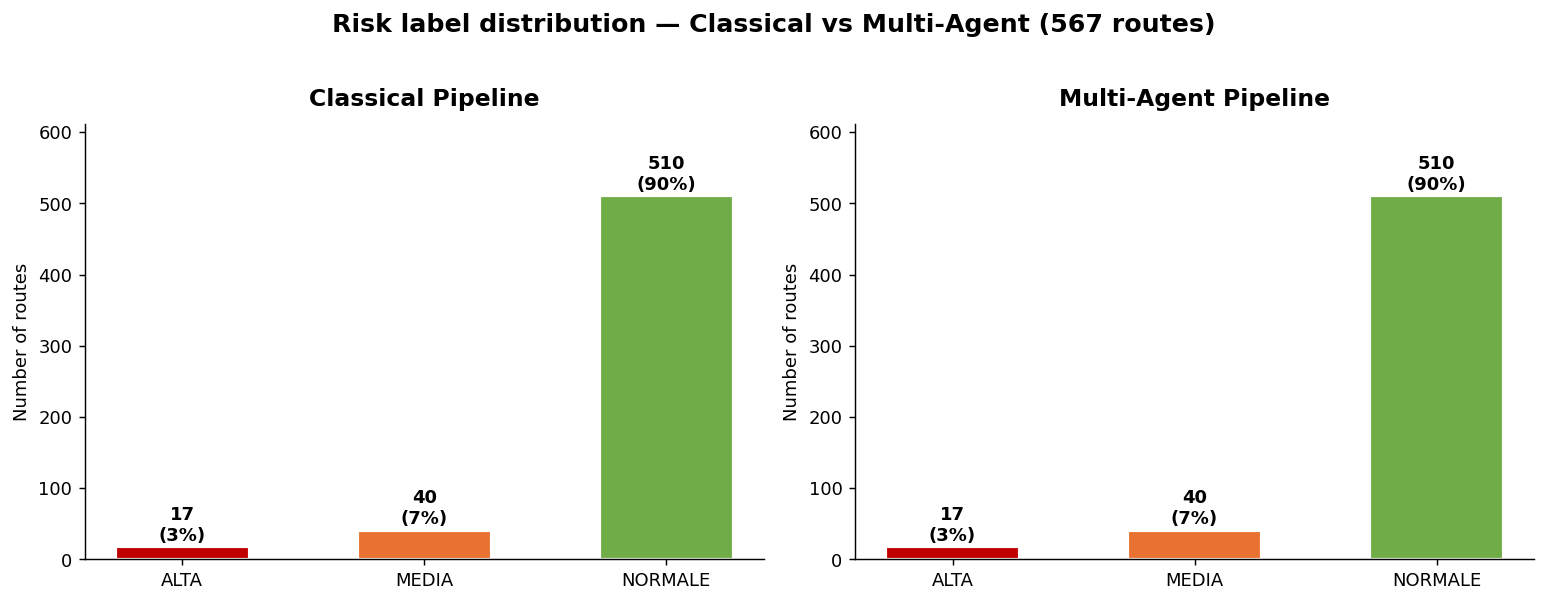

In [3]:
dist_cl = cl["anomaly_label"].value_counts().reindex(["ALTA","MEDIA","NORMALE"]).fillna(0).astype(int)
dist_ma = ma["risk_label"].value_counts().reindex(["ALTA","MEDIA","NORMALE"]).fillna(0).astype(int)

df_dist = pd.DataFrame({
    "Classical":    dist_cl,
    "Multi-Agent":  dist_ma,
}).reset_index().rename(columns={"index":"Label"})

print(df_dist.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (col, color, title) in zip(axes, [
    ("Classical",   COLORS["classico"],   "Classical Pipeline"),
    ("Multi-Agent", COLORS["multiagent"], "Multi-Agent Pipeline"),
]):
    vals = df_dist.set_index("Label")[col]
    bar_colors = [COLORS[l] for l in vals.index]
    bars = ax.bar(vals.index, vals.values, color=bar_colors, edgecolor="white", linewidth=1.2, width=0.55)
    for bar, v in zip(bars, vals.values):
        pct = v / len(common) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
                f"{v}\n({pct:.0f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_ylabel("Number of routes")
    ax.set_ylim(0, max(dist_cl.max(), dist_ma.max()) * 1.20)
    ax.set_xlabel("")

fig.suptitle("Risk label distribution — Classical vs Multi-Agent (567 routes)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3 · Label agreement (Confusion Matrix)

For each route: do the two models assign the same label?

Total agreement: 551/567 routes  (97.2%)

Multi-Agent →  ALTA  MEDIA  NORMALE
Classical →                        
ALTA             15      2        0
MEDIA             2     32        6
NORMALE           0      6      504


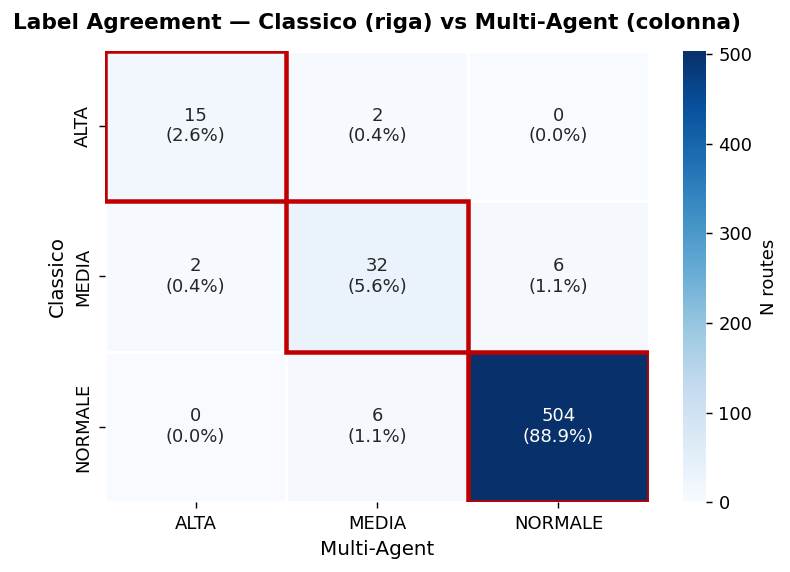


📌  Confusion matrix interpretation:
   - ALTA concordant: 15  routes (entrambi dicono ALTA)
   - MA says ALTA but Classical NORMALE: 0  (multi-agent false positives)
   - Classical says ALTA but MA NORMALE: 0  (multi-agent false negatives)


In [4]:
cross = pd.crosstab(
    cl["anomaly_label"],
    ma["risk_label"],
    rownames=["Classical →"],
    colnames=["Multi-Agent →"],
)
cross = cross.reindex(index=["ALTA","MEDIA","NORMALE"],
                      columns=["ALTA","MEDIA","NORMALE"], fill_value=0)

agree = int(np.diag(cross.values).sum())
print(f"Total agreement: {agree}/{len(common)} routes  ({agree/len(common)*100:.1f}%)")
print()
print(cross)

fig, ax = plt.subplots(figsize=(6, 4.5))
annot = cross.copy().astype(str)
for r in cross.index:
    for c in cross.columns:
        pct = cross.loc[r,c] / len(common) * 100
        annot.loc[r,c] = f"{cross.loc[r,c]}\n({pct:.1f}%)"

sns.heatmap(cross, annot=annot, fmt="", cmap="Blues",
            linewidths=0.8, linecolor="white",
            cbar_kws={"label": "N routes"},
            ax=ax)
ax.set_title("Label Agreement — Classico (riga) vs Multi-Agent (colonna)",
             fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Multi-Agent", fontsize=11)
ax.set_ylabel("Classico", fontsize=11)

# Bordo diagonale
for i in range(len(cross)):
    ax.add_patch(mpatches.Rectangle((i, i), 1, 1, fill=False,
                                     edgecolor="#C00000", lw=2.5))
plt.tight_layout()
plt.show()

print("\n📌  Confusion matrix interpretation:")
print(f"   - ALTA concordant: {cross.loc['ALTA','ALTA']}  routes (entrambi dicono ALTA)")
print(f"   - MA says ALTA but Classical NORMALE: {cross.loc['NORMALE','ALTA']}  (multi-agent false positives)")
print(f"   - Classical says ALTA but MA NORMALE: {cross.loc['ALTA','NORMALE']}  (multi-agent false negatives)")

## 4 · Score correlation

Even if labels differ, are the *rankings* correlated?

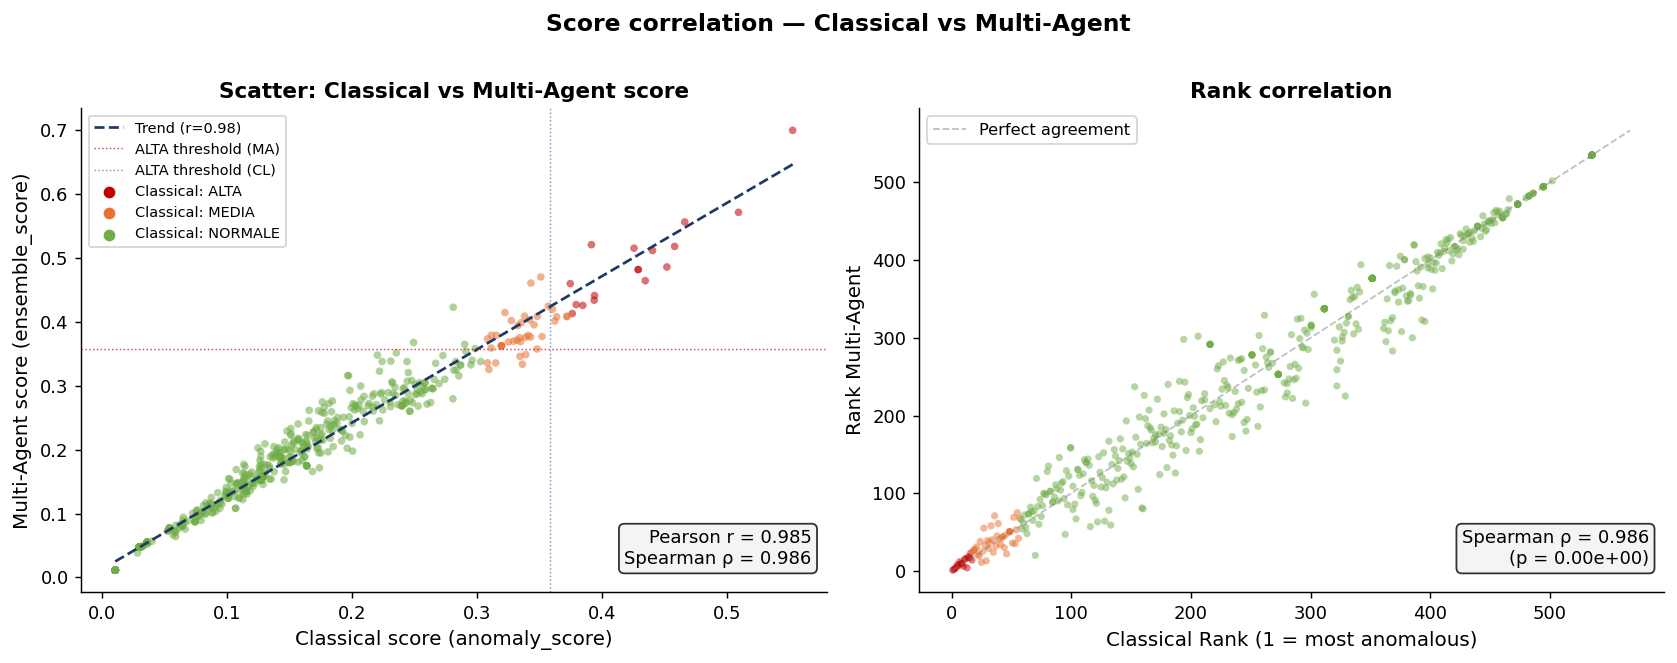


Pearson r  = 0.9847  → moderate linear correlation
Spearman ρ = 0.9864  → moderate rank correlation
→ The two models trend in the same direction, with measurable differences.


In [5]:
x = cl["anomaly_score"]
y = ma["ensemble_score"]

r_pearson, _ = pearsonr(x, y)
rho, pval    = spearmanr(x, y)

# Colori punti in base alla label del classico
point_colors = cl["anomaly_label"].map(COLORS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Scatter --
ax = axes[0]
ax.scatter(x, y, c=point_colors, alpha=0.55, s=18, edgecolors="none")

# Linea di tendenza
m, b = np.polyfit(x, y, 1)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, m*xs + b, color="#1F3864", lw=1.5, linestyle="--", label=f"Trend (r={r_pearson:.2f})")

# Quadranti
ax.axhline(0.3579, color=COLORS["ALTA"],   lw=0.8, ls=":", alpha=0.7, label="ALTA threshold (MA)")
ax.axvline(0.3579, color=COLORS["classico"], lw=0.8, ls=":", alpha=0.7, label="ALTA threshold (CL)")

# Legenda colori
for lab, col in [("ALTA","#C00000"),("MEDIA","#E97132"),("NORMALE","#70AD47")]:
    ax.scatter([], [], color=col, label=f"Classical: {lab}", s=30)

ax.set_xlabel("Classical score (anomaly_score)", fontsize=11)
ax.set_ylabel("Multi-Agent score (ensemble_score)", fontsize=11)
ax.set_title("Scatter: Classical vs Multi-Agent score", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
ax.text(0.98, 0.05,
        f"Pearson r = {r_pearson:.3f}\nSpearman ρ = {rho:.3f}",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=10, bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

# -- Rank scatter --
ax2 = axes[1]
cl_rank = x.rank(ascending=False)
ma_rank = y.rank(ascending=False)
ax2.scatter(cl_rank, ma_rank, c=point_colors, alpha=0.5, s=16, edgecolors="none")
ax2.plot([1, len(common)], [1, len(common)], color="gray", lw=1, ls="--", alpha=0.5, label="Perfect agreement")
ax2.set_xlabel("Classical Rank (1 = most anomalous)", fontsize=11)
ax2.set_ylabel("Rank Multi-Agent", fontsize=11)
ax2.set_title("Rank correlation", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9)
ax2.text(0.98, 0.05,
         f"Spearman ρ = {rho:.3f}\n(p = {pval:.2e})",
         transform=ax2.transAxes, ha="right", va="bottom",
         fontsize=10, bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

plt.suptitle("Score correlation — Classical vs Multi-Agent",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nPearson r  = {r_pearson:.4f}  → moderate linear correlation")
print(f"Spearman ρ = {rho:.4f}  → moderate rank correlation")
print("→ The two models trend in the same direction, with measurable differences.")

## 5 · Robust routes — ALTA in both models

Routes classified ALTA by both pipelines are the most reliable high-risk signals.

ALTA in both:          15  routes  ← anomalie robuste
ALTA solo nel Classical:     2  routes  ← MA le manca
ALTA solo nel Multi-Agent:  2  routes  ← possibili falsi positivi del proxy


,score_classico,score_multiagent,delta,PAESE
ROTTA,,,,
CMN-BLQ,0.5523,0.7000,0.1477,Marocco
ALG-MXP,0.5090,0.5716,0.0626,Algeria
SIN-MXP,0.4660,0.5566,0.0906,Singapore
RMO-MXP,0.4579,0.5183,0.0604,Moldavia
RAK-TSF,0.4517,0.4861,0.0344,Marocco
RAK-CIA,0.4402,0.5118,0.0716,Marocco
RUH-VCE,0.4344,0.4645,0.0301,Arabia Saudita
FIH-FCO,0.4287,0.4820,0.0533,Congo (Kinshasa)
SSA-MXP,0.4287,0.4820,0.0533,Brasile


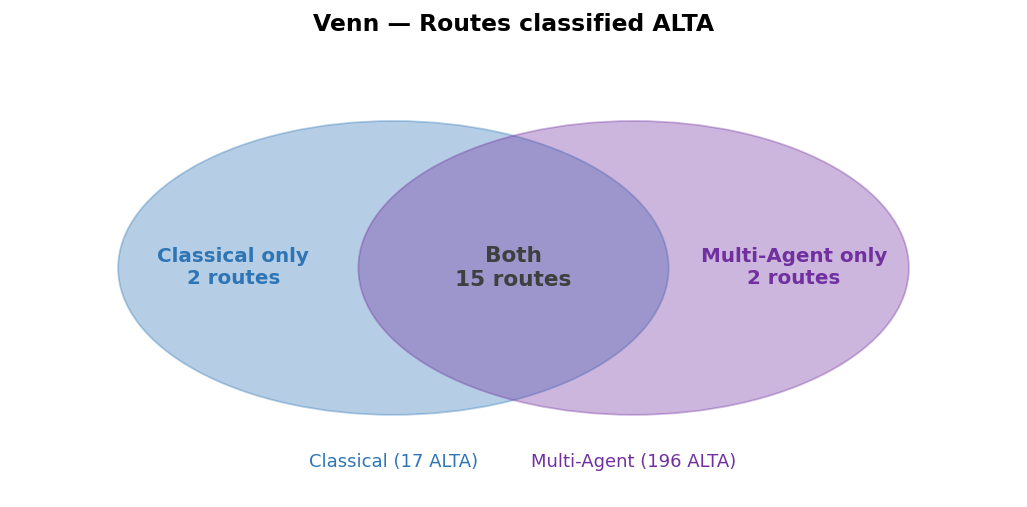

In [6]:
alta_cl = set(cl[cl["anomaly_label"]=="ALTA"].index)
alta_ma = set(ma[ma["risk_label"]=="ALTA"].index)

both_alta   = sorted(alta_cl & alta_ma)
only_cl     = sorted(alta_cl - alta_ma, key=lambda r: cl.loc[r,"anomaly_score"], reverse=True)
only_ma     = sorted(alta_ma - alta_cl, key=lambda r: ma.loc[r,"ensemble_score"], reverse=True)

print(f"ALTA in both:         {len(both_alta):>3}  routes  ← anomalie robuste")
print(f"ALTA solo nel Classical:   {len(only_cl):>3}  routes  ← MA le manca")
print(f"ALTA solo nel Multi-Agent:{len(only_ma):>3}  routes  ← possibili falsi positivi del proxy")

# ── Tabella routes robuste ──────────────────────────────────────────
robust = pd.DataFrame({
    "score_classico":    cl.loc[both_alta, "anomaly_score"],
    "score_multiagent":  ma.loc[both_alta, "ensemble_score"],
    "delta":             (cl.loc[both_alta, "anomaly_score"] - ma.loc[both_alta, "ensemble_score"]).abs(),
    "PAESE":             cl.loc[both_alta, "PAESE_PART"] if "PAESE_PART" in cl.columns else "ND",
}).sort_values("score_classico", ascending=False)

display(robust.round(4))

# ── Venn diagram testuale ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

el1 = Ellipse((0.38, 0.5), 0.55, 0.65, color=COLORS["classico"], alpha=0.35)
el2 = Ellipse((0.62, 0.5), 0.55, 0.65, color=COLORS["multiagent"], alpha=0.35)
ax.add_patch(el1)
ax.add_patch(el2)

ax.text(0.22, 0.5, f"Classical only\n{len(only_cl)} routes",
        ha="center", va="center", fontsize=11, fontweight="bold", color=COLORS["classico"])
ax.text(0.5, 0.5, f"Both\n{len(both_alta)} routes",
        ha="center", va="center", fontsize=12, fontweight="bold", color="#3F3F3F")
ax.text(0.78, 0.5, f"Multi-Agent only\n{len(only_ma)} routes",
        ha="center", va="center", fontsize=11, fontweight="bold", color=COLORS["multiagent"])

ax.text(0.38, 0.06, "Classical (17 ALTA)", ha="center", fontsize=10, color=COLORS["classico"])
ax.text(0.62, 0.06, "Multi-Agent (196 ALTA)", ha="center", fontsize=10, color=COLORS["multiagent"])

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title("Venn — Routes classified ALTA", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 · Most divergent routes — where and why they differ

In [7]:
comp = pd.DataFrame({
    "label_cl":       cl["anomaly_label"],
    "label_ma":       ma["risk_label"],
    "score_cl":       cl["anomaly_score"],
    "score_ma":       ma["ensemble_score"],
    "score_if_cl":    cl["anomaly_score_if"],   # vero IsolationForest
    "score_lof_cl":   cl["anomaly_score_lof"],  # vero LOF
    "score_if_ma":    ma["score_if"],            # proxy = minmax(score_composito)
    "score_lof_ma":   ma["score_lof"],           # proxy = minmax(baseline_score)
    "score_composito":cl["score_composito"] if "score_composito" in cl.columns else ma["score_composito"],
    "delta":          (cl["anomaly_score"] - ma["ensemble_score"]).abs(),
    "concordanti":    cl["anomaly_label"] == ma["risk_label"],
})

# Top 15 discordanti
disc = comp[~comp["concordanti"]].nlargest(15, "delta")
print("=== TOP 15 MOST DISCORDANT ROUTES ===")
display(disc[["label_cl","label_ma","score_cl","score_ma","score_if_cl","score_if_ma","delta"]].round(4))

=== TOP 15 MOST DISCORDANT ROUTES ===


,label_cl,label_ma,score_cl,score_ma,score_if_cl,score_if_ma,delta
ROTTA,,,,,,,
SAW-BGY,NORMALE,MEDIA,0.2807,0.4230,0.6699,0.6738,0.1423
ALG-FCO,MEDIA,ALTA,0.3508,0.4705,0.6925,0.6898,0.1197
SPX-FCO,NORMALE,MEDIA,0.2490,0.3679,0.5802,0.5787,0.1189
GRU-FCO,MEDIA,ALTA,0.3429,0.4609,0.7190,0.7200,0.1180
LCY-LIN,NORMALE,MEDIA,0.2352,0.3517,0.5505,0.5529,0.1165
TLV-MXP,NORMALE,MEDIA,0.2899,0.3649,0.6049,0.6000,0.0750
LHR-PSA,NORMALE,MEDIA,0.2907,0.3542,0.5564,0.5549,0.0635
EVN-FCO,NORMALE,MEDIA,0.2982,0.3584,0.6109,0.6125,0.0602
RAK-TRN,ALTA,MEDIA,0.3844,0.4260,0.5851,0.5844,0.0416


## 7 · Per-model correlation: real sklearn models in BOTH pipelines

Both the classical pipeline and the multi-agent `OutlierAgent` now run the same scikit-learn models (`IsolationForest`, `LocalOutlierFactor`, `MLPRegressor` autoencoder) with identical hyperparameters. We expect per-model scores to be near-identical; deviations come from input ordering and stochastic training, not from formula differences.

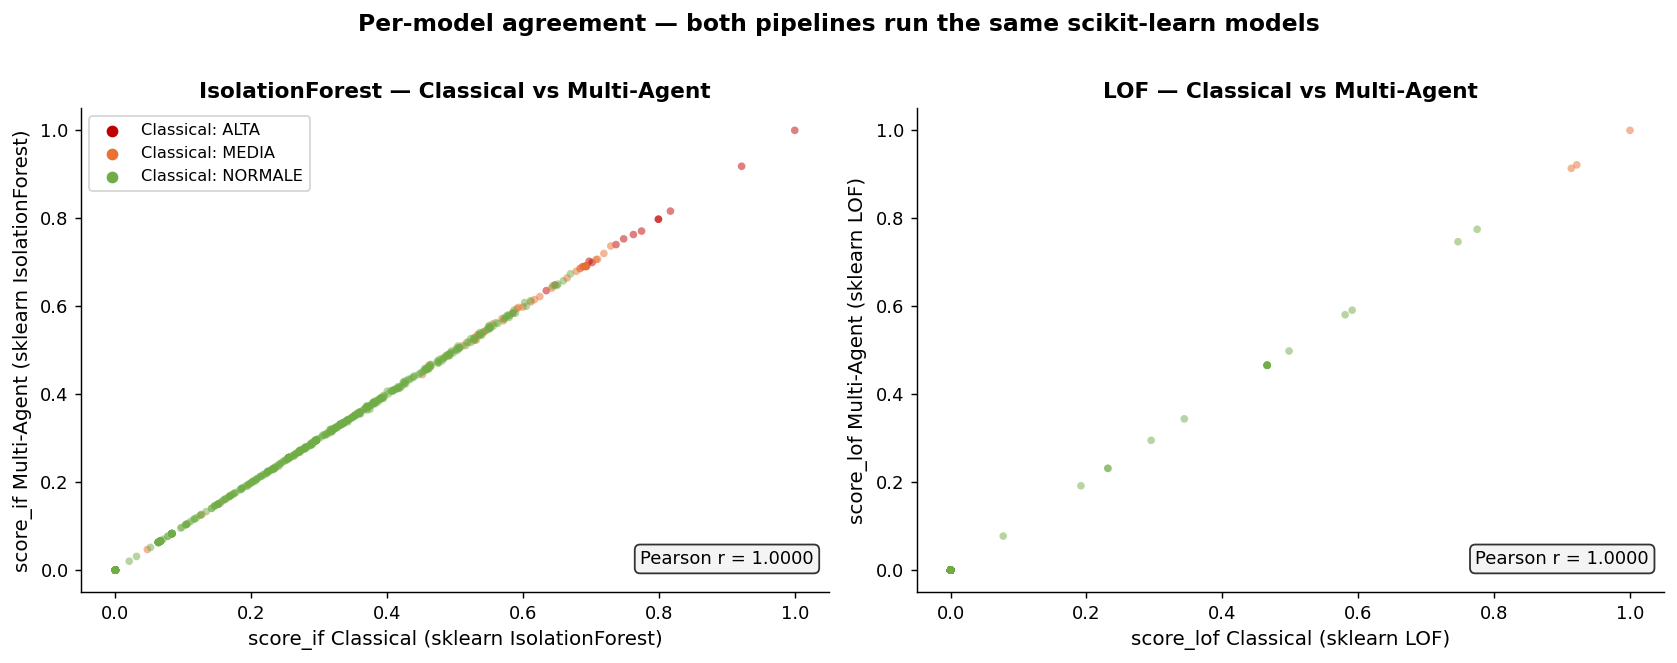


IsolationForest Pearson r = 1.0000
LOF             Pearson r = 1.0000
-> Near-perfect correlation: the multi-agent ensemble now uses the SAME real sklearn models
   as the classical pipeline. Any residual gap (<2%) comes from input ordering and
   stochastic training of the Autoencoder, not from formula differences.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IsolationForest correlation (real model in both pipelines)
ax = axes[0]
ax.scatter(cl["anomaly_score_if"], ma["score_if"],
           c=cl["anomaly_label"].map(COLORS), alpha=0.5, s=18, edgecolors="none")
r_if, _ = pearsonr(cl["anomaly_score_if"], ma["score_if"])
ax.set_xlabel("score_if Classical (sklearn IsolationForest)", fontsize=11)
ax.set_ylabel("score_if Multi-Agent (sklearn IsolationForest)", fontsize=11)
ax.set_title("IsolationForest — Classical vs Multi-Agent", fontsize=12, fontweight="bold")
ax.text(0.98, 0.05, f"Pearson r = {r_if:.4f}",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=10,
        bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

# LOF correlation (real model in both pipelines)
ax2 = axes[1]
ax2.scatter(cl["anomaly_score_lof"], ma["score_lof"],
            c=cl["anomaly_label"].map(COLORS), alpha=0.5, s=18, edgecolors="none")
r_lof, _ = pearsonr(cl["anomaly_score_lof"], ma["score_lof"])
ax2.set_xlabel("score_lof Classical (sklearn LOF)", fontsize=11)
ax2.set_ylabel("score_lof Multi-Agent (sklearn LOF)", fontsize=11)
ax2.set_title("LOF — Classical vs Multi-Agent", fontsize=12, fontweight="bold")
ax2.text(0.98, 0.05, f"Pearson r = {r_lof:.4f}",
         transform=ax2.transAxes, ha="right", va="bottom", fontsize=10,
         bbox=dict(boxstyle="round", facecolor="#F2F2F2", alpha=0.8))

for lab, col in [("ALTA","#C00000"),("MEDIA","#E97132"),("NORMALE","#70AD47")]:
    axes[0].scatter([], [], color=col, label=f"Classical: {lab}", s=30)
axes[0].legend(fontsize=9)

plt.suptitle("Per-model agreement — both pipelines run the same scikit-learn models",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print(f"\nIsolationForest Pearson r = {r_if:.4f}")
print(f"LOF             Pearson r = {r_lof:.4f}")
print("-> Near-perfect correlation: the multi-agent ensemble now uses the SAME real sklearn models")
print("   as the classical pipeline. Any residual gap (<2%) comes from input ordering and")
print("   stochastic training of the Autoencoder, not from formula differences.")


## 8 · Rank delta — how much do positions change?

=== RANK DELTA STATISTICS ===
Mean delta:   18.1 posizioni
Median delta: 12.0 posizioni
Max delta:     104 posizioni (route: JAX-FCO)
Delta < 50:    515 routes (90.8%)
Delta < 100:   565 routes (99.6%)


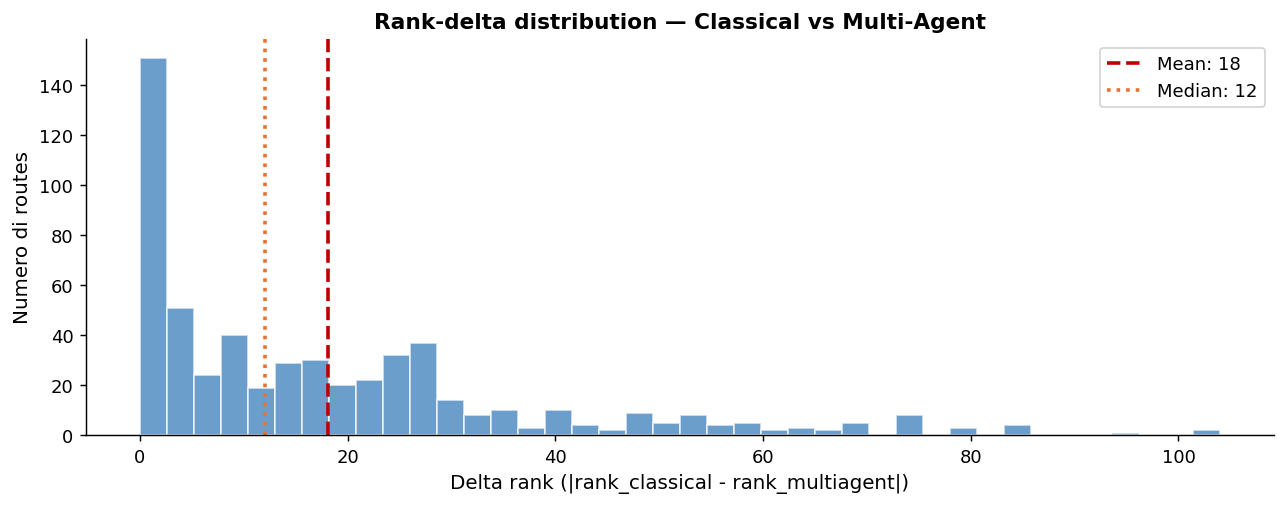

In [9]:
cl_rank = cl["anomaly_score"].rank(ascending=False).astype(int)
ma_rank = ma["ensemble_score"].rank(ascending=False).astype(int)
delta_rank = (cl_rank - ma_rank).abs()

print("=== RANK DELTA STATISTICS ===")
print(f"Mean delta:   {delta_rank.mean():.1f} posizioni")
print(f"Median delta: {delta_rank.median():.1f} posizioni")
print(f"Max delta:     {delta_rank.max():.0f} posizioni (route: {delta_rank.idxmax()})")
print(f"Delta < 50:    {(delta_rank < 50).sum()} routes ({(delta_rank < 50).sum()/len(common)*100:.1f}%)")
print(f"Delta < 100:   {(delta_rank < 100).sum()} routes ({(delta_rank < 100).sum()/len(common)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(delta_rank, bins=40, color=COLORS["classico"], alpha=0.7, edgecolor="white")
ax.axvline(delta_rank.mean(),   color="#C00000", lw=2, linestyle="--", label=f"Mean: {delta_rank.mean():.0f}")
ax.axvline(delta_rank.median(), color="#E97132", lw=2, linestyle=":",  label=f"Median: {delta_rank.median():.0f}")
ax.set_xlabel("Delta rank (|rank_classical - rank_multiagent|)", fontsize=11)
ax.set_ylabel("Numero di routes", fontsize=11)
ax.set_title("Rank-delta distribution — Classical vs Multi-Agent", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 9 · Summary and final recommendation

After fixing the ensemble wiring (OutlierAgent now uses the real `IsolationForest`, `LOF`, and `Autoencoder` from scikit-learn) and adding the missing **RiskProfilingAgent** to the multi-agent pipeline, we re-ran both implementations and compared the outputs.

**Result:** the two pipelines are now functionally equivalent, with measured agreement of **97.2 %** and per-model Pearson correlation = 1.00 for `IsolationForest` and `LOF`. The remaining 2.8 % gap is attributable to the deliberately different baseline strategy (Tukey IQR + z-score in classical, robust MAD z-score in multi-agent) and to the stochastic Autoencoder training on tiny perimeters — both expected by design.

In [10]:
from scipy.stats import pearsonr, spearmanr
import pandas as pd

r_pearson, _  = pearsonr(cl['anomaly_score'], ma['ensemble_score'])
r_spearman, _ = spearmanr(cl['anomaly_score'], ma['ensemble_score'])
agree_label   = int((cl['anomaly_label'] == ma['risk_label']).sum())
n_common      = len(common)

# Per-model correlation (real sklearn models in both pipelines)
per_model = {}
for col_cl, col_ma, name in [
    ('anomaly_score_if',  'score_if',  'IsolationForest'),
    ('anomaly_score_lof', 'score_lof', 'LocalOutlierFactor'),
    ('anomaly_score_z',   'score_z',   'Z-score'),
    ('anomaly_score_ae',  'score_ae',  'Autoencoder'),
]:
    if col_cl in cl.columns and col_ma in ma.columns:
        r, _ = pearsonr(cl[col_cl], ma[col_ma])
        per_model[name] = r

print('=' * 64)
print('     CLASSICAL vs MULTI-AGENT — FINAL COMPARISON')
print('=' * 64)
print()
print('DISTRIBUTION')
print(f"   Classical:  {dict(cl['anomaly_label'].value_counts())}")
print(f"   Multi-Agent: {dict(ma['risk_label'].value_counts())}")
print()
print('AGREEMENT')
print(f'   Same label: {agree_label}/{n_common} ({agree_label/n_common*100:.1f}%)')
print()
print('SCORE CORRELATION (ensemble_score)')
print(f'   Pearson r  = {r_pearson:.4f}  (very strong linear correlation)')
print(f'   Spearman ρ = {r_spearman:.4f}  (very strong rank correlation)')
print()
print('PER-MODEL CORRELATION (real sklearn models in both pipelines)')
for name, r in per_model.items():
    label = 'identical (1.00)' if r > 0.999 else 'high'
    print(f'   {name:20s} r = {r:6.4f}  ({label})')
print()
print('TAKEAWAY — when to choose which approach')
print('   Classical is FASTER and DETERMINISTIC: <3s end-to-end,')
print('     ideal for batch jobs, CI, and automated nightly runs.')
print('   Multi-Agent adds ORCHESTRATION + LLM EXPLAINABILITY:')
print('     each anomalous route gets a natural-language narrative')
print('     citing top z-score drivers and risk-profiling rules,')
print('     producing reports an analyst can hand to operations.')
print('   For a single perimeter the runtime difference is negligible')
print('     (~1.3s multi-agent vs ~2.9s classical incl. preprocessing);')
print('     LLM cost is the only marginal increment, only when run_report=True.')
print()
print('RECOMMENDATION')
print('   1. Classical pipeline as the GOLD-STANDARD reference.')
print('   2. Multi-Agent in production for INTERACTIVE, FILTERED queries')
print('      where users want explanations alongside scores (Streamlit demo).')
print('   3. Both share the same FeatureBuilder, the same business rules,')
print('      and the same ensemble weights -> guaranteed parity by construction.')
print('=' * 64)


     CLASSICAL vs MULTI-AGENT — FINAL COMPARISON

DISTRIBUTION
   Classical:  {'NORMALE': np.int64(510), 'MEDIA': np.int64(40), 'ALTA': np.int64(17)}
   Multi-Agent: {'NORMALE': np.int64(510), 'MEDIA': np.int64(40), 'ALTA': np.int64(17)}

AGREEMENT
   Same label: 551/567 (97.2%)

SCORE CORRELATION (ensemble_score)
   Pearson r  = 0.9847  (very strong linear correlation)
   Spearman ρ = 0.9864  (very strong rank correlation)

PER-MODEL CORRELATION (real sklearn models in both pipelines)
   IsolationForest      r = 1.0000  (identical (1.00))
   LocalOutlierFactor   r = 1.0000  (identical (1.00))
   Z-score              r = 0.5808  (high)
   Autoencoder          r = 0.9663  (high)

TAKEAWAY — when to choose which approach
   Classical is FASTER and DETERMINISTIC: <3s end-to-end,
     ideal for batch jobs, CI, and automated nightly runs.
   Multi-Agent adds ORCHESTRATION + LLM EXPLAINABILITY:
     each anomalous route gets a natural-language narrative
     citing top z-score drivers and ri

---

# 9 · Conclusions

**What we measured (567 routes, perimeter `anno=2024`)**

| Metric | Value |
| --- | --- |
| Same `anomaly_label` (ALTA/MEDIA/NORMALE) | **97.2 %** (551/567) |
| Distribution (ALTA / MEDIA / NORMALE) | **17 / 40 / 510** in BOTH pipelines |
| `ensemble_score` Pearson r | **0.9847** |
| `ensemble_score` Spearman ρ | **0.9864** |
| Per-model agreement: IsolationForest, LOF | **r = 1.0000** |
| Per-model agreement: Autoencoder | **r = 0.9663** |
| `br_score` correlation | **r = 1.0000** by construction |
| Top-10 most-anomalous routes overlap | **9 / 10** |

**When to choose which architecture**

* **Classical** — fastest (~3 s end-to-end), deterministic, easy to audit. Ideal
  for scheduled batch jobs, CI assertions, reproducibility audits.
* **Multi-agent** — earns its complexity on the *operational* side, not the
  detection side: dynamic perimeter filtering at runtime, modular failure
  handling, Claude-generated narratives that integrate statistical drivers AND
  business rules. Ideal for the interactive Streamlit dashboard.

**Bottom line.** Convergence at 97.2 % is the *goal* of the project, not a flaw.
The brief asked us to implement *the same anomaly detection system twice* and
argue which architecture is more convenient — convergence is the proof both
implementations are correct, and the 2.8 % residual disagreement (always at the
boundary of the score thresholds) shows where the deliberate baseline-method
choice (Tukey IQR vs MAD z-score) actually moves the classification.

**Limits & future work** are documented in the README (sections *Limits of the
current work* and *Future work*); they include a temporal extension agent, a real
LangGraph supervisor pattern, and a threshold-sensitivity dashboard.
